# Best Available Hardened Strategy

**Technical strategy:** Diversified Global-Futures Time-Series Momentum
Plus Basis-Momentum Portfolio

## Research, Risk & Deployment Review — v3.2.1

**Live deployment status: BLOCKED — NO LIVE CAPITAL AUTHORIZATION**

“Best Available Hardened Strategy” is the repository designation for
the latest selected specification after the correctness and controls
audit. It is not a claim of universal optimality, independent
validation, or live approval.

This notebook explains the selected research specification, its exact
research accounting, observed risk and trade economics, the production
controls now implemented, and the evidence that still does not exist.
The only decision sought today is permission to continue serial-data
integration and prospective paper/shadow testing.

In plain English, this is a **Diversified global-futures time-series
momentum plus basis-momentum portfolio**. It combines a 12-month
directional trend forecast with a basis-momentum forecast across the
generated supported universe, then applies causal risk sizing and
explicit execution limits. Two yield-quoted
ASX bond futures are excluded until exact effective-dated valuation
functions are available.

The historical results are not an untouched holdout. The model was
developed after inspecting the supplied history, which ends on
2014-12-31. Every metric and simulation below is labelled accordingly.
Twenty percent CAGR and approximately 2.0 Sharpe are aspirations, not
optimization constraints or launch gates.


## 1. Reproducible artifact load and integrity check

The notebook is a presentation layer over versioned artifacts; it does
not contain a second implementation of the signal or ledger. Before
displaying results it checks the implementation hashes, configuration
hash, and aggregate source fingerprint recorded by the canonical run.
Hashes establish byte identity—not vendor correctness, point-in-time
membership, survivorship freedom, or live tradability.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import hashlib
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from delta1_strategy import (
    ENGINE_VERSION,
    STRATEGY_NAME,
    STRATEGY_DESIGNATION,
    STRATEGY_TECHNICAL_NAME,
)
from delta1_strategy.controls.production import ProductionLimits

working_directory = Path.cwd().resolve()
root_candidates = (working_directory, working_directory.parent)
ROOT = next(
    (
        candidate
        for candidate in root_candidates
        if (candidate / "outputs").is_dir()
        and (candidate / "src" / "delta1_strategy").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Run this notebook from the repository root or notebooks directory"
    )
OUTPUTS = ROOT / "outputs"

COLORS = {
    "navy": "#16324F",
    "blue": "#2E6F9E",
    "teal": "#2A9D8F",
    "green": "#3A7D44",
    "amber": "#E9A23B",
    "red": "#B23A48",
    "light": "#E8EEF3",
    "gray": "#6B7280",
}
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
    "axes.titleweight": "bold",
})

manifest = json.loads((OUTPUTS / "run_manifest.json").read_text())
if not manifest.get("friction_stress_included"):
    raise RuntimeError(
        "The committee notebook requires a canonical run without --skip-stress"
    )
configuration = json.loads((OUTPUTS / "strategy_config.json").read_text())
if manifest.get("engine_version") != ENGINE_VERSION:
    raise RuntimeError(
        "Stale run manifest: regenerate outputs with the installed "
        f"engine {ENGINE_VERSION}; found {manifest.get('engine_version')!r}"
    )
if configuration.get("engine_version") != ENGINE_VERSION:
    raise RuntimeError(
        "Stale strategy configuration: regenerate the canonical v3.2.1 bundle"
    )
expected_strategy_metadata = {
    "strategy": STRATEGY_NAME,
    "strategy_designation": STRATEGY_DESIGNATION,
    "strategy_technical_name": STRATEGY_TECHNICAL_NAME,
}
for field, expected in expected_strategy_metadata.items():
    if manifest.get(field) != expected:
        raise RuntimeError(
            f"Run manifest {field} does not match the installed strategy label"
        )
for field in (
    "strategy_name",
    "strategy_designation",
    "strategy_technical_name",
):
    expected = {
        "strategy_name": STRATEGY_NAME,
        "strategy_designation": STRATEGY_DESIGNATION,
        "strategy_technical_name": STRATEGY_TECHNICAL_NAME,
    }[field]
    if configuration.get(field) != expected:
        raise RuntimeError(
            f"Strategy configuration {field} does not match the installed label"
        )
live_limits = ProductionLimits()
required_research_limits = (
    "target_vol",
    "max_rebalance_participation",
    "max_gross_notional_multiple",
)
missing_research_limits = [
    name for name in required_research_limits
    if configuration.get(name) is None
]
if missing_research_limits:
    raise RuntimeError(
        "Canonical configuration is missing committee control values: "
        + ", ".join(missing_research_limits)
    )
research_target_vol = float(configuration["target_vol"])
research_participation_limit = float(
    configuration["max_rebalance_participation"]
)
research_gross_limit = float(
    configuration["max_gross_notional_multiple"]
)
readiness = pd.read_csv(OUTPUTS / "production_readiness.csv")
metrics = pd.read_csv(OUTPUTS / "strategy_metrics.csv")
daily = pd.read_csv(OUTPUTS / "strategy_daily.csv", parse_dates=["date"]).set_index("date")
quality = pd.read_csv(
    OUTPUTS / "strategy_data_quality.csv",
    parse_dates=["first_model_price", "last_model_price"],
)
trade_metrics = pd.read_csv(OUTPUTS / "strategy_trade_metrics.csv")
episodes = pd.read_csv(
    OUTPUTS / "strategy_trade_episodes.csv",
    parse_dates=["Entry date", "Exit date"],
)
stress = pd.read_csv(OUTPUTS / "strategy_friction_stress.csv")
regimes = pd.read_csv(OUTPUTS / "strategy_regime_metrics.csv")
bootstrap = pd.read_csv(OUTPUTS / "strategy_monte_carlo_summary.csv")
daily_drawdown_bootstrap = pd.read_csv(
    OUTPUTS / "strategy_daily_drawdown_monte_carlo.csv"
)
trade_sequence = pd.read_csv(
    OUTPUTS / "strategy_trade_sequence_monte_carlo.csv"
)
source_manifest = pd.read_csv(OUTPUTS / "source_manifest.csv")
ledger_checks = pd.read_csv(OUTPUTS / "strategy_ledger_checks.csv")
cost_assumptions = pd.read_csv(OUTPUTS / "cost_model_assumptions.csv")
market = pd.read_csv(OUTPUTS / "strategy_market_daily.csv.gz", parse_dates=["date"])
overlay = pd.read_csv(
    OUTPUTS / "strategy_drawdown_overlay_diagnostic.csv",
    parse_dates=["date"],
).set_index("date")
overlay_summary = pd.read_csv(OUTPUTS / "strategy_drawdown_overlay_summary.csv")

implementation_checks = []
for filename, expected in manifest["implementation_files"].items():
    observed = hashlib.sha256((ROOT / filename).read_bytes()).hexdigest()
    implementation_checks.append({
        "Artifact": filename,
        "Expected SHA-256": expected[:14] + "…",
        "Observed SHA-256": observed[:14] + "…",
        "Status": "PASS" if observed == expected else "BLOCKED",
    })
if not manifest.get("output_files"):
    raise RuntimeError("run manifest contains no canonical output hashes")
output_checks = []
for filename, expected in manifest["output_files"].items():
    output_path = OUTPUTS / filename
    observed = (
        hashlib.sha256(output_path.read_bytes()).hexdigest()
        if output_path.is_file()
        else "MISSING"
    )
    output_checks.append({
        "Artifact": f"outputs/{filename}",
        "Expected SHA-256": expected[:14] + "…",
        "Observed SHA-256": observed[:14] + "…" if observed != "MISSING" else observed,
        "Status": "PASS" if observed == expected else "BLOCKED",
    })
config_text = (OUTPUTS / "strategy_config.json").read_text().rstrip("\n")
config_hash = hashlib.sha256(config_text.encode("utf-8")).hexdigest()
source_fingerprint = hashlib.sha256(
    "\n".join(
        source_manifest["relative_path"].astype(str)
        + ":"
        + source_manifest["sha256"].astype(str)
    ).encode("utf-8")
).hexdigest()
integrity = pd.DataFrame(implementation_checks + output_checks + [
    {
        "Artifact": "strategy_config.json",
        "Expected SHA-256": manifest["config_sha256"][:14] + "…",
        "Observed SHA-256": config_hash[:14] + "…",
        "Status": "PASS" if config_hash == manifest["config_sha256"] else "BLOCKED",
    },
    {
        "Artifact": "source fingerprint",
        "Expected SHA-256": manifest["source_fingerprint_sha256"][:14] + "…",
        "Observed SHA-256": source_fingerprint[:14] + "…",
        "Status": "PASS" if source_fingerprint == manifest["source_fingerprint_sha256"] else "BLOCKED",
    },
])
if not integrity["Status"].eq("PASS").all():
    raise RuntimeError("Artifact integrity check failed; regenerate a coherent output set")
display(integrity)


,Artifact,Expected SHA-256,Observed SHA-256,Status
0,src/delta1_strategy/__init__.py,9c3990b3e535d8…,9c3990b3e535d8…,PASS
1,src/delta1_strategy/cli.py,b11f325e8411ee…,b11f325e8411ee…,PASS
2,src/delta1_strategy/controls/__init__.py,e380d642a5a062…,e380d642a5a062…,PASS
3,src/delta1_strategy/controls/evidence.py,441707cc828d52…,441707cc828d52…,PASS
4,src/delta1_strategy/controls/production.py,585815ac5a1ba8…,585815ac5a1ba8…,PASS
5,src/delta1_strategy/controls/treasury.py,c7d5624880a6cf…,c7d5624880a6cf…,PASS
6,src/delta1_strategy/execution/__init__.py,e8f6712db19b5f…,e8f6712db19b5f…,PASS
7,src/delta1_strategy/execution/costs.py,25bbe1ee7c7f1a…,25bbe1ee7c7f1a…,PASS
8,src/delta1_strategy/execution/operations.py,dbe1281dcb23f1…,dbe1281dcb23f1…,PASS
9,src/delta1_strategy/marketdata/__init__.py,2cd73ed55367d3…,2cd73ed55367d3…,PASS


## 2. Decision page and executive scorecard

Readiness is conjunctive: one missing critical gate blocks deployment.
Pass counts are shown only to locate remediation work and must not be
interpreted as a completion percentage.


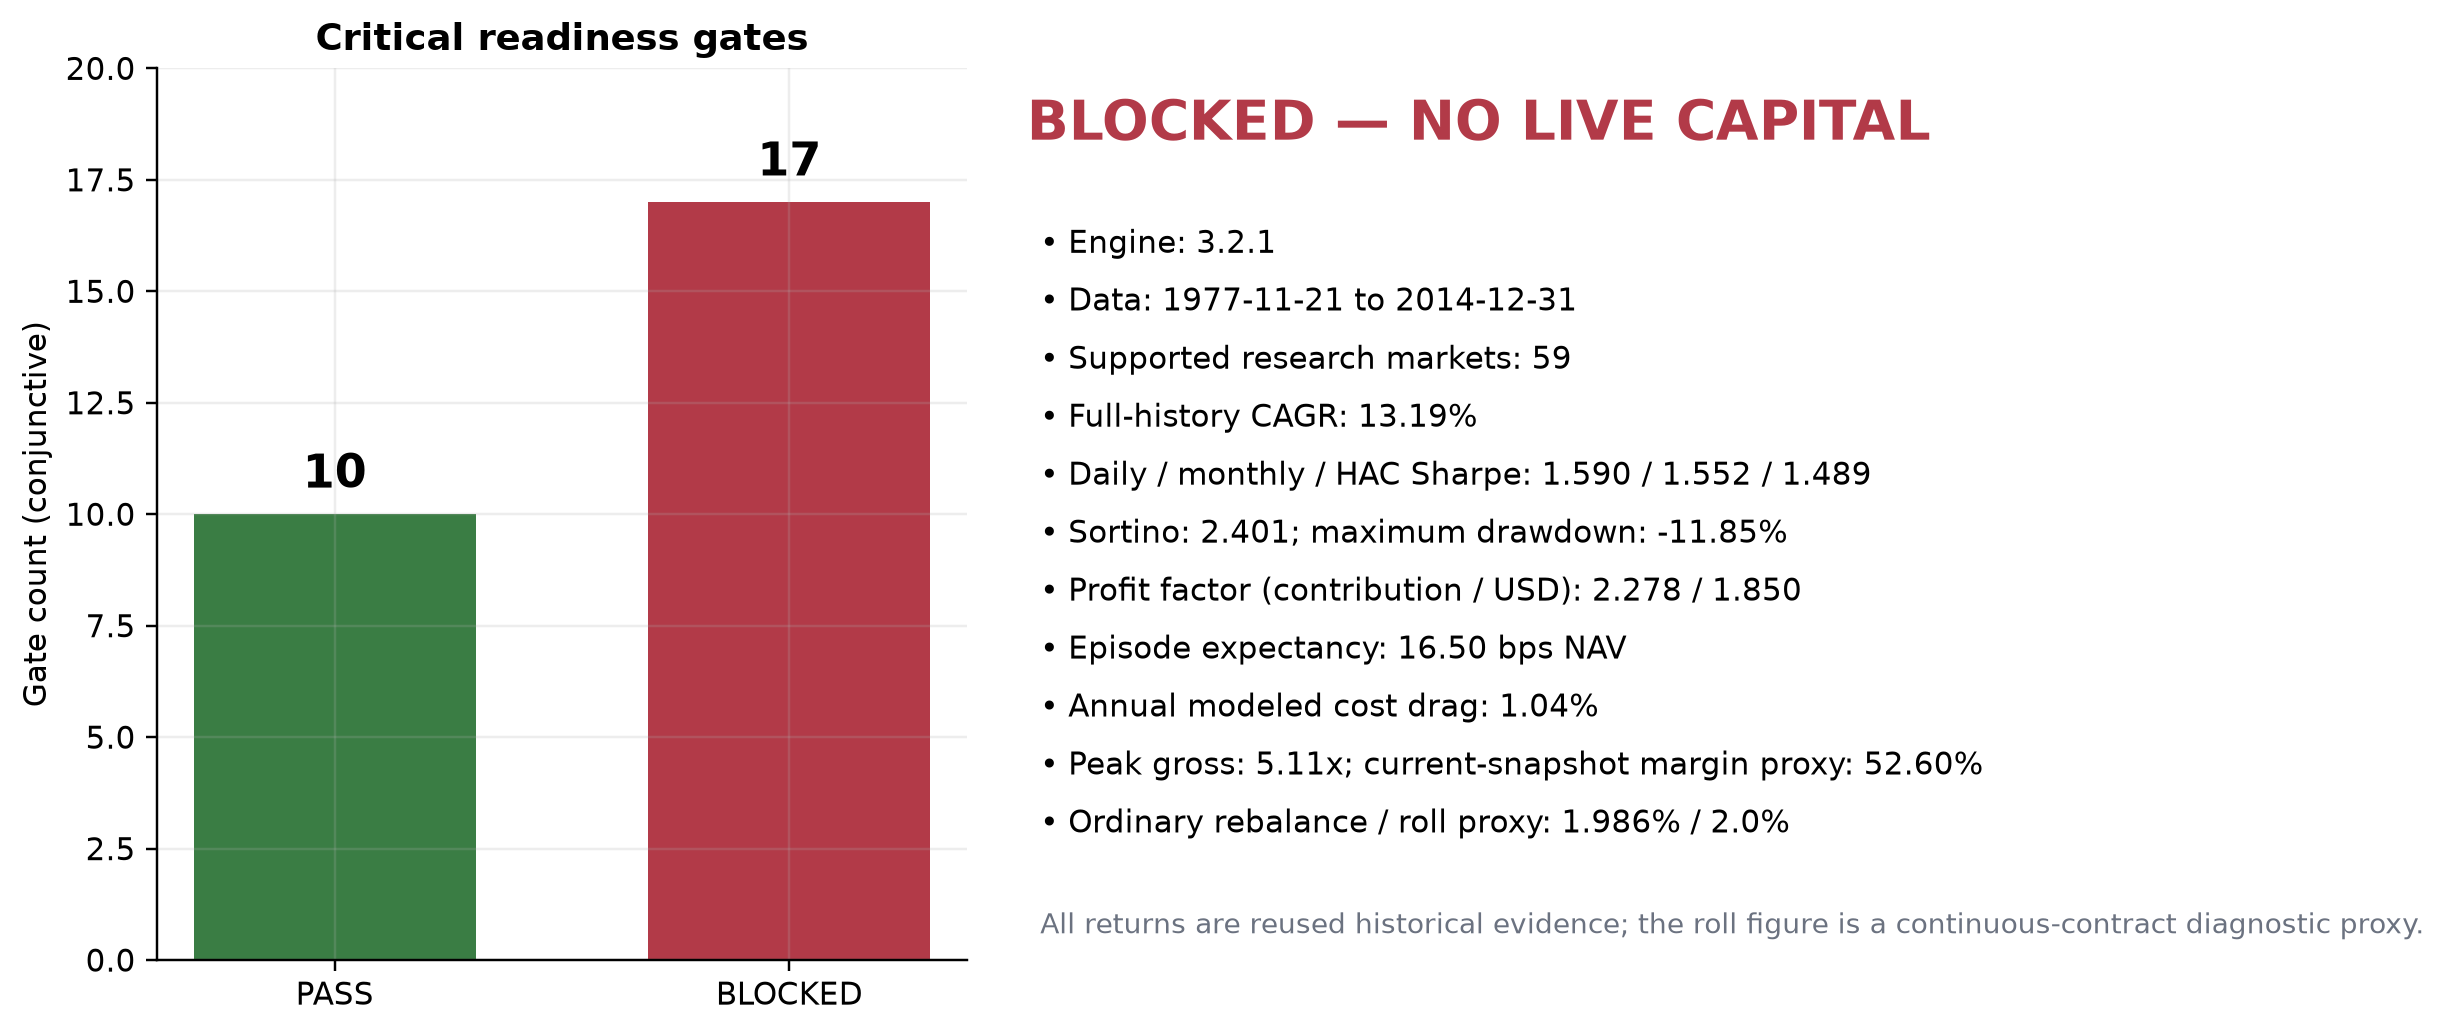

,Window,CAGR,Annualized volatility,"Naive daily Sharpe (sqrt252, rf=0)",Sortino (rf=0),Max drawdown,Trade profit factor (USD),Trade expectancy (bps NAV),Annual cost drag
0,1990-2004 development history,0.1542,0.0777,1.8218,2.8198,-0.0990,2.3966,22.9704,0.0127
1,2005-2014 reused later diagnostic,0.0993,0.0764,1.2354,1.8010,-0.1185,1.6877,10.4800,0.0070
2,1990-2014 full post-launch history,0.1319,0.0772,1.5895,2.4014,-0.1185,1.8499,16.4975,0.0104


In [2]:
critical = readiness.loc[readiness["critical"].eq(True)].copy()
counts = critical["status"].value_counts().reindex(["PASS", "BLOCKED"], fill_value=0)
full = metrics.loc[metrics["Window"].str.contains("full post-launch")].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1, 1.65]})
axes[0].bar(counts.index, counts.values, color=[COLORS["green"], COLORS["red"]], width=0.62)
for x, value in enumerate(counts.values):
    axes[0].text(x, value + 0.35, str(value), ha="center", va="bottom", fontsize=15, weight="bold")
axes[0].set_ylim(0, max(counts.max() + 3, 6))
axes[0].set_title("Critical readiness gates")
axes[0].set_ylabel("Gate count (conjunctive)")

axes[1].axis("off")
axes[1].text(0.02, 0.92, "BLOCKED — NO LIVE CAPITAL", color=COLORS["red"], fontsize=18, weight="bold")
facts = [
    f"Engine: {manifest['engine_version']}",
    f"Data: {manifest['data_start']} to {manifest['data_end']}",
    f"Supported research markets: {quality['symbol'].nunique()}",
    f"Full-history CAGR: {full['CAGR']:.2%}",
    f"Daily / monthly / HAC Sharpe: {full['Naive daily Sharpe (sqrt252, rf=0)']:.3f} / {full['Monthly Sharpe (rf=0)']:.3f} / {full['HAC Sharpe (21 lags, rf=0)']:.3f}",
    f"Sortino: {full['Sortino (rf=0)']:.3f}; maximum drawdown: {full['Max drawdown']:.2%}",
    f"Profit factor (contribution / USD): {full['Trade profit factor (contribution)']:.3f} / {full['Trade profit factor (USD)']:.3f}",
    f"Episode expectancy: {full['Trade expectancy (bps NAV)']:.2f} bps NAV",
    f"Annual modeled cost drag: {full['Annual cost drag']:.2%}",
    f"Peak gross: {full['Peak gross notional multiple']:.2f}x; current-snapshot margin proxy: {full['Peak static margin fraction']:.2%}",
    f"Ordinary rebalance / roll proxy: {full['Peak rebalance participation']:.3%} / {full['Peak roll participation proxy']:.1%}",
]
for row, text in enumerate(facts):
    axes[1].text(0.03, 0.82 - row * 0.065, "• " + text, fontsize=10.2, va="top")
axes[1].text(
    0.03, 0.03,
    "All returns are reused historical evidence; the roll figure is a continuous-contract diagnostic proxy.",
    fontsize=9, color=COLORS["gray"], wrap=True,
)
fig.tight_layout()
plt.show()

scorecard_columns = [
    "Window", "CAGR", "Annualized volatility",
    "Naive daily Sharpe (sqrt252, rf=0)", "Sortino (rf=0)",
    "Max drawdown", "Trade profit factor (USD)",
    "Trade expectancy (bps NAV)", "Annual cost drag",
]
display(metrics[scorecard_columns].round(4))


### Illustrative benchmark context — not an optimization target

The bands below are the user-supplied reporting reference. They are not
a universal institutional standard, contain unclassified gaps, and are
not used as launch gates or parameter-search objectives. Maximum
drawdown is a risk outcome to minimize subject to return—not a number
to increase merely to enter a category.

The notebook classifies the generated metrics dynamically against
those descriptive bands. It does not infer “high alpha” or readiness
from a band label. All ratios use zero risk-free return and reused
history.


,Metric,Current net result,Classification,Committee interpretation
0,CAGR,13.19%,Conservative,Descriptive reused-history band; not a target
1,Sharpe (rf=0),1.590 daily / 1.552 monthly / 1.489 HAC,Institutional,Use HAC 1.489 as the conservative headline
2,Sortino (rf=0),2.401,Supplementary — no supplied band,Not interchangeable with Sharpe >2
3,Maximum drawdown,11.85%,Institutional,3.15% historical headroom to the separate runt...
4,Overall,—,Descriptive only,Historical bands cannot change the BLOCKED lau...


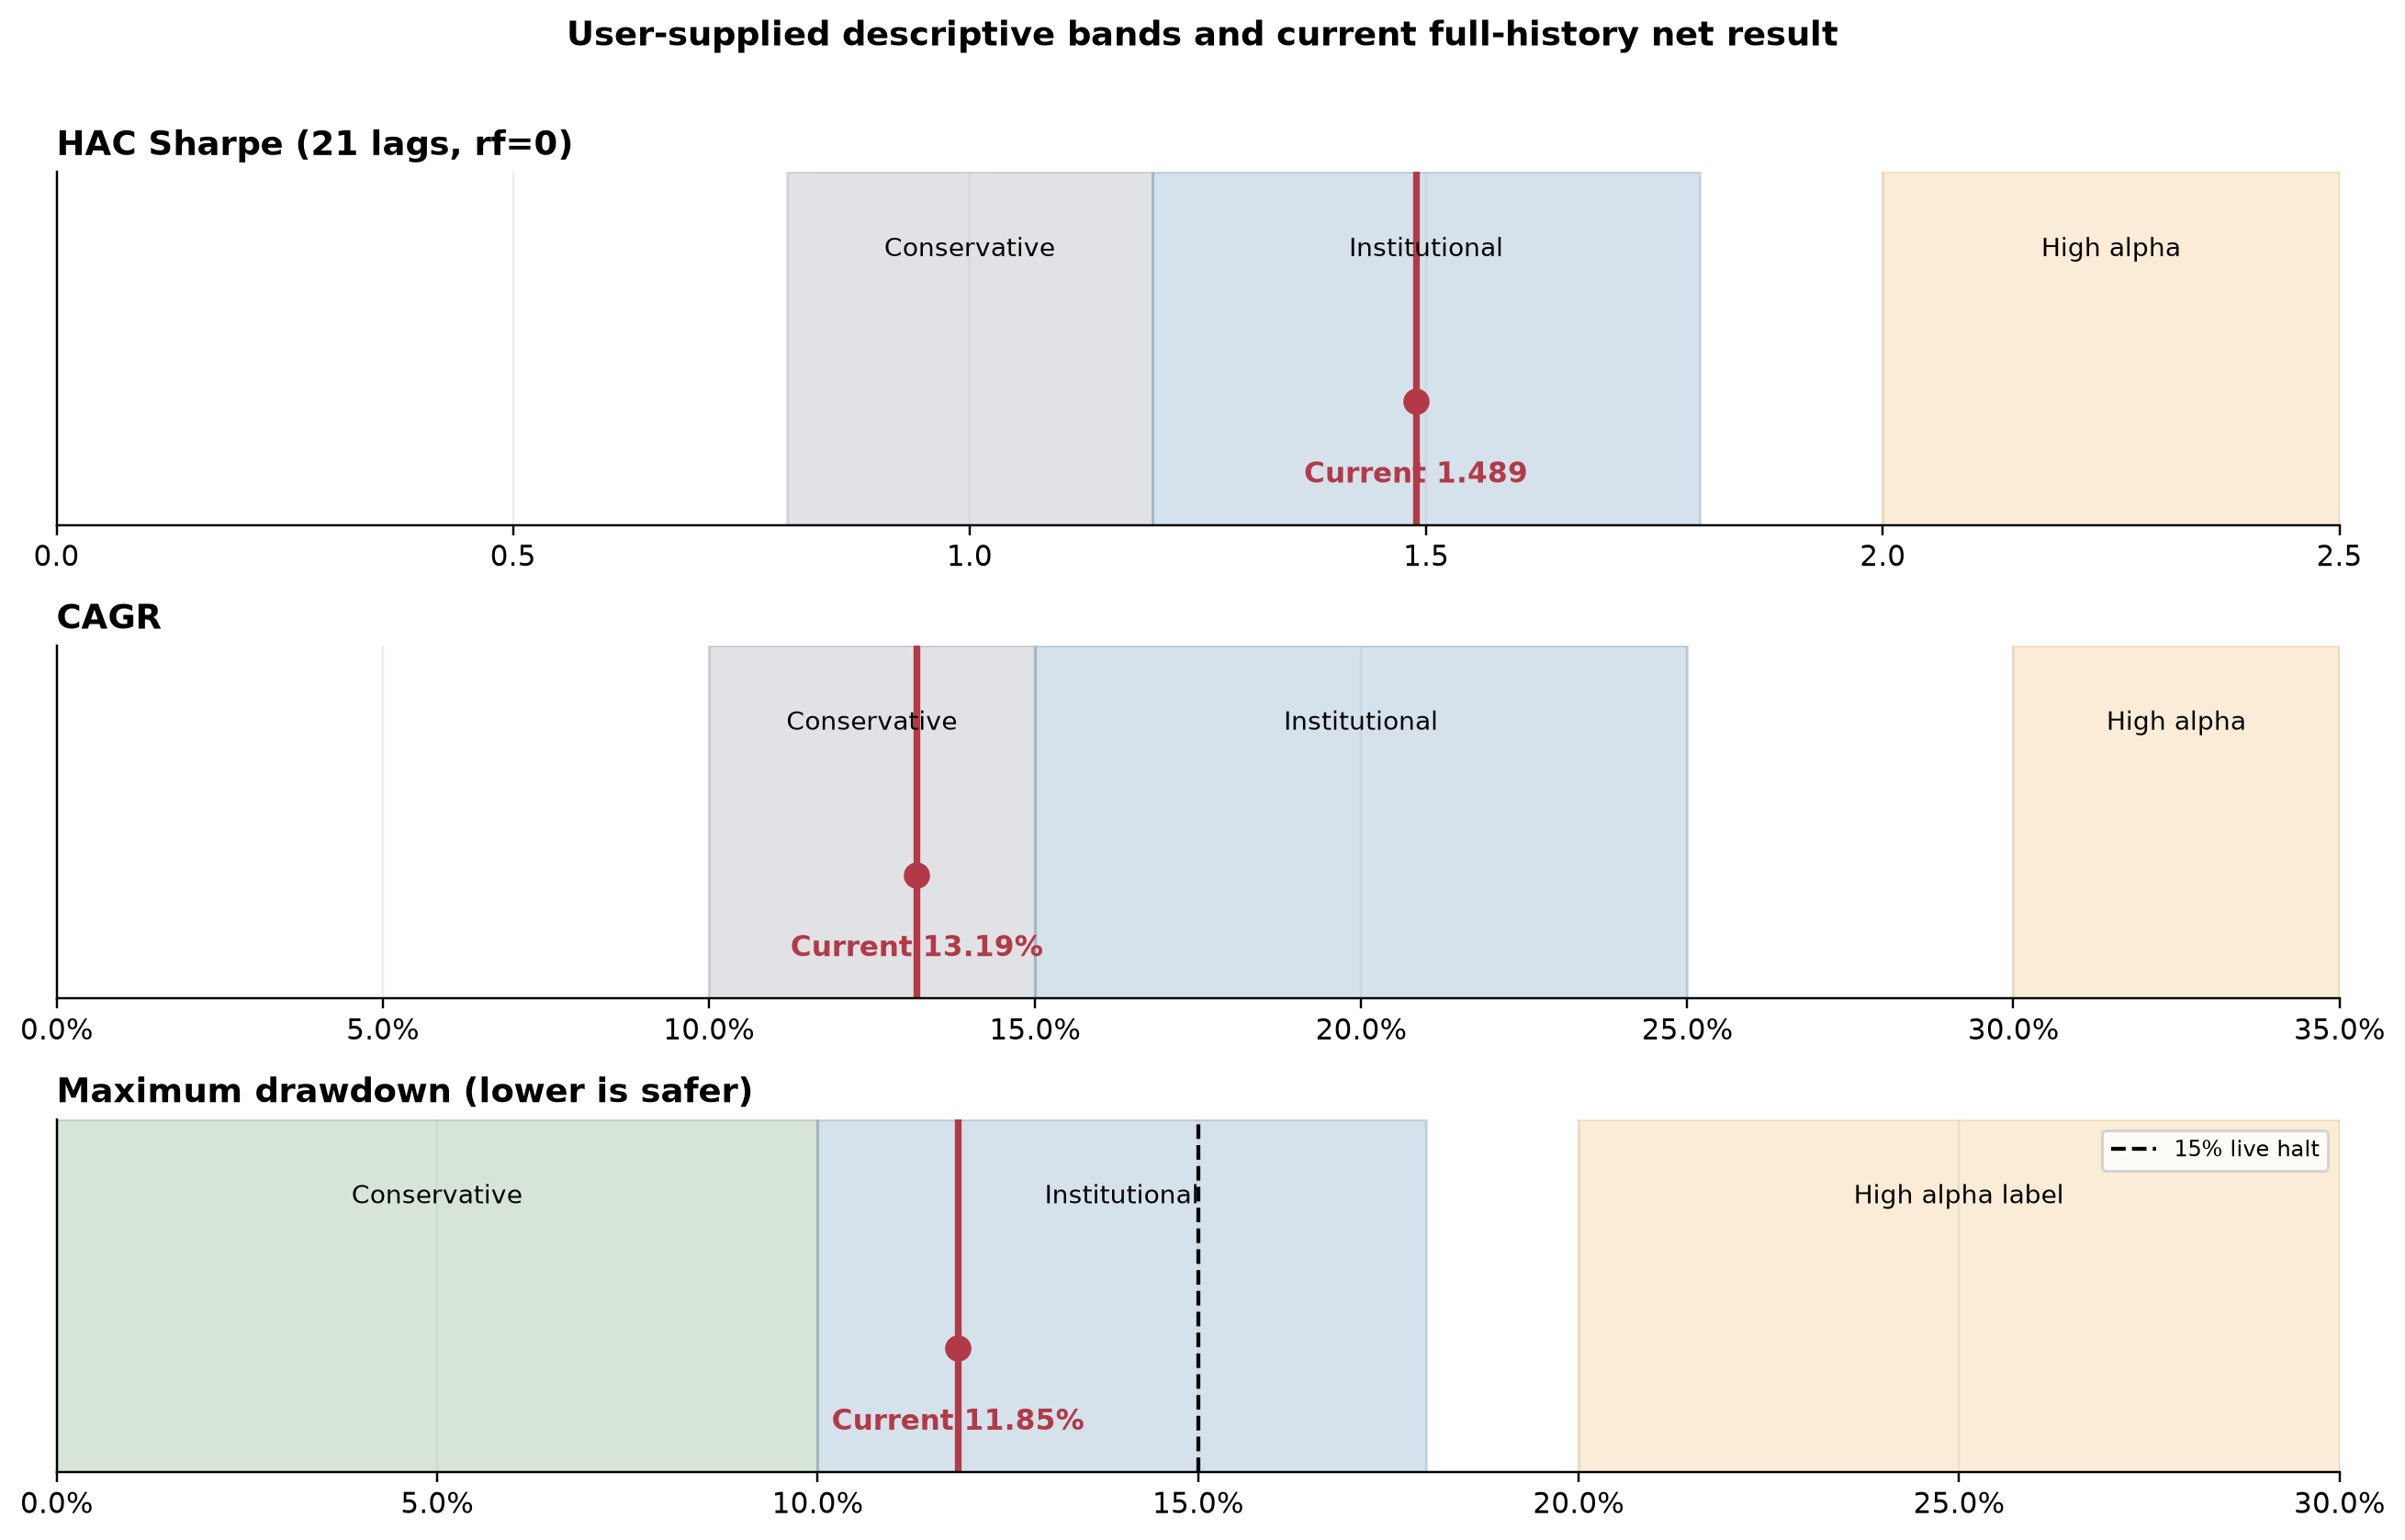

In [3]:
def descriptive_band(metric, value):
    bands = {
        "CAGR": [(0.10, 0.15, "Conservative"), (0.15, 0.25, "Institutional"), (0.30, np.inf, "High alpha")],
        "Sharpe": [(0.80, 1.20, "Conservative"), (1.20, 1.80, "Institutional"), (2.00, np.inf, "High alpha")],
        "Maximum drawdown": [(0.00, 0.10, "Conservative"), (0.10, 0.18, "Institutional"), (0.20, 0.30, "High alpha label")],
    }
    for lower, upper, label in bands[metric]:
        if lower <= value < upper or (np.isinf(upper) and value >= lower):
            return label
    return "Outside supplied bands"

cagr_band = descriptive_band("CAGR", float(full["CAGR"]))
sharpe_band = descriptive_band(
    "Sharpe", float(full["HAC Sharpe (21 lags, rf=0)"])
)
drawdown_band = descriptive_band(
    "Maximum drawdown", abs(float(full["Max drawdown"]))
)
benchmark_context = pd.DataFrame([
    {
        "Metric": "CAGR",
        "Current net result": f"{full['CAGR']:.2%}",
        "Classification": cagr_band,
        "Committee interpretation": "Descriptive reused-history band; not a target",
    },
    {
        "Metric": "Sharpe (rf=0)",
        "Current net result": (
            f"{full['Naive daily Sharpe (sqrt252, rf=0)']:.3f} daily / "
            f"{full['Monthly Sharpe (rf=0)']:.3f} monthly / "
            f"{full['HAC Sharpe (21 lags, rf=0)']:.3f} HAC"
        ),
        "Classification": sharpe_band,
        "Committee interpretation": f"Use HAC {full['HAC Sharpe (21 lags, rf=0)']:.3f} as the conservative headline",
    },
    {
        "Metric": "Sortino (rf=0)",
        "Current net result": f"{full['Sortino (rf=0)']:.3f}",
        "Classification": "Supplementary — no supplied band",
        "Committee interpretation": "Not interchangeable with Sharpe >2",
    },
    {
        "Metric": "Maximum drawdown",
        "Current net result": f"{abs(full['Max drawdown']):.2%}",
        "Classification": drawdown_band,
        "Committee interpretation": (
            f"{live_limits.max_drawdown_fraction - abs(full['Max drawdown']):.2%} "
            "historical headroom to the separate runtime halt"
        ),
    },
    {
        "Metric": "Overall",
        "Current net result": "—",
        "Classification": "Descriptive only",
        "Committee interpretation": "Historical bands cannot change the BLOCKED launch status",
    },
])
display(benchmark_context)

actuals = [
    full["HAC Sharpe (21 lags, rf=0)"],
    full["CAGR"],
    abs(full["Max drawdown"]),
]
panels = [
    {
        "title": "HAC Sharpe (21 lags, rf=0)", "xlim": (0, 2.5),
        "bands": [(0.8, 1.2, "Conservative", COLORS["gray"]),
                  (1.2, 1.8, "Institutional", COLORS["blue"]),
                  (2.0, 2.5, "High alpha", COLORS["amber"])],
        "percent": False,
    },
    {
        "title": "CAGR", "xlim": (0, 0.35),
        "bands": [(0.10, 0.15, "Conservative", COLORS["gray"]),
                  (0.15, 0.25, "Institutional", COLORS["blue"]),
                  (0.30, 0.35, "High alpha", COLORS["amber"])],
        "percent": True,
    },
    {
        "title": "Maximum drawdown (lower is safer)", "xlim": (0, 0.30),
        "bands": [(0.00, 0.10, "Conservative", COLORS["green"]),
                  (0.10, 0.18, "Institutional", COLORS["blue"]),
                  (0.20, 0.30, "High alpha label", COLORS["amber"])],
        "percent": True,
    },
]
fig, axes = plt.subplots(3, 1, figsize=(12, 7.5))
for axis, panel, actual in zip(axes, panels, actuals):
    for left, right, label, color in panel["bands"]:
        axis.axvspan(left, right, color=color, alpha=0.20)
        axis.text((left + right) / 2, 0.78, label, ha="center", va="center", fontsize=9)
    axis.axvline(actual, color=COLORS["red"], lw=2.4)
    actual_label = f"{actual:.2%}" if panel["percent"] else f"{actual:.3f}"
    axis.scatter([actual], [0.35], s=70, color=COLORS["red"], zorder=3)
    axis.text(actual, 0.12, f"Current {actual_label}", ha="center", color=COLORS["red"], weight="bold")
    axis.set_xlim(*panel["xlim"])
    axis.set_ylim(0, 1)
    axis.set_yticks([])
    axis.set_title(panel["title"], loc="left")
    if panel["percent"]:
        axis.xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[2].axvline(
    live_limits.max_drawdown_fraction,
    color="black",
    linestyle="--",
    lw=1.4,
    label=f"{live_limits.max_drawdown_fraction:.0%} live halt",
)
axes[2].legend(loc="upper right", fontsize=8)
fig.suptitle("User-supplied descriptive bands and current full-history net result", y=1.01, weight="bold")
fig.tight_layout()
plt.show()


### The 20% / 2.0 aspiration and rejected leverage sensitivity

The aspiration is not a backtest constraint. The table below derives
its arithmetic from the generated full-history volatility; it does not
search a volatility target. A separately audited 9.3% risk-target
sensitivity was rejected because it raised exposure rather than
durable risk-adjusted edge, did not establish the joint aspiration in
full and later reused history, left inadequate drawdown headroom, and
materially increased daily-bootstrap breach risk. It is neither the
selected configuration nor a canonical v3.2.1 output, so its point
estimates are intentionally not promoted in this notebook.


In [4]:
aspiration_cagr = 0.20
aspiration_sharpe = 2.0
observed_volatility = float(full["Annualized volatility"])
required_sharpe = (
    math.log1p(aspiration_cagr) + 0.5 * observed_volatility**2
) / observed_volatility
implied_cagr_at_two = math.expm1(
    aspiration_sharpe * observed_volatility
    - 0.5 * observed_volatility**2
)
aspiration_context = pd.DataFrame([
    {
        "Quantity": "Observed annualized volatility",
        "Value": f"{observed_volatility:.2%}",
        "Meaning": "Generated canonical full-history estimate",
    },
    {
        "Quantity": "Sharpe required for 20% CAGR",
        "Value": f"{required_sharpe:.2f}",
        "Meaning": "Lognormal approximation; not a promotion threshold",
    },
    {
        "Quantity": "CAGR implied by Sharpe 2.0",
        "Value": f"{implied_cagr_at_two:.2%}",
        "Meaning": "At observed volatility under the same approximation",
    },
])
display(aspiration_context)


,Quantity,Value,Meaning
0,Observed annualized volatility,7.72%,Generated canonical full-history estimate
1,Sharpe required for 20% CAGR,2.40,Lognormal approximation; not a promotion thres...
2,CAGR implied by Sharpe 2.0,16.35%,At observed volatility under the same approxim...


### Bounded alpha-signal challenge — incumbent retained

A small predeclared reused-history audit ran 6/12-month and
3/6/12-month sign-trend ensembles plus equal-asset-class risk through
the unchanged execution ledger. Each reduced full-history CAGR and
daily/HAC Sharpe; the same direction appeared in the later reused
window. Paired stationary-block differences did not establish an
improvement. The 9.3% risk-target row was leverage only and was
rejected for the reasons above.

None was adopted. The two ASX yield-quoted contracts were removed only
after a valuation-correctness audit—not as a return-ranked candidate.
These are reused-history rejection tests, not untouched validation.
Challenger paths are not canonical v3.2.1 outputs, so this notebook does
not reproduce or elevate their point estimates.


,Bounded diagnostic,Reused-history conclusion,Decision
0,6m/12m sign ensemble,Lower return and risk-adjusted metrics across ...,Reject
1,3m/6m/12m sign ensemble,Lower return and risk-adjusted metrics; drawdo...,Reject
2,Equal asset-class risk,Lower durable return/Sharpe despite slightly d...,Reject
3,9.3% volatility target,"Higher exposure, no durable Sharpe gain, inade...",Reject — leverage only


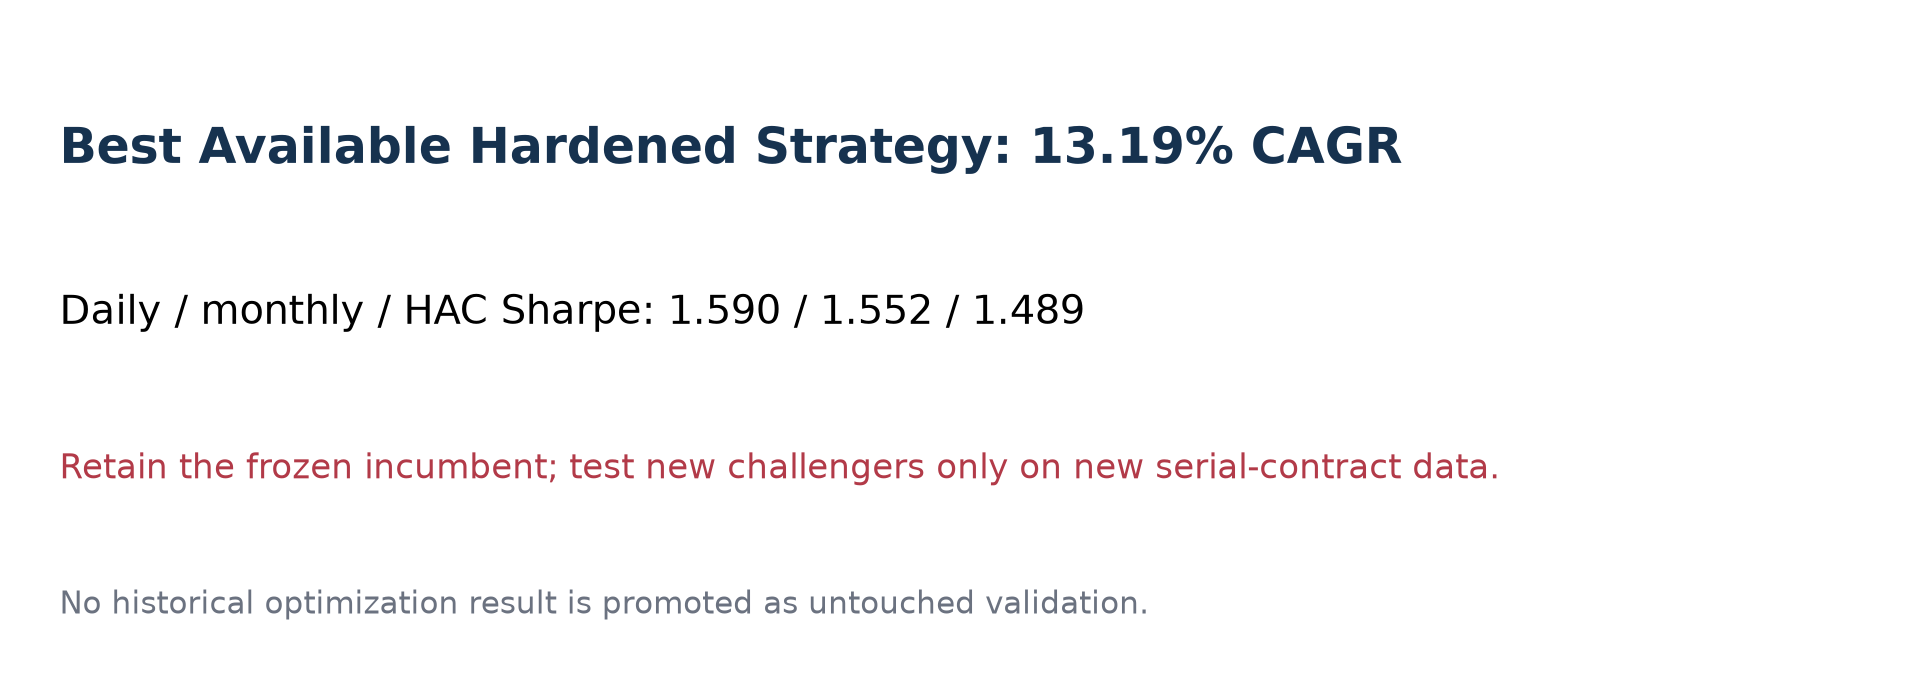

In [5]:
challenger_review = pd.DataFrame([
    ["6m/12m sign ensemble", "Lower return and risk-adjusted metrics across reused windows", "Reject"],
    ["3m/6m/12m sign ensemble", "Lower return and risk-adjusted metrics; drawdown trade-off is not alpha", "Reject"],
    ["Equal asset-class risk", "Lower durable return/Sharpe despite slightly different cost allocation", "Reject"],
    ["9.3% volatility target", "Higher exposure, no durable Sharpe gain, inadequate drawdown headroom", "Reject — leverage only"],
], columns=["Bounded diagnostic", "Reused-history conclusion", "Decision"])
display(challenger_review)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axis("off")
ax.text(
    0.02,
    0.78,
    f"{STRATEGY_DESIGNATION}: {full['CAGR']:.2%} CAGR",
    fontsize=16,
    color=COLORS["navy"],
    weight="bold",
)
ax.text(0.02, 0.53, f"Daily / monthly / HAC Sharpe: {full['Naive daily Sharpe (sqrt252, rf=0)']:.3f} / {full['Monthly Sharpe (rf=0)']:.3f} / {full['HAC Sharpe (21 lags, rf=0)']:.3f}", fontsize=13)
ax.text(0.02, 0.29, "Retain the frozen incumbent; test new challengers only on new serial-contract data.", fontsize=11, color=COLORS["red"])
ax.text(0.02, 0.08, "No historical optimization result is promoted as untouched validation.", fontsize=10, color=COLORS["gray"])
plt.show()


### Prospective improvement protocol — new data only

Further optimization on 1990–2014 is prohibited. A defensible attempt
to move toward an enhanced-institutional profile requires newly
acquired post-2014 serial-contract data and no more than three frozen
challengers:

1. direct first/second-expiry curve basis momentum, retaining the
   frozen 50/50 trend/basis weights;
2. genuine, release-lagged CFTC hedging pressure in covered commodity
   markets with a fixed predeclared weight; and
3. point-in-time breadth expansion admitted by economic uniqueness,
   specifications, history, and capacity—not observed returns.

Freeze formulas, weights, universe rules, calibrated costs, and
code/data hashes before opening the evaluation period. Compare all
three with the incumbent at the same frozen risk target using a paired
stationary-block max-statistic with familywise multiple-testing
control. Alpha promotion requires adjusted evidence of improvement,
at least +0.10 HAC Sharpe and +1 percentage point CAGR, non-worse Sortino,
profit factor at least 1.5, maximum drawdown within the configured
runtime limit, positive double-calibrated-cost economics, and unchanged
capacity/exposure gates. A direct-curve basis implementation may pass
only as an operational non-inferiority replacement; correctness is not
alpha.


## 3. Evidence timeline and data coverage

- **1977–1989:** signal/risk warm-up only; the live ledger is flat.
- **1990–2004:** inspected development history.
- **2005–2014:** reused later diagnostic—not out-of-sample.
- **2015 onward:** absent. No independent holdout exists.

A late first observation is not automatically a data error; many
contracts began later. Missing fractions also include time before a
market's inception. The chart is an availability diagnostic, not proof
of a survivorship-free point-in-time universe.


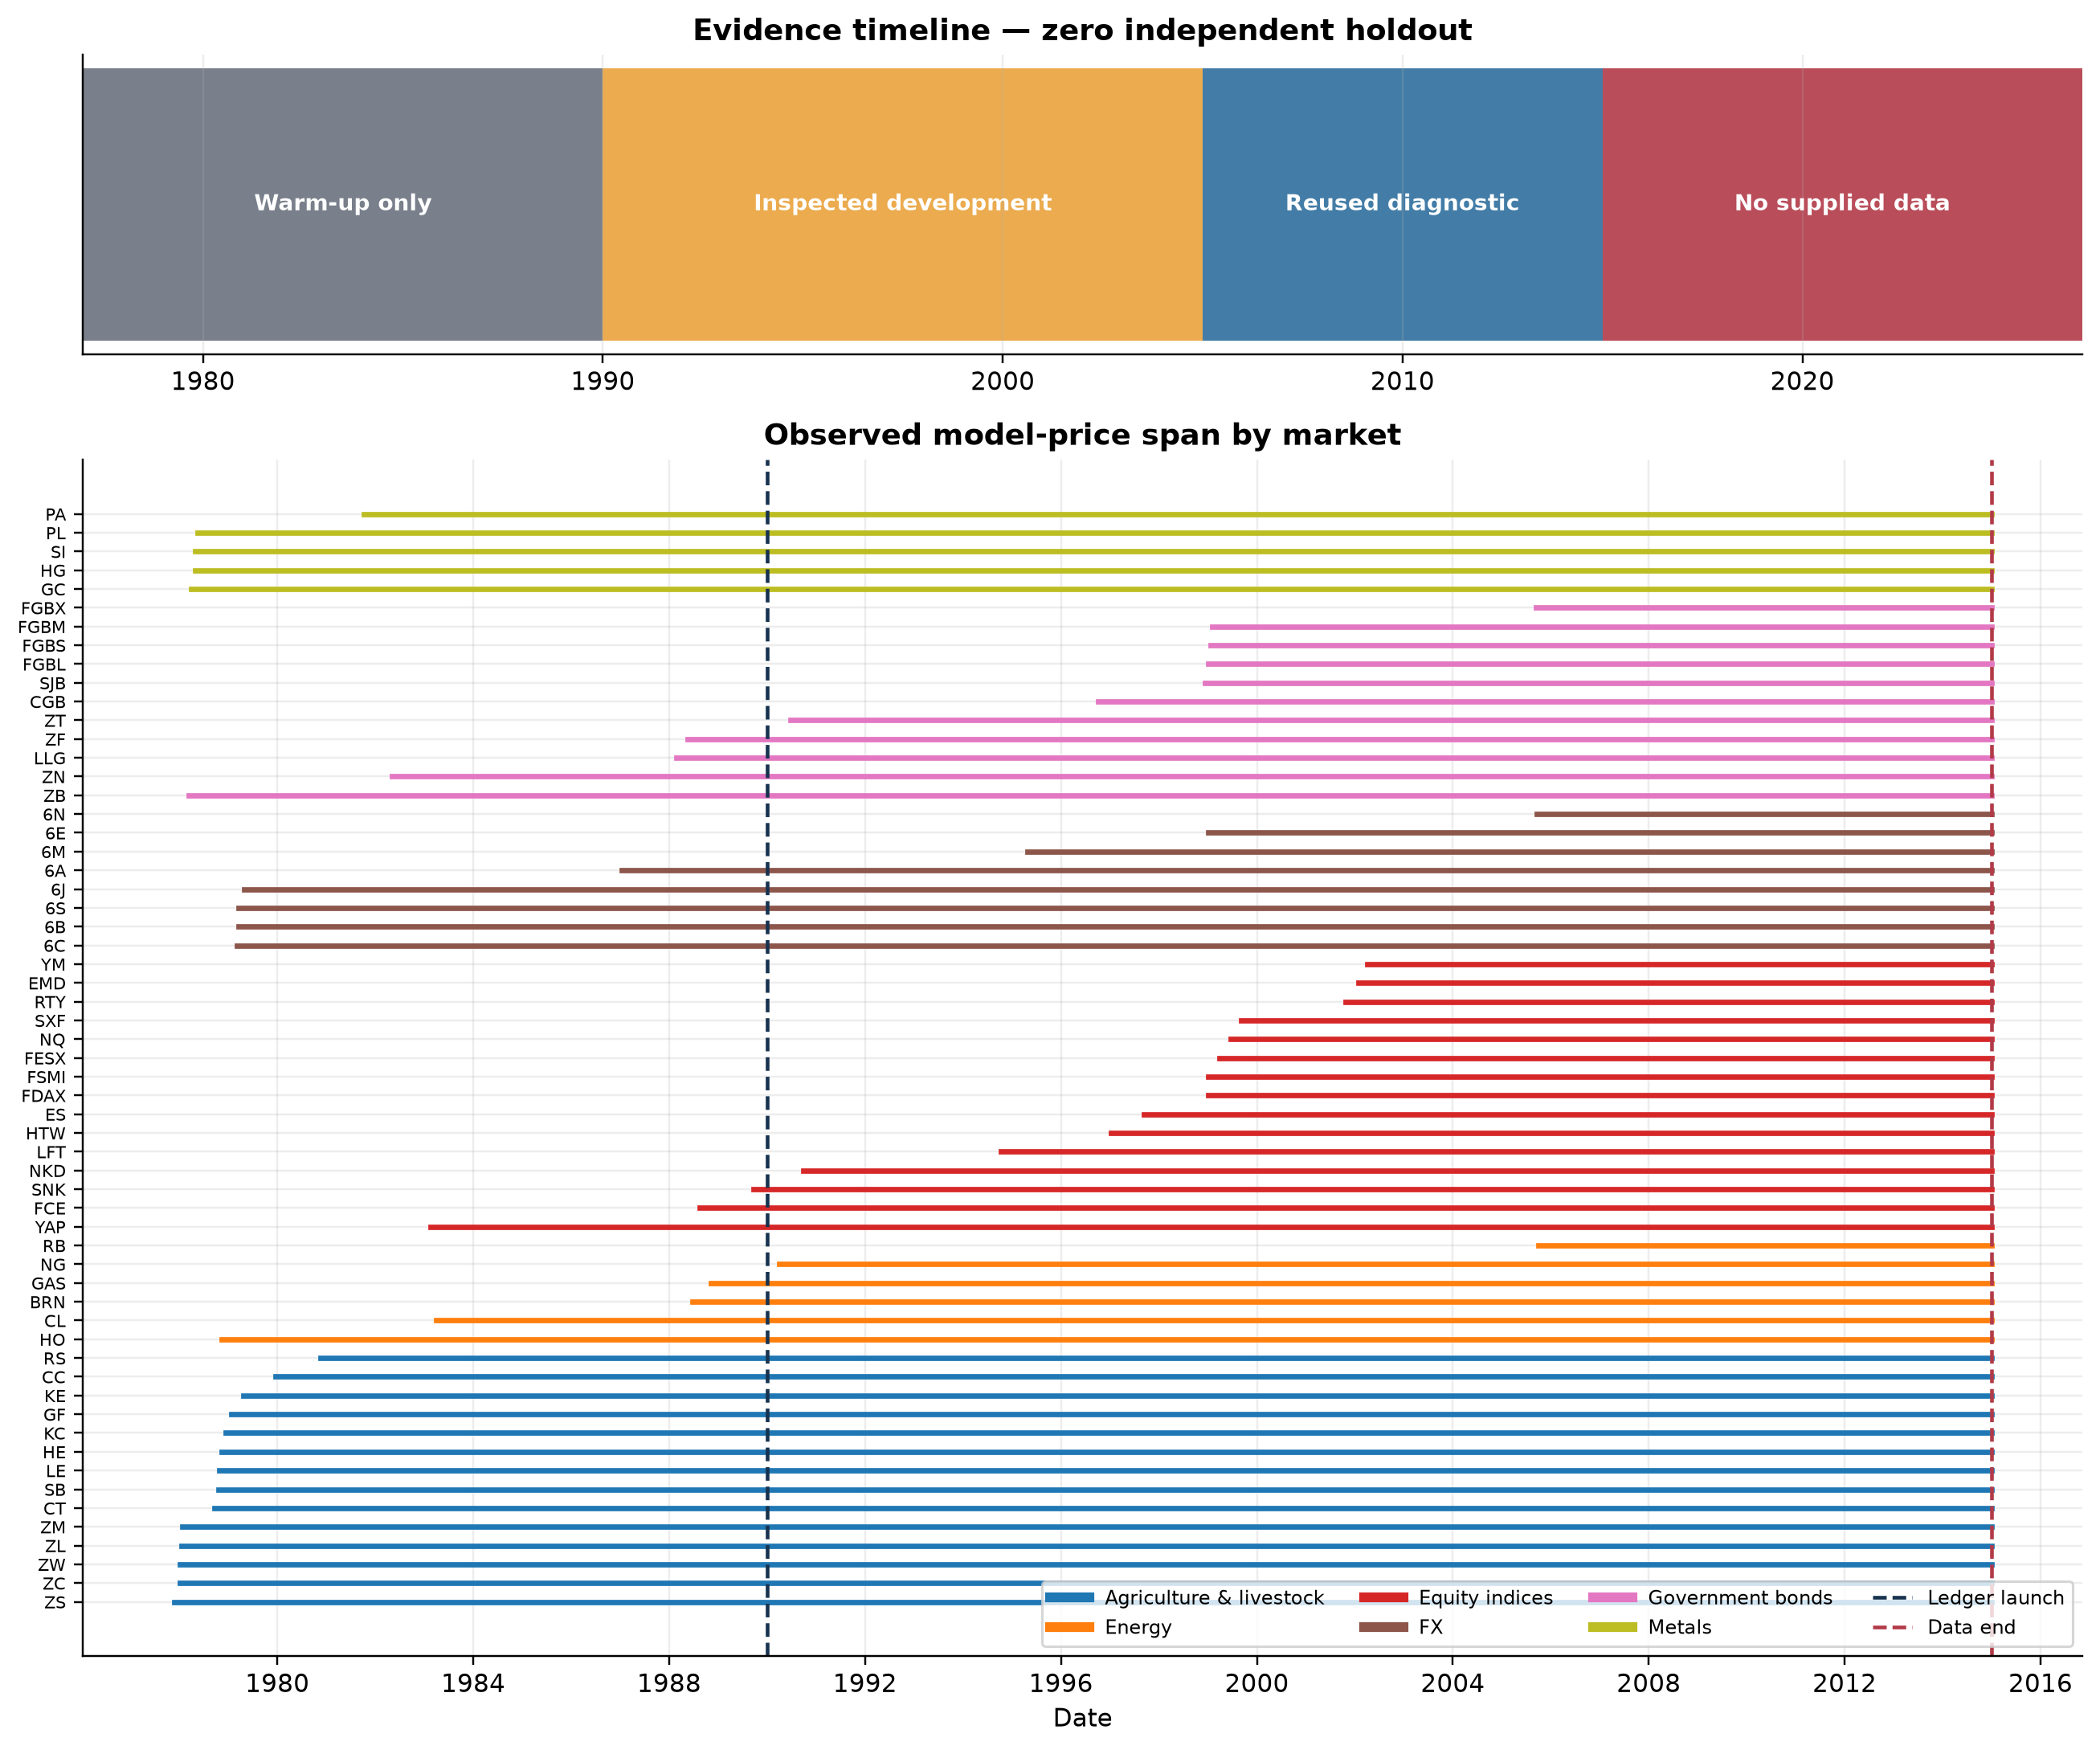

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={"height_ratios": [1, 4]})
timeline = [
    (1977, 1990, "Warm-up only", COLORS["gray"]),
    (1990, 2005, "Inspected development", COLORS["amber"]),
    (2005, 2015, "Reused diagnostic", COLORS["blue"]),
    (2015, 2027, "No supplied data", COLORS["red"]),
]
for start, end, label, color in timeline:
    axes[0].barh(0, end - start, left=start, color=color, alpha=0.9, height=0.45)
    axes[0].text((start + end) / 2, 0, label, ha="center", va="center", color="white", fontsize=9, weight="bold")
axes[0].set_xlim(1977, 2027)
axes[0].set_yticks([])
axes[0].set_title("Evidence timeline — zero independent holdout")

ordered = quality.sort_values(["asset_class", "first_model_price", "symbol"]).reset_index(drop=True)
class_order = ordered["asset_class"].drop_duplicates().tolist()
class_colors = dict(zip(class_order, plt.cm.tab10(np.linspace(0, 0.85, len(class_order)))))
for y, row in ordered.iterrows():
    axes[1].plot(
        [row["first_model_price"], row["last_model_price"]], [y, y],
        color=class_colors[row["asset_class"]], linewidth=2.2,
    )
axes[1].axvline(pd.Timestamp("1990-01-01"), color=COLORS["navy"], linestyle="--", label="Ledger launch")
axes[1].axvline(pd.Timestamp("2014-12-31"), color=COLORS["red"], linestyle="--", label="Data end")
axes[1].set_yticks(range(len(ordered)))
axes[1].set_yticklabels(ordered["symbol"], fontsize=7)
axes[1].set_title("Observed model-price span by market")
axes[1].set_xlabel("Date")
handles = [plt.Line2D([0], [0], color=color, lw=4, label=label) for label, color in class_colors.items()]
handles += list(axes[1].get_legend_handles_labels()[0])
axes[1].legend(handles=handles, ncol=4, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()


## 4. Model, timing, and control architecture

The alpha path and the operational path are deliberately separate.
Continuous research symbols never become broker orders. Paper/live
orders must identify a serial expiry and pass the same contract,
liquidity, exposure, evidence, health, reconciliation, and kill-state
controls.

The research package also includes a hash-linked append-only trial
registry with a three-candidate batch default. It records a frozen
protocol but does not provide independent timestamping or reconstruct
omitted legacy trials. The controls package includes a treasury
evidence validator for settlement, cash, collateral, margin, funding
and balanced journals. It remains an integration scaffold—not
broker-supplied evidence or a funded live ledger.

Live routing also binds every risk-increasing order to the certified
production broker identity, an approved compliance-policy digest, a
fresh external decision on the exact batch, and the signed intent. The
broker identity is checked before the outbox and again before
submission. The repository does not supply the external signer, policy
provider/artifact, certified adapter, or broker evidence.

Decision timing: information through close *t* forms an intent after
that close. Under the canonical research assumption it can fill at the
next eligible close *t+1*; the new position first earns close-to-close
P&L after the fill. Extra-session delay is stressable.


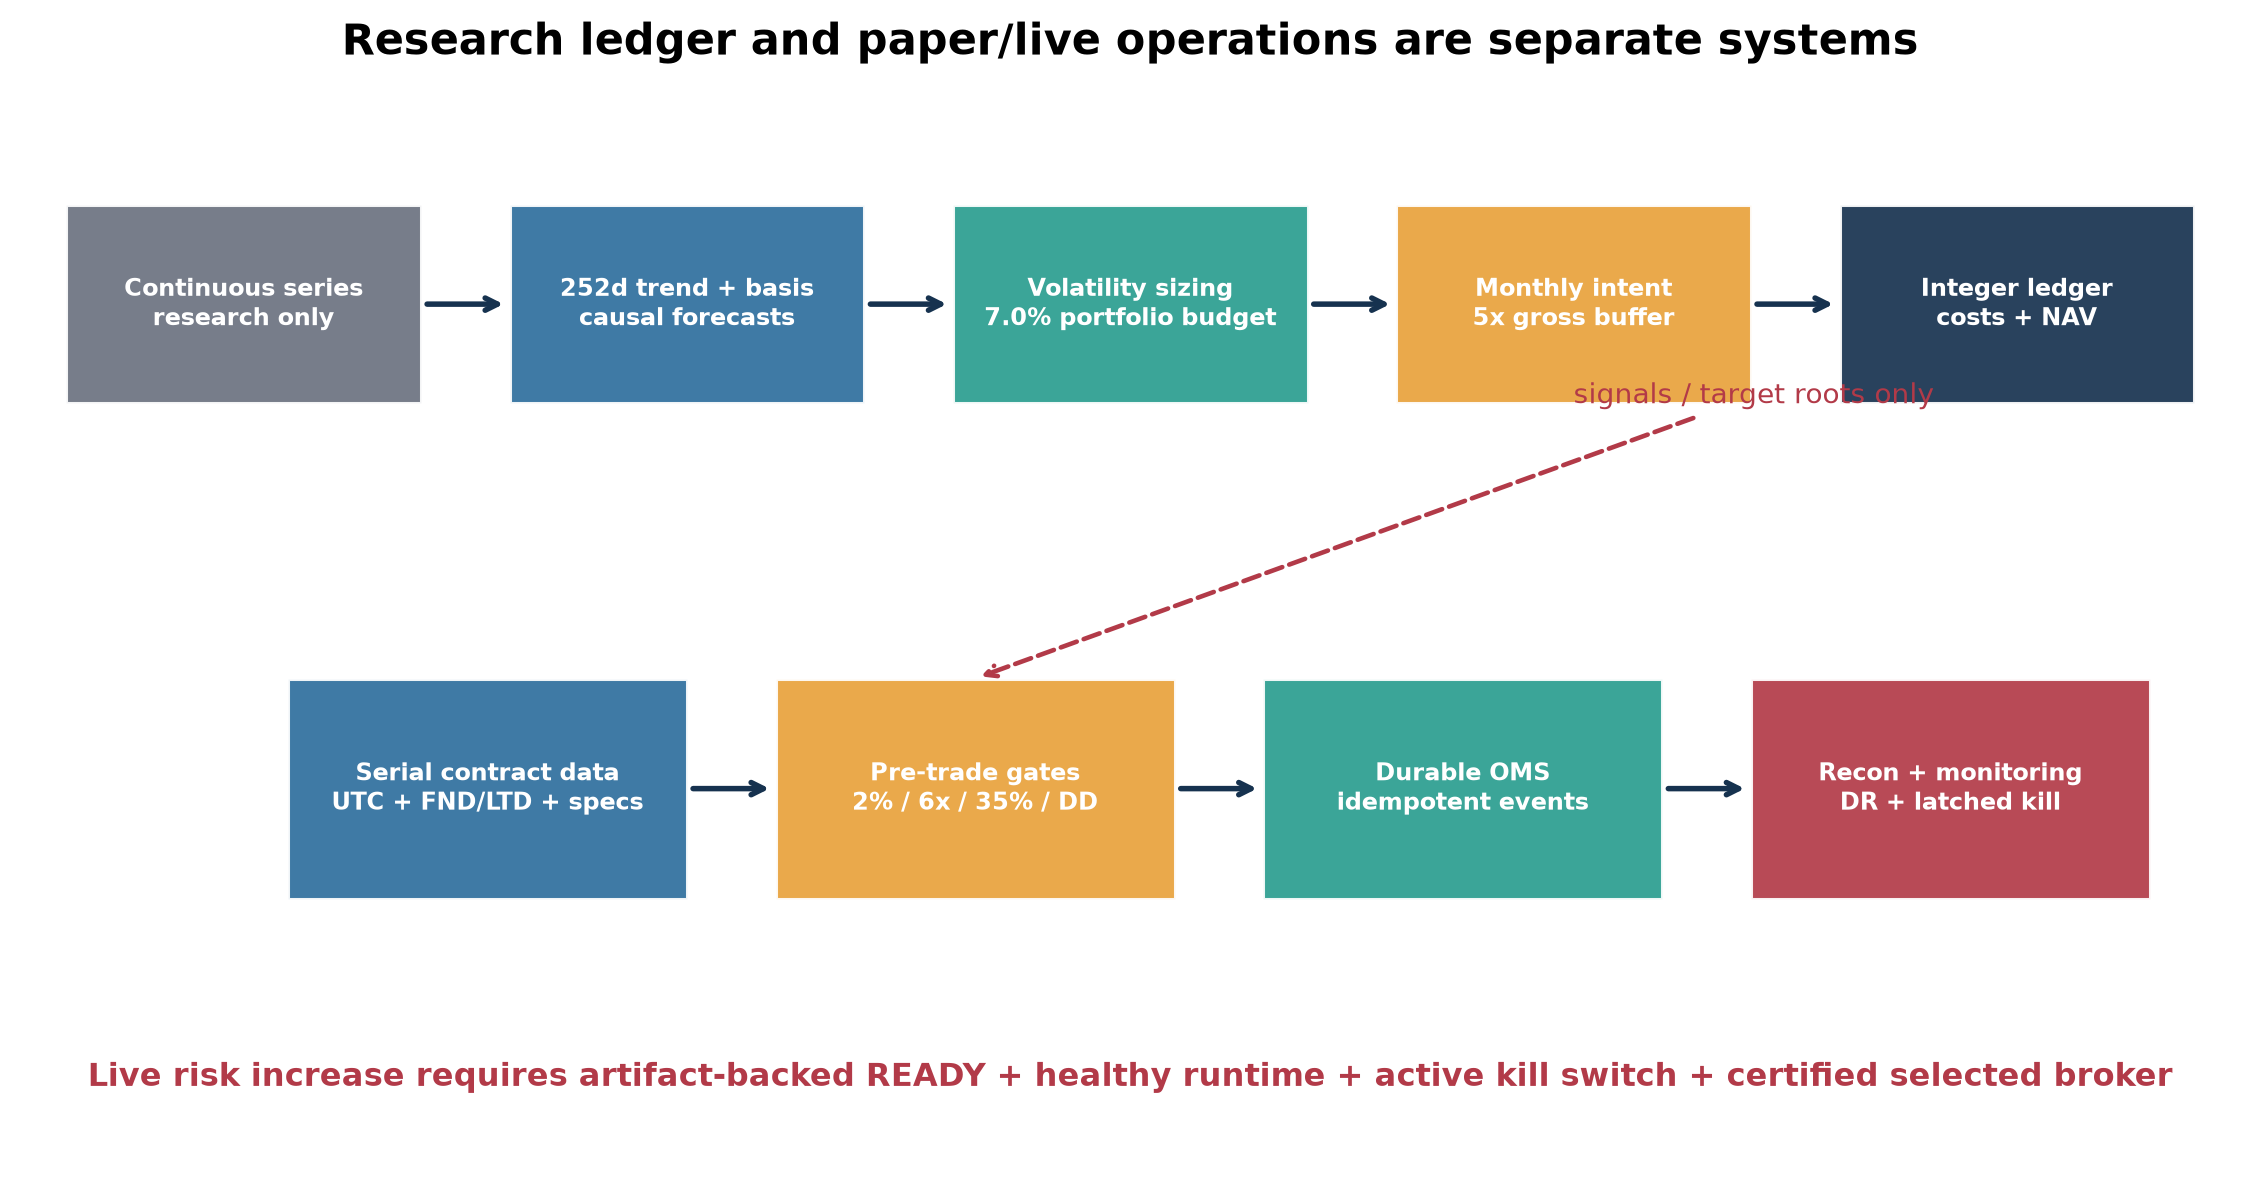

,Group,Parameter,Frozen value
0,Alpha,trend_lookback,252
1,Alpha,basis_weight,0.5
2,Risk,target_vol,0.07
3,Risk,risk_budget,flat
4,Execution,max_rebalance_participation,0.02
5,Execution,max_gross_notional_multiple,5.0
6,Execution,max_static_margin_fraction,None
7,Execution,execution_timing,next_close
8,Costs,half_spread_ticks,0.5
9,Costs,slippage_ticks,0.25


In [7]:
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.axis("off")
boxes = [
    (0.02, 0.70, 0.16, 0.18, "Continuous series\nresearch only", COLORS["gray"]),
    (0.22, 0.70, 0.16, 0.18, "252d trend + basis\ncausal forecasts", COLORS["blue"]),
    (0.42, 0.70, 0.16, 0.18, f"Volatility sizing\n{research_target_vol:.1%} portfolio budget", COLORS["teal"]),
    (0.62, 0.70, 0.16, 0.18, f"Monthly intent\n{research_gross_limit:g}x gross buffer", COLORS["amber"]),
    (0.82, 0.70, 0.16, 0.18, "Integer ledger\ncosts + NAV", COLORS["navy"]),
    (0.12, 0.25, 0.18, 0.20, "Serial contract data\nUTC + FND/LTD + specs", COLORS["blue"]),
    (
        0.34, 0.25, 0.18, 0.20,
        f"Pre-trade gates\n{live_limits.max_order_participation:.0%} / "
        f"{live_limits.max_gross_notional_multiple:g}x / "
        f"{live_limits.max_margin_fraction:.0%} / DD",
        COLORS["amber"],
    ),
    (0.56, 0.25, 0.18, 0.20, "Durable OMS\nidempotent events", COLORS["teal"]),
    (0.78, 0.25, 0.18, 0.20, "Recon + monitoring\nDR + latched kill", COLORS["red"]),
]
for x, y, width, height, text, color in boxes:
    patch = plt.Rectangle((x, y), width, height, transform=ax.transAxes, facecolor=color, alpha=0.92, edgecolor="white")
    ax.add_patch(patch)
    ax.text(x + width / 2, y + height / 2, text, transform=ax.transAxes, ha="center", va="center", color="white", weight="bold", fontsize=8)
for left, right, y in [(0.18, 0.22, 0.79), (0.38, 0.42, 0.79), (0.58, 0.62, 0.79), (0.78, 0.82, 0.79),
                       (0.30, 0.34, 0.35), (0.52, 0.56, 0.35), (0.74, 0.78, 0.35)]:
    ax.annotate("", xy=(right, y), xytext=(left, y), xycoords=ax.transAxes, arrowprops=dict(arrowstyle="->", color=COLORS["navy"], lw=1.8))
ax.annotate("signals / target roots only", xy=(0.43, 0.45), xytext=(0.70, 0.70), xycoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->", color=COLORS["red"], lw=1.5, linestyle="--"), color=COLORS["red"], fontsize=9)
ax.text(0.5, 0.08, "Live risk increase requires artifact-backed READY + healthy runtime + active kill switch + certified selected broker", transform=ax.transAxes,
        ha="center", fontsize=10.5, weight="bold", color=COLORS["red"])
ax.set_title("Research ledger and paper/live operations are separate systems", fontsize=14)
plt.show()

parameter_rows = [
    ("Alpha", "trend_lookback", configuration["trend_lookback"]),
    ("Alpha", "basis_weight", configuration["basis_weight"]),
    ("Risk", "target_vol", configuration["target_vol"]),
    ("Risk", "risk_budget", configuration["risk_budget"]),
    ("Execution", "max_rebalance_participation", configuration["max_rebalance_participation"]),
    ("Execution", "max_gross_notional_multiple", configuration["max_gross_notional_multiple"]),
    ("Execution", "max_static_margin_fraction", configuration["max_static_margin_fraction"]),
    ("Execution", "execution_timing", configuration["execution_timing"]),
    ("Costs", "half_spread_ticks", configuration["half_spread_ticks"]),
    ("Costs", "slippage_ticks", configuration["slippage_ticks"]),
    ("Costs", "impact_bps_at_full_participation", configuration["impact_bps_at_full_participation"]),
]
display(pd.DataFrame(parameter_rows, columns=["Group", "Parameter", "Frozen value"]))


## 5. Metric definitions

Let $r_t$ be the net daily return after modeled costs.

- **CAGR:** $(W_T/W_0)^{1/Y}-1$ using elapsed calendar years.
- **Sharpe (rf=0):** $\sqrt{252}\,\bar r/s(r)$. Monthly and 21-lag
  HAC variants are also reported because daily returns are not IID.
- **Sortino:** annualized mean return divided by downside root-mean-square.
- **Maximum drawdown:** $\min_t(W_t/\max_{u\le t}W_u-1)$.
- **Profit factor:** total gains divided by total absolute losses. The
  episode report shows both additive NAV contribution and USD versions.
- **Expectancy:** $p(\text{win})\,E[\text{win}] -
  p(\text{loss})\,E[|\text{loss}|]$ per closed directional episode.

Risk-free return and collateral yield are zero in these reported
metrics, so CAGR is a futures **excess-return CAGR**, not a funded
account return. There is no benchmark. Historical static margin uses a
current catalogue snapshot and is informational only; it does not
resize the corrected history or prove clearing-broker financing.


## 6. Performance and stability

The configured risk budget keeps corrected reused-history drawdown
below the separate runtime gate. This does **not** constitute
independent validation: the policy changed after the history was
observed, and the history ends in 2014. The exact budget and gate are
read from the canonical configuration and production controls below.


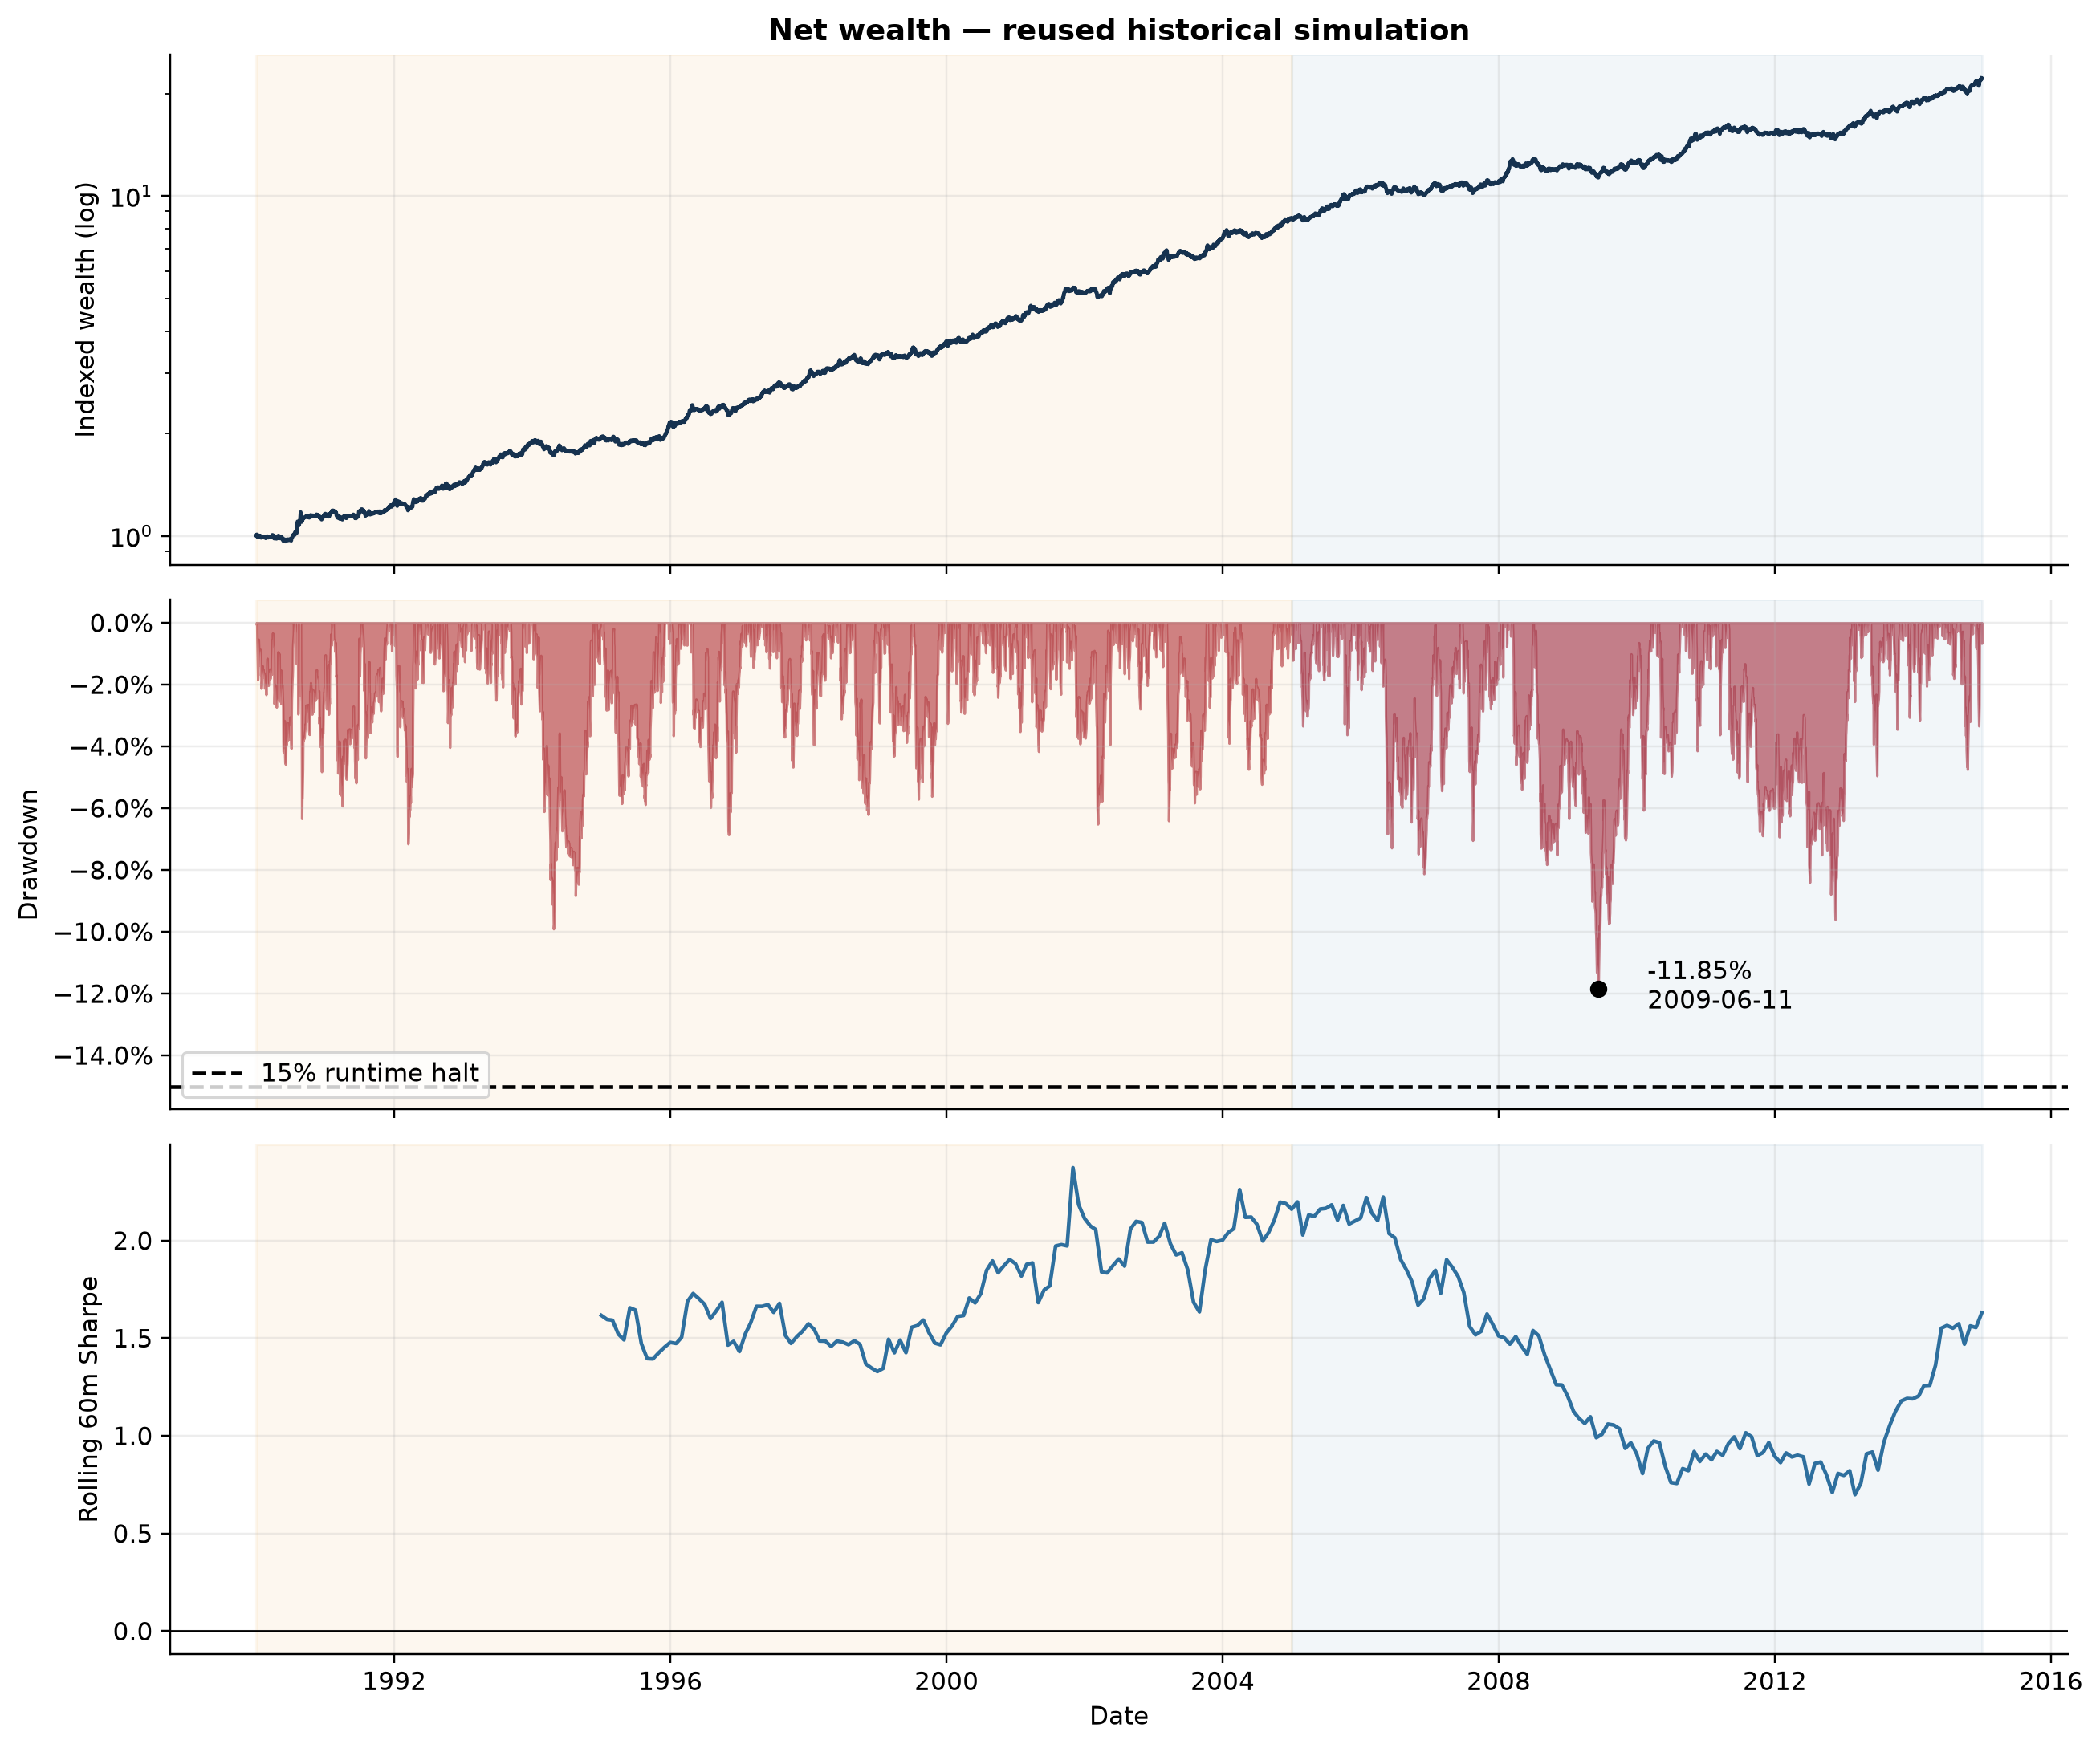

In [8]:
live = daily.loc["1990-01-01":].copy()
equity = live["nav"] / live["prior_nav_usd"].iloc[0]
drawdown = equity / equity.cummax() - 1
monthly_return = (1 + live["net_return"]).resample("ME").prod() - 1
rolling_sharpe = monthly_return.rolling(60).mean() / monthly_return.rolling(60).std() * math.sqrt(12)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(equity.index, equity, color=COLORS["navy"], lw=1.6)
axes[0].set_yscale("log")
axes[0].set_ylabel("Indexed wealth (log)")
axes[0].set_title("Net wealth — reused historical simulation")
axes[1].fill_between(drawdown.index, drawdown.values, 0, color=COLORS["red"], alpha=0.65)
axes[1].axhline(
    -live_limits.max_drawdown_fraction,
    color="black",
    linestyle="--",
    label=f"{live_limits.max_drawdown_fraction:.0%} runtime halt",
)
trough = drawdown.idxmin()
axes[1].scatter([trough], [drawdown.loc[trough]], color="black", zorder=3)
axes[1].annotate(f"{drawdown.loc[trough]:.2%}\n{trough.date()}", xy=(trough, drawdown.loc[trough]), xytext=(20, -8), textcoords="offset points")
axes[1].set_ylabel("Drawdown")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].legend(loc="lower left")
axes[2].plot(rolling_sharpe.index, rolling_sharpe, color=COLORS["blue"], lw=1.5)
axes[2].axhline(0, color="black", lw=0.9)
axes[2].set_ylabel("Rolling 60m Sharpe")
axes[2].set_xlabel("Date")
for ax in axes:
    ax.axvspan(pd.Timestamp("1990-01-01"), pd.Timestamp("2004-12-31"), color=COLORS["amber"], alpha=0.08)
    ax.axvspan(pd.Timestamp("2005-01-01"), pd.Timestamp("2014-12-31"), color=COLORS["blue"], alpha=0.06)
fig.tight_layout()
plt.show()


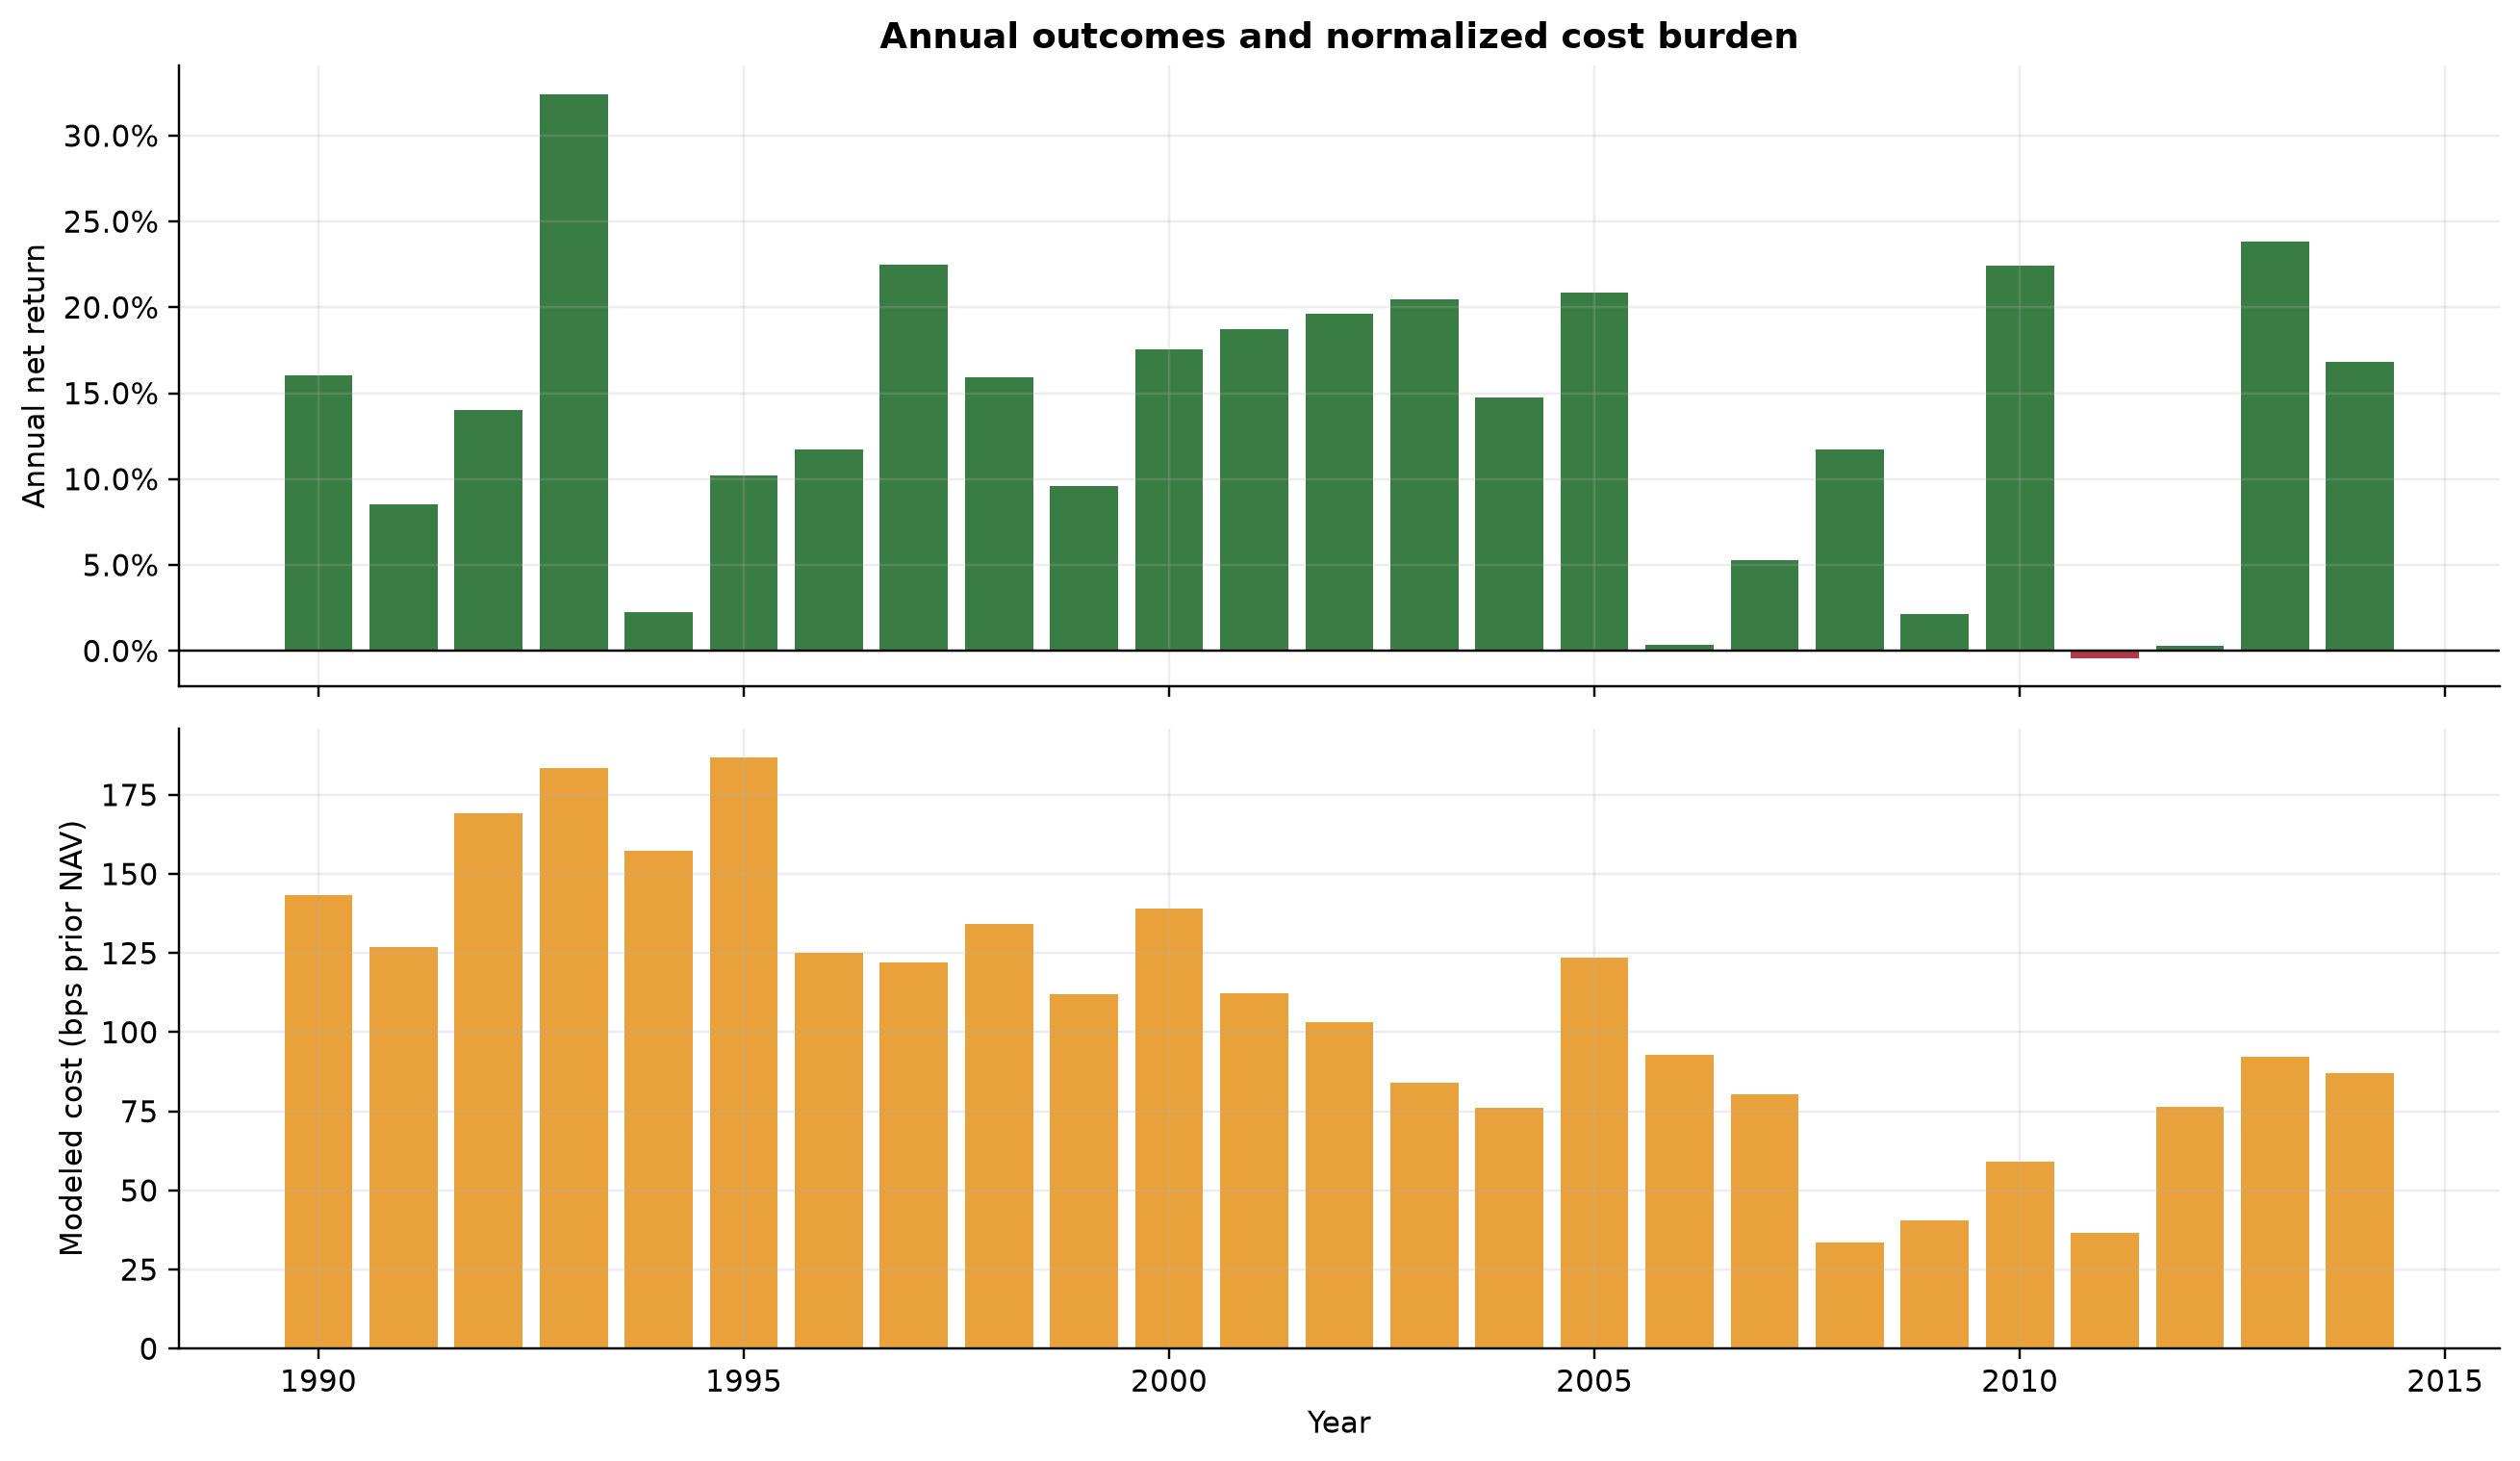

In [9]:
annual_return = (1 + live["net_return"]).resample("YE").prod() - 1
annual_cost_bps = live["cost"].resample("YE").sum() * 10_000
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(annual_return.index.year, annual_return.values, color=np.where(annual_return >= 0, COLORS["green"], COLORS["red"]))
axes[0].axhline(0, color="black", lw=0.8)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].set_ylabel("Annual net return")
axes[0].set_title("Annual outcomes and normalized cost burden")
axes[1].bar(annual_cost_bps.index.year, annual_cost_bps.values, color=COLORS["amber"])
axes[1].set_ylabel("Modeled cost (bps prior NAV)")
axes[1].set_xlabel("Year")
fig.tight_layout()
plt.show()


### Drawdown overlay diagnostic—not an executable result

The causal overlay reacts only to previously observed overlay NAV and
includes a lag and an approximate adjustment cost. It does not rerun
integer contracts, partial fills, exact roll legs, margins, or market
impact. It is retained as a research hypothesis and cannot clear a
readiness gate.


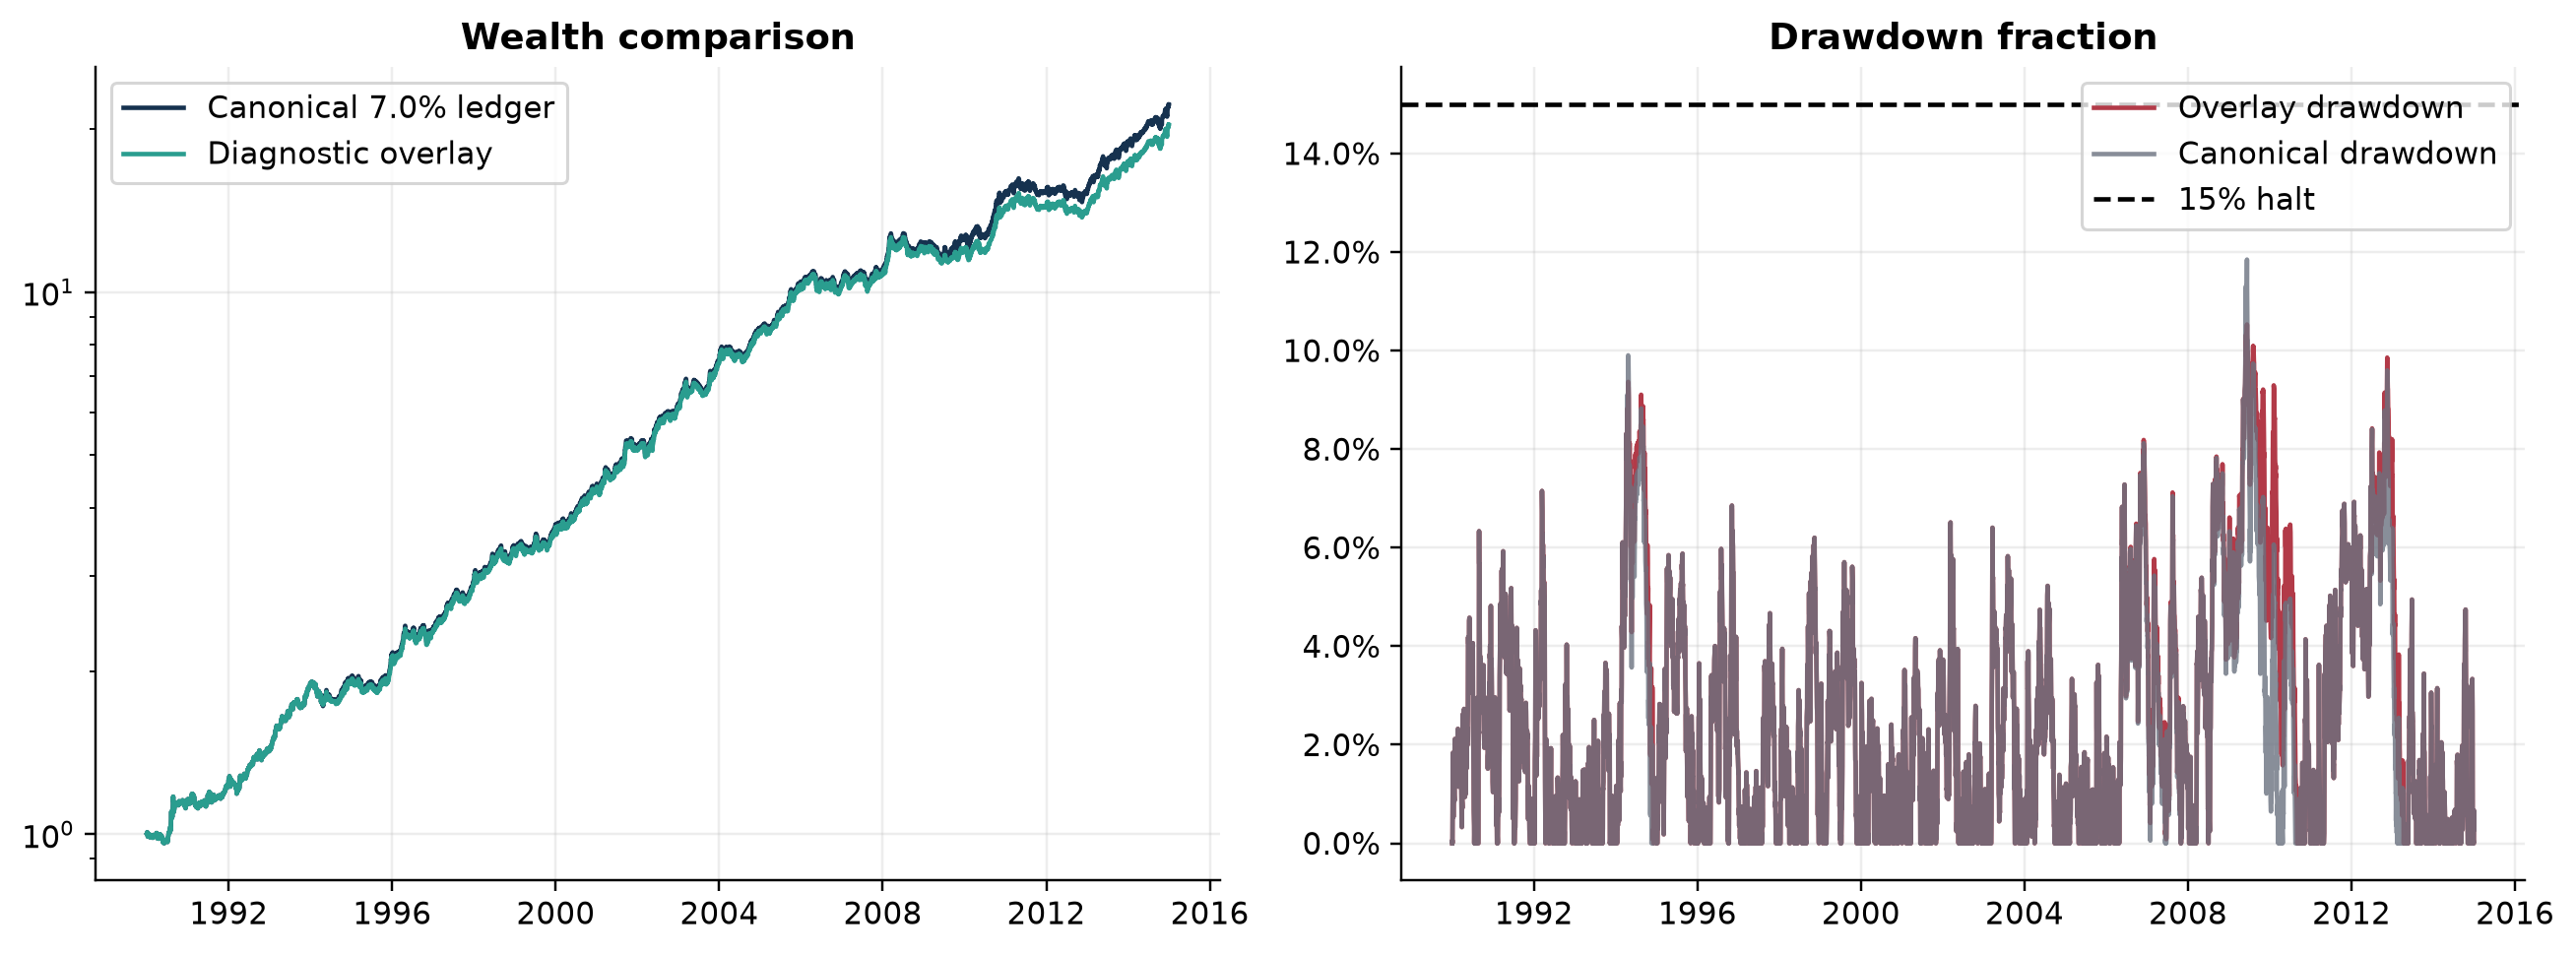

,Path,CAGR,Annualized volatility,Naive daily Sharpe,Max drawdown,Average exposure multiplier,Annual overlay adjustment-cost drag
0,base,0.13190,0.07719,1.58953,-0.11847,1.00000,0.00000
1,drawdown_overlay_diagnostic,0.12804,0.07636,1.56268,-0.10531,0.98529,0.00027


In [10]:
base_wealth = (1 + overlay["base_net_return"]).cumprod()
overlay_wealth = (1 + overlay["overlay_net_return"]).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(
    base_wealth.index,
    base_wealth,
    label=f"Canonical {research_target_vol:.1%} ledger",
    color=COLORS["navy"],
)
axes[0].plot(overlay_wealth.index, overlay_wealth, label="Diagnostic overlay", color=COLORS["teal"])
axes[0].set_yscale("log")
axes[0].set_title("Wealth comparison")
axes[0].legend()
axes[1].plot(overlay.index, overlay["overlay_drawdown_fraction"], color=COLORS["red"], label="Overlay drawdown")
axes[1].plot(overlay.index, 1 - base_wealth / base_wealth.cummax(), color=COLORS["gray"], alpha=0.8, label="Canonical drawdown")
axes[1].axhline(
    live_limits.max_drawdown_fraction,
    color="black",
    linestyle="--",
    label=f"{live_limits.max_drawdown_fraction:.0%} halt",
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_title("Drawdown fraction")
axes[1].legend()
fig.tight_layout()
plt.show()
display(overlay_summary.round(5))


## 7. Trade economics and outcome concentration

A trade episode is one continuous same-direction position in a market.
Same-sign resizes and contract rolls remain inside the episode; a sign
flip closes one and opens another. Open episodes are censored. The
cohort table groups closed episodes by exit date, while the
concentration curve uses all closed and censored contributions so the
displayed attribution reconciles to the ledger.


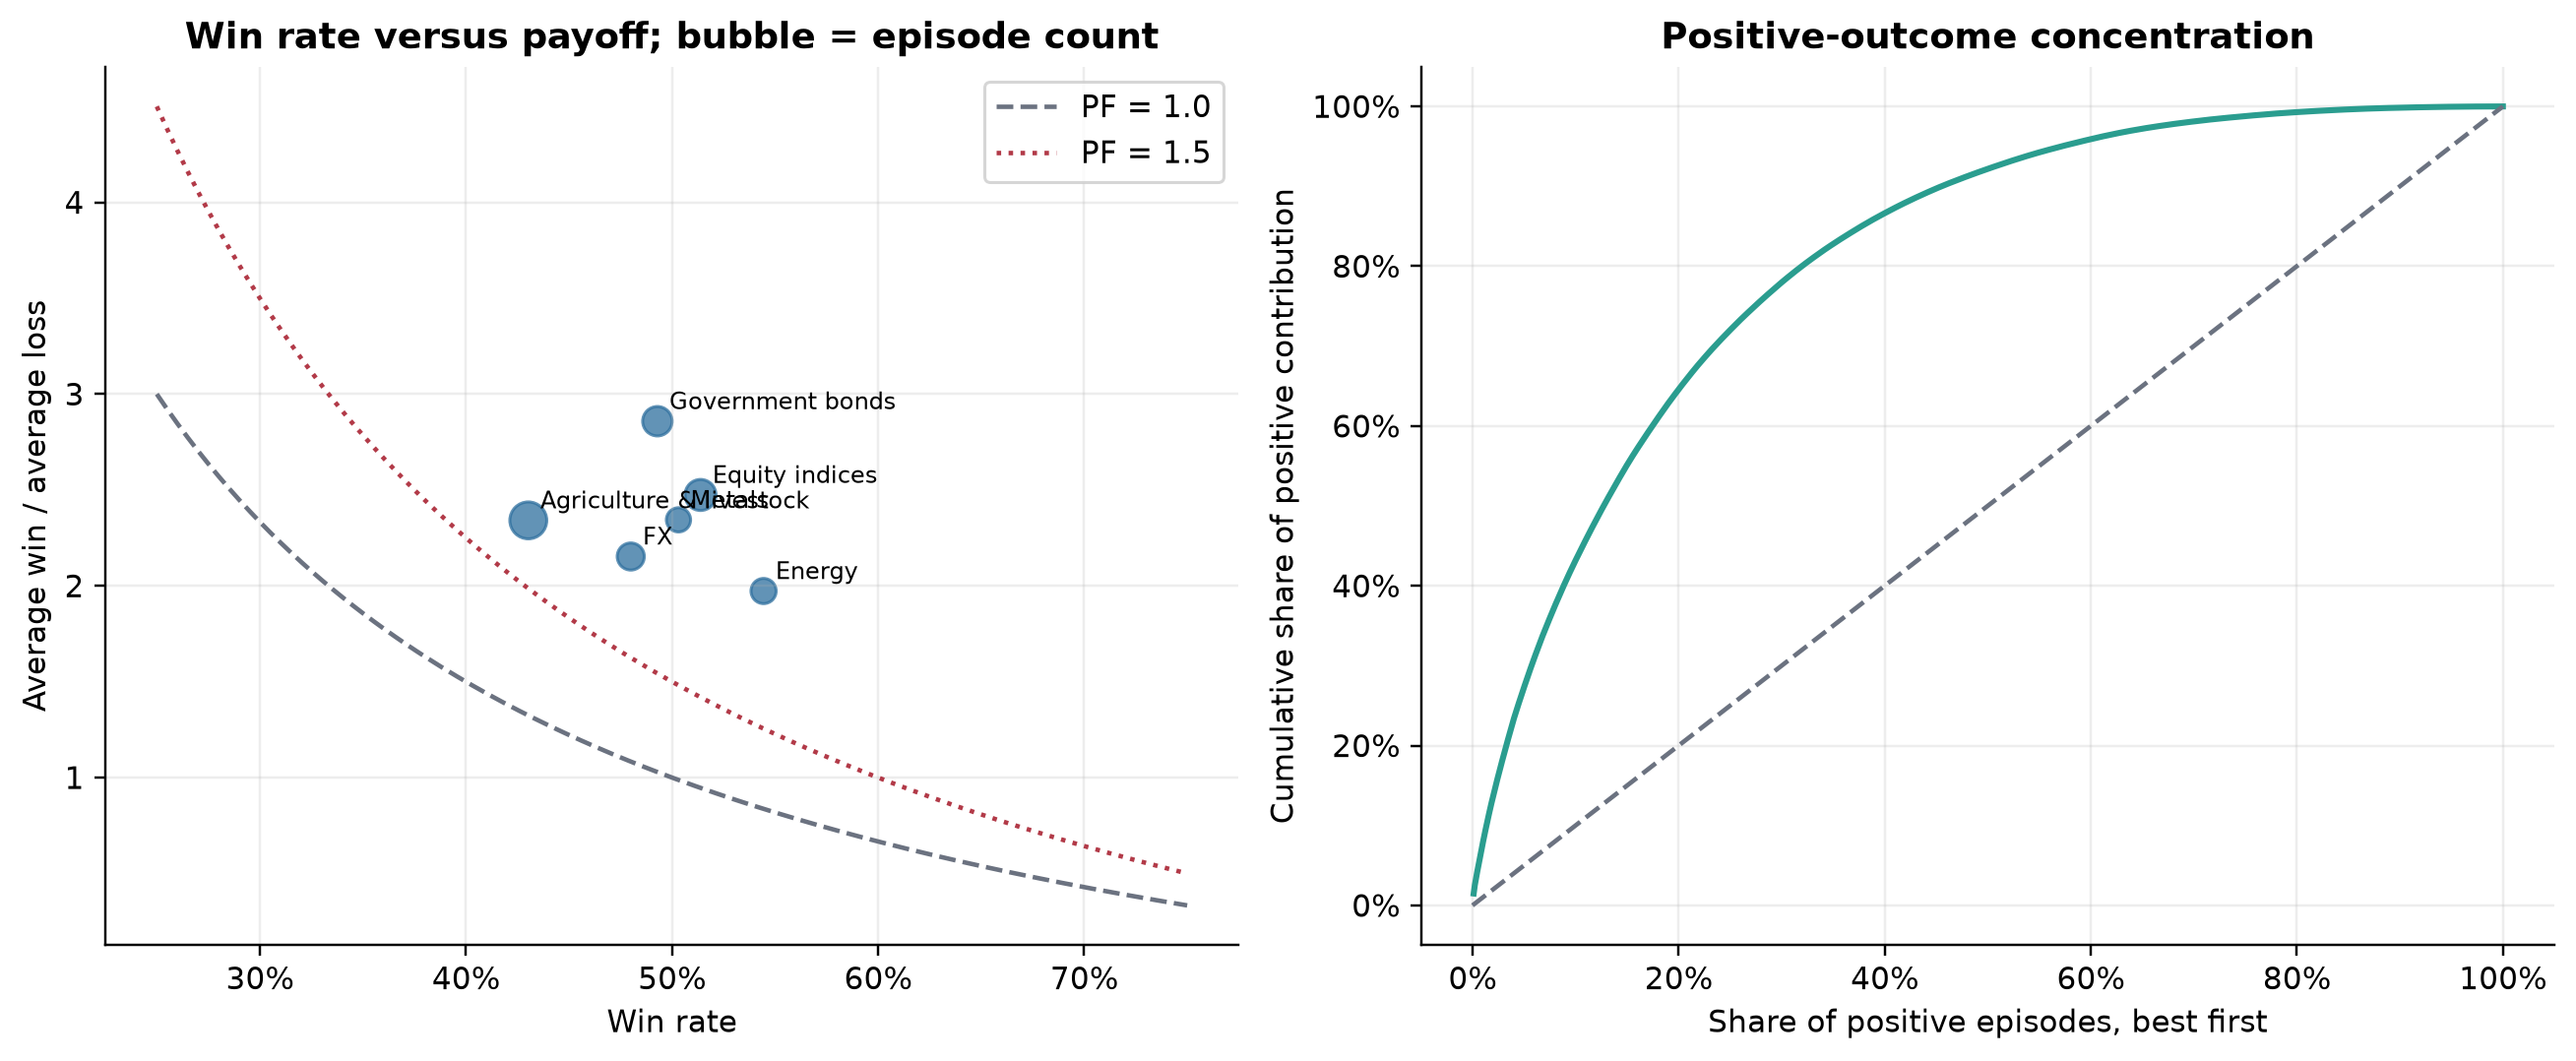

,Group,Closed episodes,Open or censored episodes,Win rate,Profit factor contribution,Profit factor USD,Expectancy bps,Payoff ratio contribution,Median outcome bps,Mean holding sessions
133,Agriculture & livestock,502,13,0.430,1.827,1.311,12.102,2.341,-3.194,151.629
134,Energy,180,5,0.544,2.411,1.573,25.193,1.973,1.979,162.322
135,Equity indices,325,14,0.514,2.680,2.610,15.720,2.474,1.351,123.603
136,FX,225,6,0.480,2.059,1.243,14.684,2.153,-0.581,150.333
137,Government bonds,282,10,0.493,2.899,3.026,21.596,2.858,0.148,155.702
138,Metals,159,4,0.503,2.496,2.448,15.644,2.344,0.664,128.119


In [11]:
full_window = trade_metrics["Window"].str.contains("full post-launch")
asset_trade = trade_metrics.loc[full_window & trade_metrics["Scope"].eq("Asset class")].copy()
p = np.linspace(0.25, 0.75, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sizes = 25 + 0.25 * asset_trade["Closed episodes"]
axes[0].scatter(asset_trade["Win rate"], asset_trade["Payoff ratio contribution"], s=sizes, color=COLORS["blue"], alpha=0.75)
for _, row in asset_trade.iterrows():
    axes[0].annotate(
        row["Group"],
        (row["Win rate"], row["Payoff ratio contribution"]),
        fontsize=8, xytext=(4, 4), textcoords="offset points",
    )
axes[0].plot(p, (1 - p) / p, color=COLORS["gray"], linestyle="--", label="PF = 1.0")
axes[0].plot(p, 1.5 * (1 - p) / p, color=COLORS["red"], linestyle=":", label="PF = 1.5")
axes[0].set_xlabel("Win rate")
axes[0].set_ylabel("Average win / average loss")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].set_title("Win rate versus payoff; bubble = episode count")
axes[0].legend()

positive = episodes.loc[episodes["Net contribution"] > 0, "Net contribution"].sort_values(ascending=False).reset_index(drop=True)
cumulative = positive.cumsum() / positive.sum()
share = (np.arange(len(cumulative)) + 1) / len(cumulative)
axes[1].plot(share, cumulative, color=COLORS["teal"], lw=2)
axes[1].plot([0, 1], [0, 1], color=COLORS["gray"], linestyle="--")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_xlabel("Share of positive episodes, best first")
axes[1].set_ylabel("Cumulative share of positive contribution")
axes[1].set_title("Positive-outcome concentration")
fig.tight_layout()
plt.show()

display(asset_trade[[
    "Group", "Closed episodes", "Open or censored episodes", "Win rate",
    "Profit factor contribution", "Profit factor USD", "Expectancy bps",
    "Payoff ratio contribution", "Median outcome bps", "Mean holding sessions",
]].round(3))


## 8. Risk, margin, capacity, and pending execution

Ordinary rebalances and inferred continuous rolls must not be combined
into one capacity conclusion. Research rebalances are sized from the
configured fraction of lagged median volume, which avoids execution-day
volume look-ahead. Realized participation is measured against actual
same-session volume and can therefore exceed the independent live
route-time gate. The roll series is an accounting proxy; some
low-volume delivery-label changes can exceed reported daily volume.
Real roll approval requires old/new serial liquidity and caps both legs
by the thinner contract.


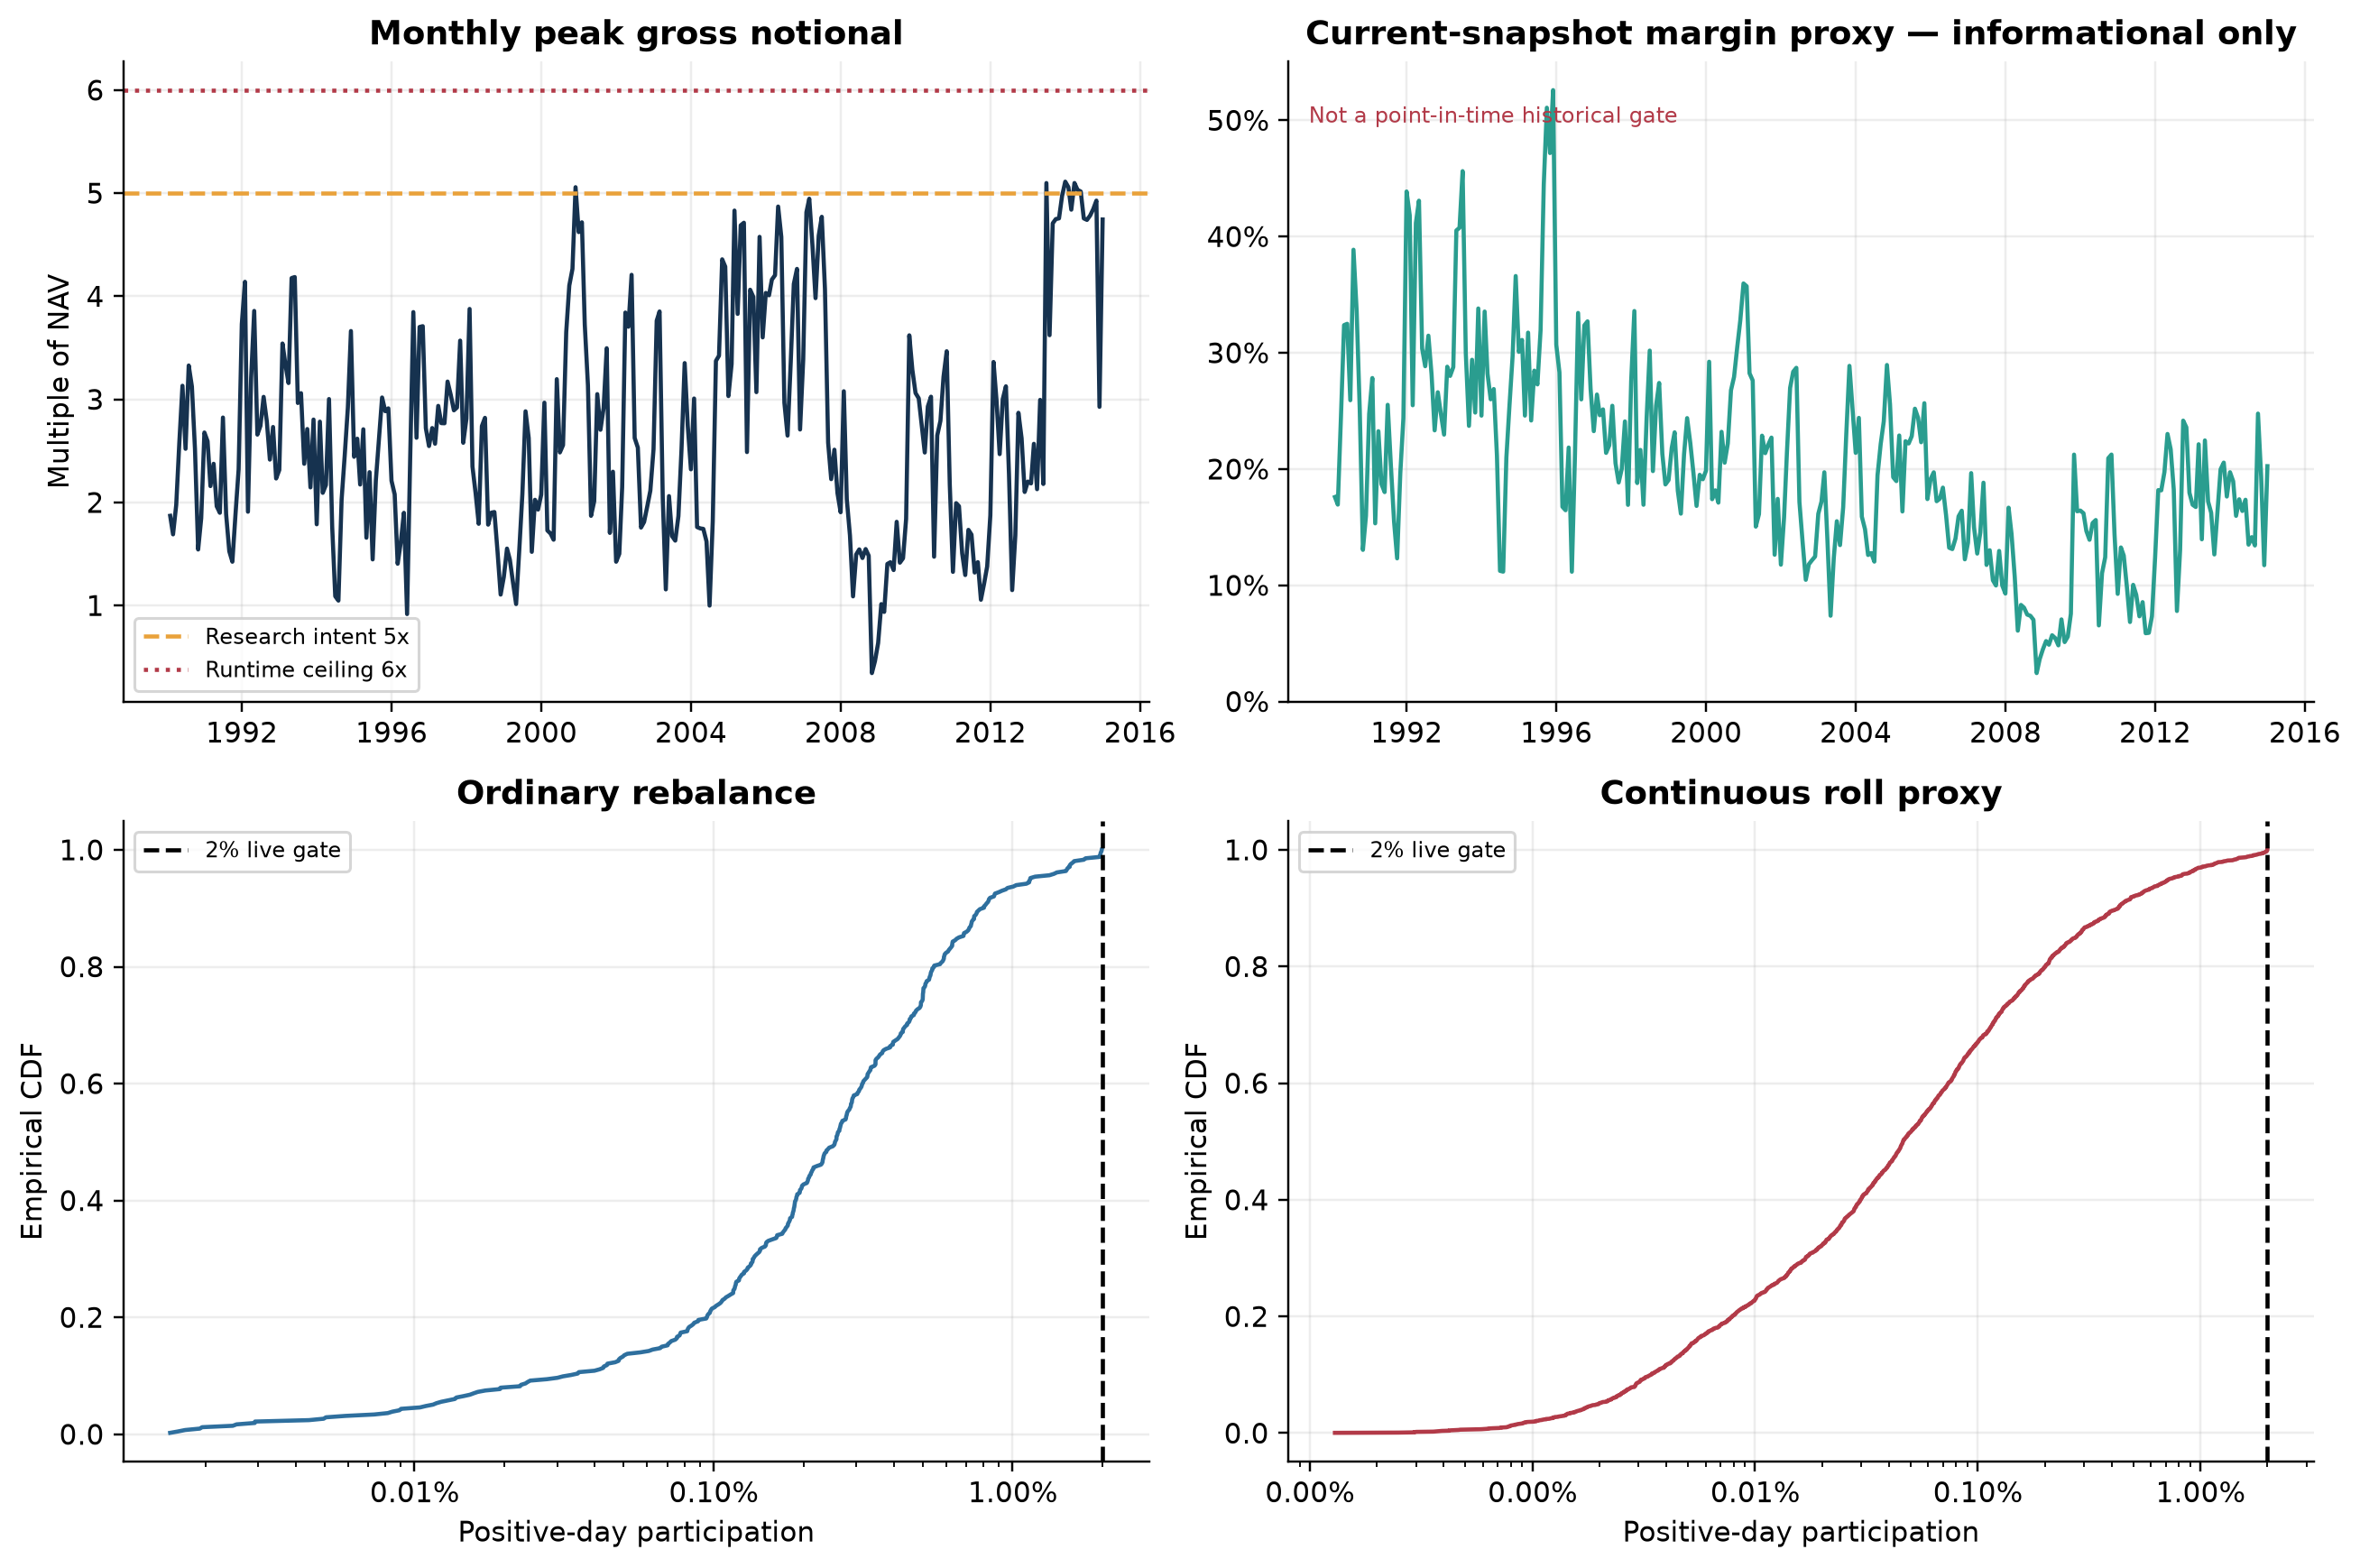

,Series,Positive days,P95,P99,Maximum,Days above 2% live gate
0,Ordinary rebalance,414,0.01145,0.01959,0.01986,0
1,Continuous roll proxy,2405,0.00725,0.01719,0.01999,0


,Control,Configured value
0,Research sizing fraction of lagged median volume,2.00%
1,Independent live route-time participation gate,2.00%


,Diagnostic,Observed
0,Peak pending markets,46
1,Portfolio-limit binding decision days,24


In [12]:
monthly_limits = live[["gross_notional_multiple", "static_margin_fraction"]].resample("ME").max()
rebalance = live.loc[live["max_rebalance_participation"] > 0, "max_rebalance_participation"]
roll = live.loc[live["max_roll_participation_proxy"] > 0, "max_roll_participation_proxy"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(monthly_limits.index, monthly_limits["gross_notional_multiple"], color=COLORS["navy"])
axes[0, 0].axhline(
    research_gross_limit,
    color=COLORS["amber"],
    linestyle="--",
    label=f"Research intent {research_gross_limit:g}x",
)
axes[0, 0].axhline(
    live_limits.max_gross_notional_multiple,
    color=COLORS["red"],
    linestyle=":",
    label=f"Runtime ceiling {live_limits.max_gross_notional_multiple:g}x",
)
axes[0, 0].set_title("Monthly peak gross notional")
axes[0, 0].set_ylabel("Multiple of NAV")
axes[0, 0].legend(fontsize=8)
axes[0, 1].plot(monthly_limits.index, monthly_limits["static_margin_fraction"], color=COLORS["teal"])
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].set_title("Current-snapshot margin proxy — informational only")
axes[0, 1].text(0.02, 0.93, "Not a point-in-time historical gate", transform=axes[0, 1].transAxes, color=COLORS["red"], fontsize=8, va="top")

for series, label, color in [(rebalance, "Ordinary rebalance", COLORS["blue"]), (roll, "Continuous roll proxy", COLORS["red"])]:
    values = np.sort(series.to_numpy())
    axes[1, 0 if label.startswith("Ordinary") else 1].plot(values, np.arange(1, len(values) + 1) / len(values), color=color)
    axis = axes[1, 0 if label.startswith("Ordinary") else 1]
    axis.axvline(
        live_limits.max_order_participation,
        color="black",
        linestyle="--",
        label=f"{live_limits.max_order_participation:.0%} live gate",
    )
    axis.set_xscale("log")
    axis.xaxis.set_major_formatter(mtick.PercentFormatter(1))
    axis.set_xlabel("Positive-day participation")
    axis.set_ylabel("Empirical CDF")
    axis.set_title(label)
    axis.legend(fontsize=8)
fig.tight_layout()
plt.show()

capacity_summary = []
for label, series in [("Ordinary rebalance", rebalance), ("Continuous roll proxy", roll)]:
    capacity_summary.append({
        "Series": label,
        "Positive days": len(series),
        "P95": series.quantile(0.95),
        "P99": series.quantile(0.99),
        "Maximum": series.max(),
        f"Days above {live_limits.max_order_participation:.0%} live gate": int(
            (series > live_limits.max_order_participation + 1e-12).sum()
        ),
    })
display(pd.DataFrame(capacity_summary).round(5))
display(pd.DataFrame({
    "Control": [
        "Research sizing fraction of lagged median volume",
        "Independent live route-time participation gate",
    ],
    "Configured value": [
        research_participation_limit,
        live_limits.max_order_participation,
    ],
}).style.format({"Configured value": "{:.2%}"}))
display(pd.DataFrame({
    "Diagnostic": ["Peak pending markets", "Portfolio-limit binding decision days"],
    "Observed": [int(full["Peak pending markets"]), int(full["Portfolio-limit binding decision days"])],
}))


## 9. Cost assumptions and friction sensitivity

The cost model charges fixed spread/slippage/fees plus square-root
impact, but it is not calibrated to timestamped quotes or fills. Every
scenario below reuses the same history. “Combined adverse” is a
sensitivity, not capacity validation, because the continuous roll
proxy still lacks serial-expiry liquidity.


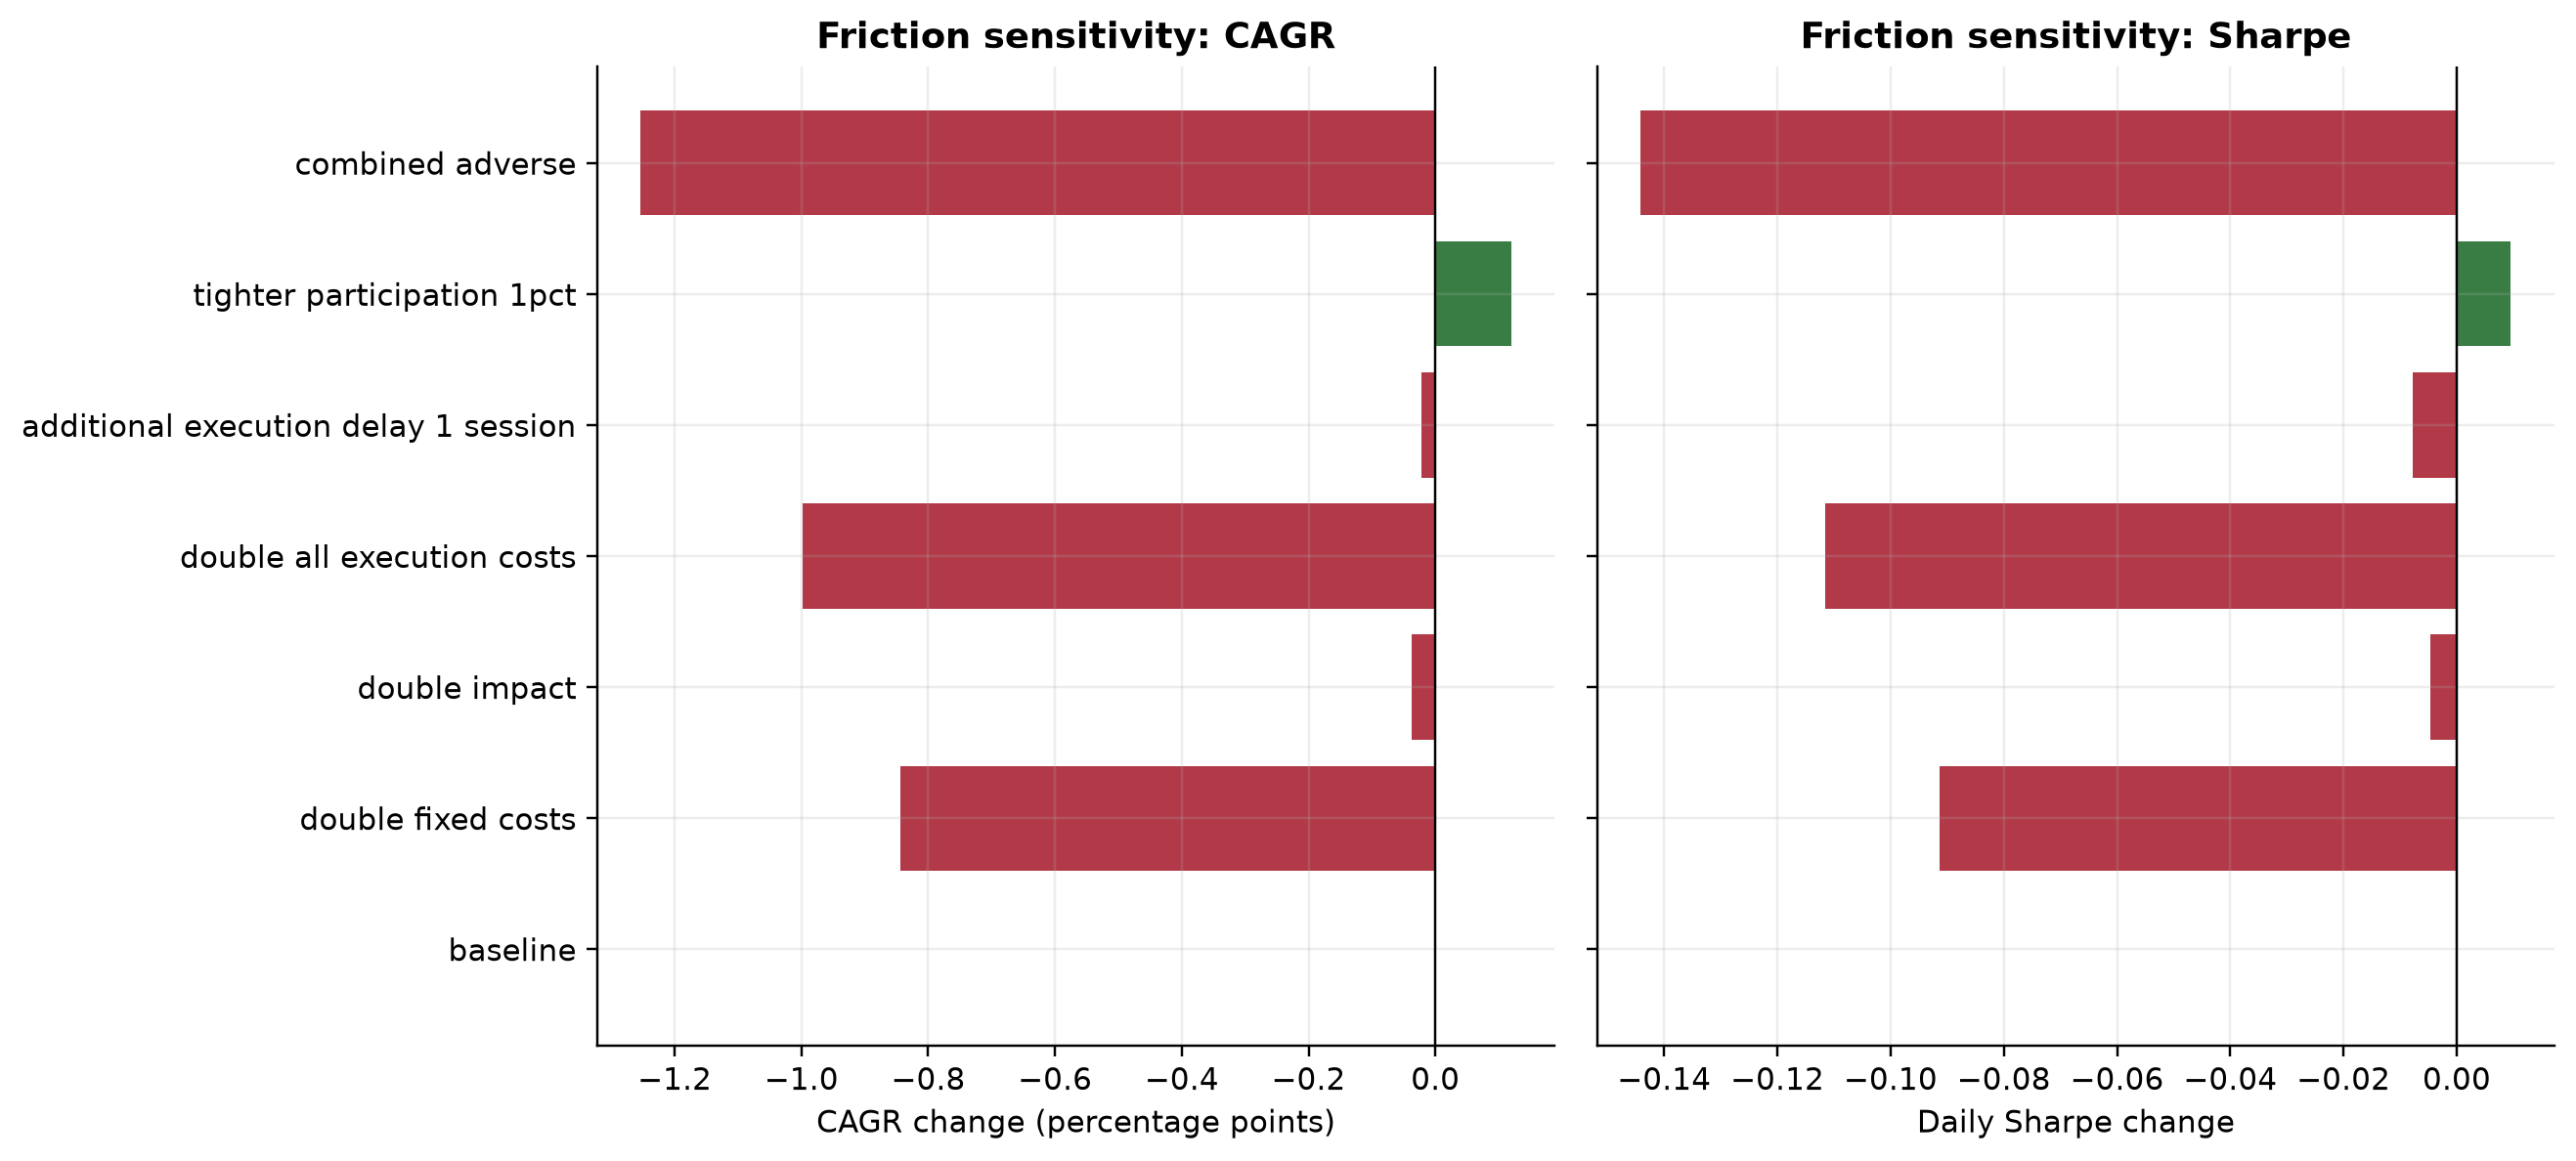

,parameter,value,category,unit,description,calibration_status
0,half_spread_ticks,0.5,fixed,ticks per contract per side,Half of the quoted bid/ask spread charged on e...,ASSUMPTION — NO QUOTE/FILL CALIBRATION
1,slippage_ticks,0.25,fixed,ticks per contract per side,Additional adverse movement charged on each ex...,ASSUMPTION — NO QUOTE/FILL CALIBRATION
2,commission_per_contract,2.5,fixed,USD per contract per side,Broker commission charged on each execution.,ASSUMPTION — NO QUOTE/FILL CALIBRATION
3,exchange_and_regulatory_fees_per_contract,1.5,fixed,USD per contract per side,Exchange and regulatory fees charged on each e...,ASSUMPTION — NO QUOTE/FILL CALIBRATION
4,impact_bps_at_full_participation,10.0,impact,bps of traded notional,Square-root market-impact coefficient at 100% ...,ASSUMPTION — NO QUOTE/FILL CALIBRATION
5,charge_roll_costs,True,rolls,boolean,Whether approximate two-leg continuous-contrac...,ASSUMPTION — NO QUOTE/FILL CALIBRATION
6,execution_timing,next_close,scheduling,execution convention,Observed price field used for delayed execution.,ASSUMPTION — NO QUOTE/FILL CALIBRATION
7,execution_delay_sessions,0,scheduling,sessions,Additional executable sessions waited after th...,ASSUMPTION — NO QUOTE/FILL CALIBRATION
8,max_rebalance_participation,0.02,capacity,fraction of session volume,Maximum fraction of observed session volume av...,ASSUMPTION — NO QUOTE/FILL CALIBRATION


,scenario,cagr,sharpe,sortino,max_drawdown,episode_profit_factor_usd,annual_cost_drag
0,baseline,0.1319,1.5895,2.4014,-0.1185,1.8499,0.0104
1,double_fixed_costs,0.1235,1.4981,2.2526,-0.1112,1.7818,0.0199
2,double_impact,0.1315,1.5849,2.3922,-0.1165,1.8325,0.0114
3,double_all_execution_costs,0.1219,1.4780,2.2201,-0.1139,1.7787,0.0207
4,additional_execution_delay_1_session,0.1317,1.5817,2.3776,-0.1084,1.8521,0.0104
5,tighter_participation_1pct,0.1331,1.5991,2.4176,-0.1208,1.8537,0.0104
6,combined_adverse,0.1194,1.4454,2.1585,-0.1176,1.7679,0.0207


In [13]:
baseline = stress.iloc[0]
stress_plot = stress.copy()
stress_plot["CAGR change (pp)"] = (stress_plot["cagr"] - baseline["cagr"]) * 100
stress_plot["Sharpe change"] = stress_plot["sharpe"] - baseline["sharpe"]
labels = stress_plot["scenario"].str.replace("_", " ")
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
axes[0].barh(labels, stress_plot["CAGR change (pp)"], color=np.where(stress_plot["CAGR change (pp)"] >= 0, COLORS["green"], COLORS["red"]))
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("CAGR change (percentage points)")
axes[0].set_title("Friction sensitivity: CAGR")
axes[1].barh(labels, stress_plot["Sharpe change"], color=np.where(stress_plot["Sharpe change"] >= 0, COLORS["green"], COLORS["red"]))
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("Daily Sharpe change")
axes[1].set_title("Friction sensitivity: Sharpe")
fig.tight_layout()
plt.show()

assumptions_display = cost_assumptions[["parameter", "value", "category", "unit", "description"]].copy()
assumptions_display["calibration_status"] = "ASSUMPTION — NO QUOTE/FILL CALIBRATION"
display(assumptions_display)
display(stress[["scenario", "cagr", "sharpe", "sortino", "max_drawdown", "episode_profit_factor_usd", "annual_cost_drag"]].round(4))


### Direct answers: friction and upside volatility

**Was friction deducted? Yes as transparent assumptions; no as live
calibration.** The ledger deducts half-spread, slippage, commission,
exchange/regulatory fees, square-root impact, and approximate two-leg
roll charges. The same-ledger gross-before-cost diagnostic below shows
the size of that deduction, but it is not a counterfactual rerun with
positions re-sized on a frictionless NAV. Representative timestamped
quotes and fills remain an external deployment gate.

**Is Sharpe inflated by upside volatility? No.** Sharpe's denominator
includes both upside and downside volatility, so positive variation is
penalized. Sortino is reported because it isolates downside deviation.
Its higher value is consistent with downside deviation being below
total volatility; it is supplementary and does not establish a >2
Sharpe result.


In [14]:
gross = live["gross_return"].dropna()
net = live["net_return"].dropna()
years = float(full["Years"])

def compact_return_stats(series):
    wealth = (1 + series).cumprod()
    running_peak = np.maximum.accumulate(np.r_[1.0, wealth.to_numpy()])[1:]
    downside_rms = math.sqrt(float(np.mean(np.minimum(series.to_numpy(), 0.0) ** 2)))
    return {
        "CAGR": wealth.iloc[-1] ** (1 / years) - 1,
        "Daily Sharpe (rf=0)": series.mean() / series.std() * math.sqrt(252),
        "Sortino (rf=0)": series.mean() * 252 / (downside_rms * math.sqrt(252)),
        "Maximum drawdown": float((wealth.to_numpy() / running_peak - 1).min()),
    }

gross_stats = compact_return_stats(gross)
net_stats = compact_return_stats(net)
gross_net = pd.DataFrame({
    "Metric": ["CAGR", "Daily Sharpe (rf=0)", "Sortino (rf=0)", "Maximum drawdown"],
    "Same-ledger gross before modeled costs": [
        f"{gross_stats['CAGR']:.2%}", f"{gross_stats['Daily Sharpe (rf=0)']:.3f}",
        f"{gross_stats['Sortino (rf=0)']:.3f}", f"{gross_stats['Maximum drawdown']:.2%}",
    ],
    "Net after modeled costs": [
        f"{net_stats['CAGR']:.2%}", f"{net_stats['Daily Sharpe (rf=0)']:.3f}",
        f"{net_stats['Sortino (rf=0)']:.3f}", f"{net_stats['Maximum drawdown']:.2%}",
    ],
})
display(gross_net)

risk_shape = pd.DataFrame({
    "Diagnostic": [
        "Annualized total volatility", "Annualized downside deviation",
        "Daily skew", "Best day", "Worst day",
    ],
    "Observed": [
        f"{full['Annualized volatility']:.2%}",
        f"{full['Annualized downside deviation']:.2%}",
        f"{full['Daily return skew']:.3f}",
        f"{full['Best day']:.2%}",
        f"{full['Worst day']:.2%}",
    ],
    "Interpretation": [
        "Sharpe denominator", "Sortino denominator", "Slight negative asymmetry",
        "No dominant positive-spike pattern", "Larger magnitude than best day",
    ],
})
display(risk_shape)


,Metric,Same-ledger gross before modeled costs,Net after modeled costs
0,CAGR,14.42%,13.19%
1,Daily Sharpe (rf=0),1.725,1.590
2,Sortino (rf=0),2.625,2.401
3,Maximum drawdown,-11.63%,-11.85%


,Diagnostic,Observed,Interpretation
0,Annualized total volatility,7.72%,Sharpe denominator
1,Annualized downside deviation,5.11%,Sortino denominator
2,Daily skew,0.005,Slight negative asymmetry
3,Best day,4.34%,No dominant positive-spike pattern
4,Worst day,-2.53%,Larger magnitude than best day


## 10. Diversification and lagged regime diagnostics

Asset-class contributions are additive daily ledger contributions.
Correlations describe historical co-movement; they do not guarantee
diversification in a future crisis. Regime thresholds use only prior
months, but the conditional outcomes remain associative,
multiple-comparison-unadjusted, and selection-unadjusted.


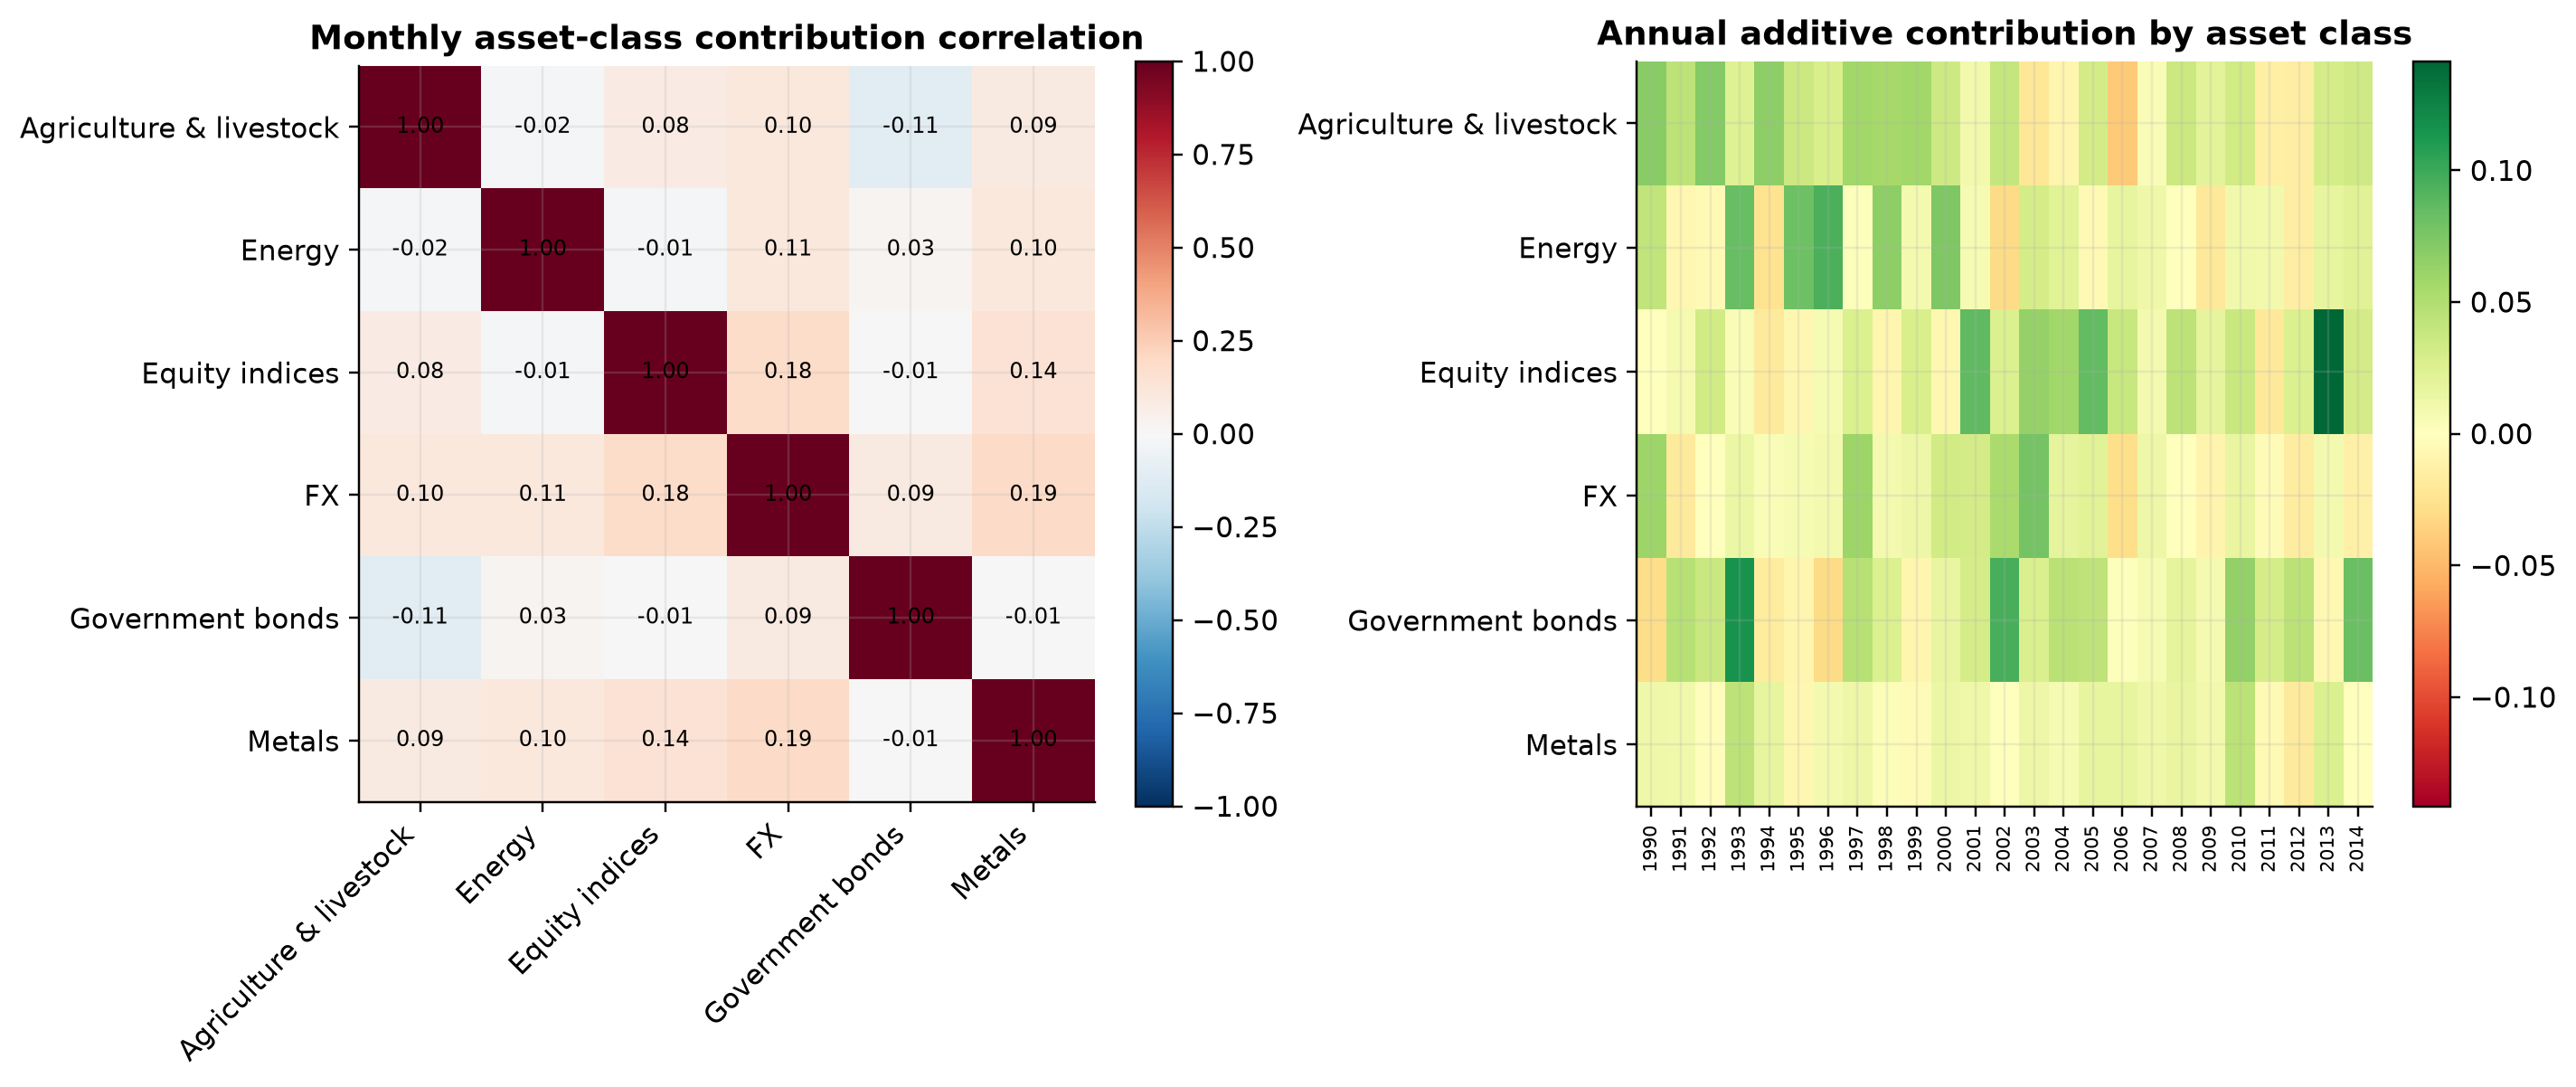

In [15]:
class_monthly = (
    market.groupby([pd.Grouper(key="date", freq="ME"), "asset_class"])["net_return_contribution"]
    .sum().unstack(fill_value=0)
)
correlation = class_monthly.corr()
class_yearly = class_monthly.groupby(class_monthly.index.year).sum().T
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
image = axes[0].imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(correlation)), correlation.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(correlation)), correlation.index)
axes[0].set_title("Monthly asset-class contribution correlation")
for i in range(len(correlation)):
    for j in range(len(correlation)):
        axes[0].text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axes[0], fraction=0.046)

scale = np.nanmax(np.abs(class_yearly.to_numpy()))
image2 = axes[1].imshow(class_yearly, aspect="auto", cmap="RdYlGn", vmin=-scale, vmax=scale)
axes[1].set_xticks(range(len(class_yearly.columns)), class_yearly.columns, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(class_yearly)), class_yearly.index)
axes[1].set_title("Annual additive contribution by asset class")
fig.colorbar(image2, ax=axes[1], fraction=0.046)
fig.tight_layout()
plt.show()


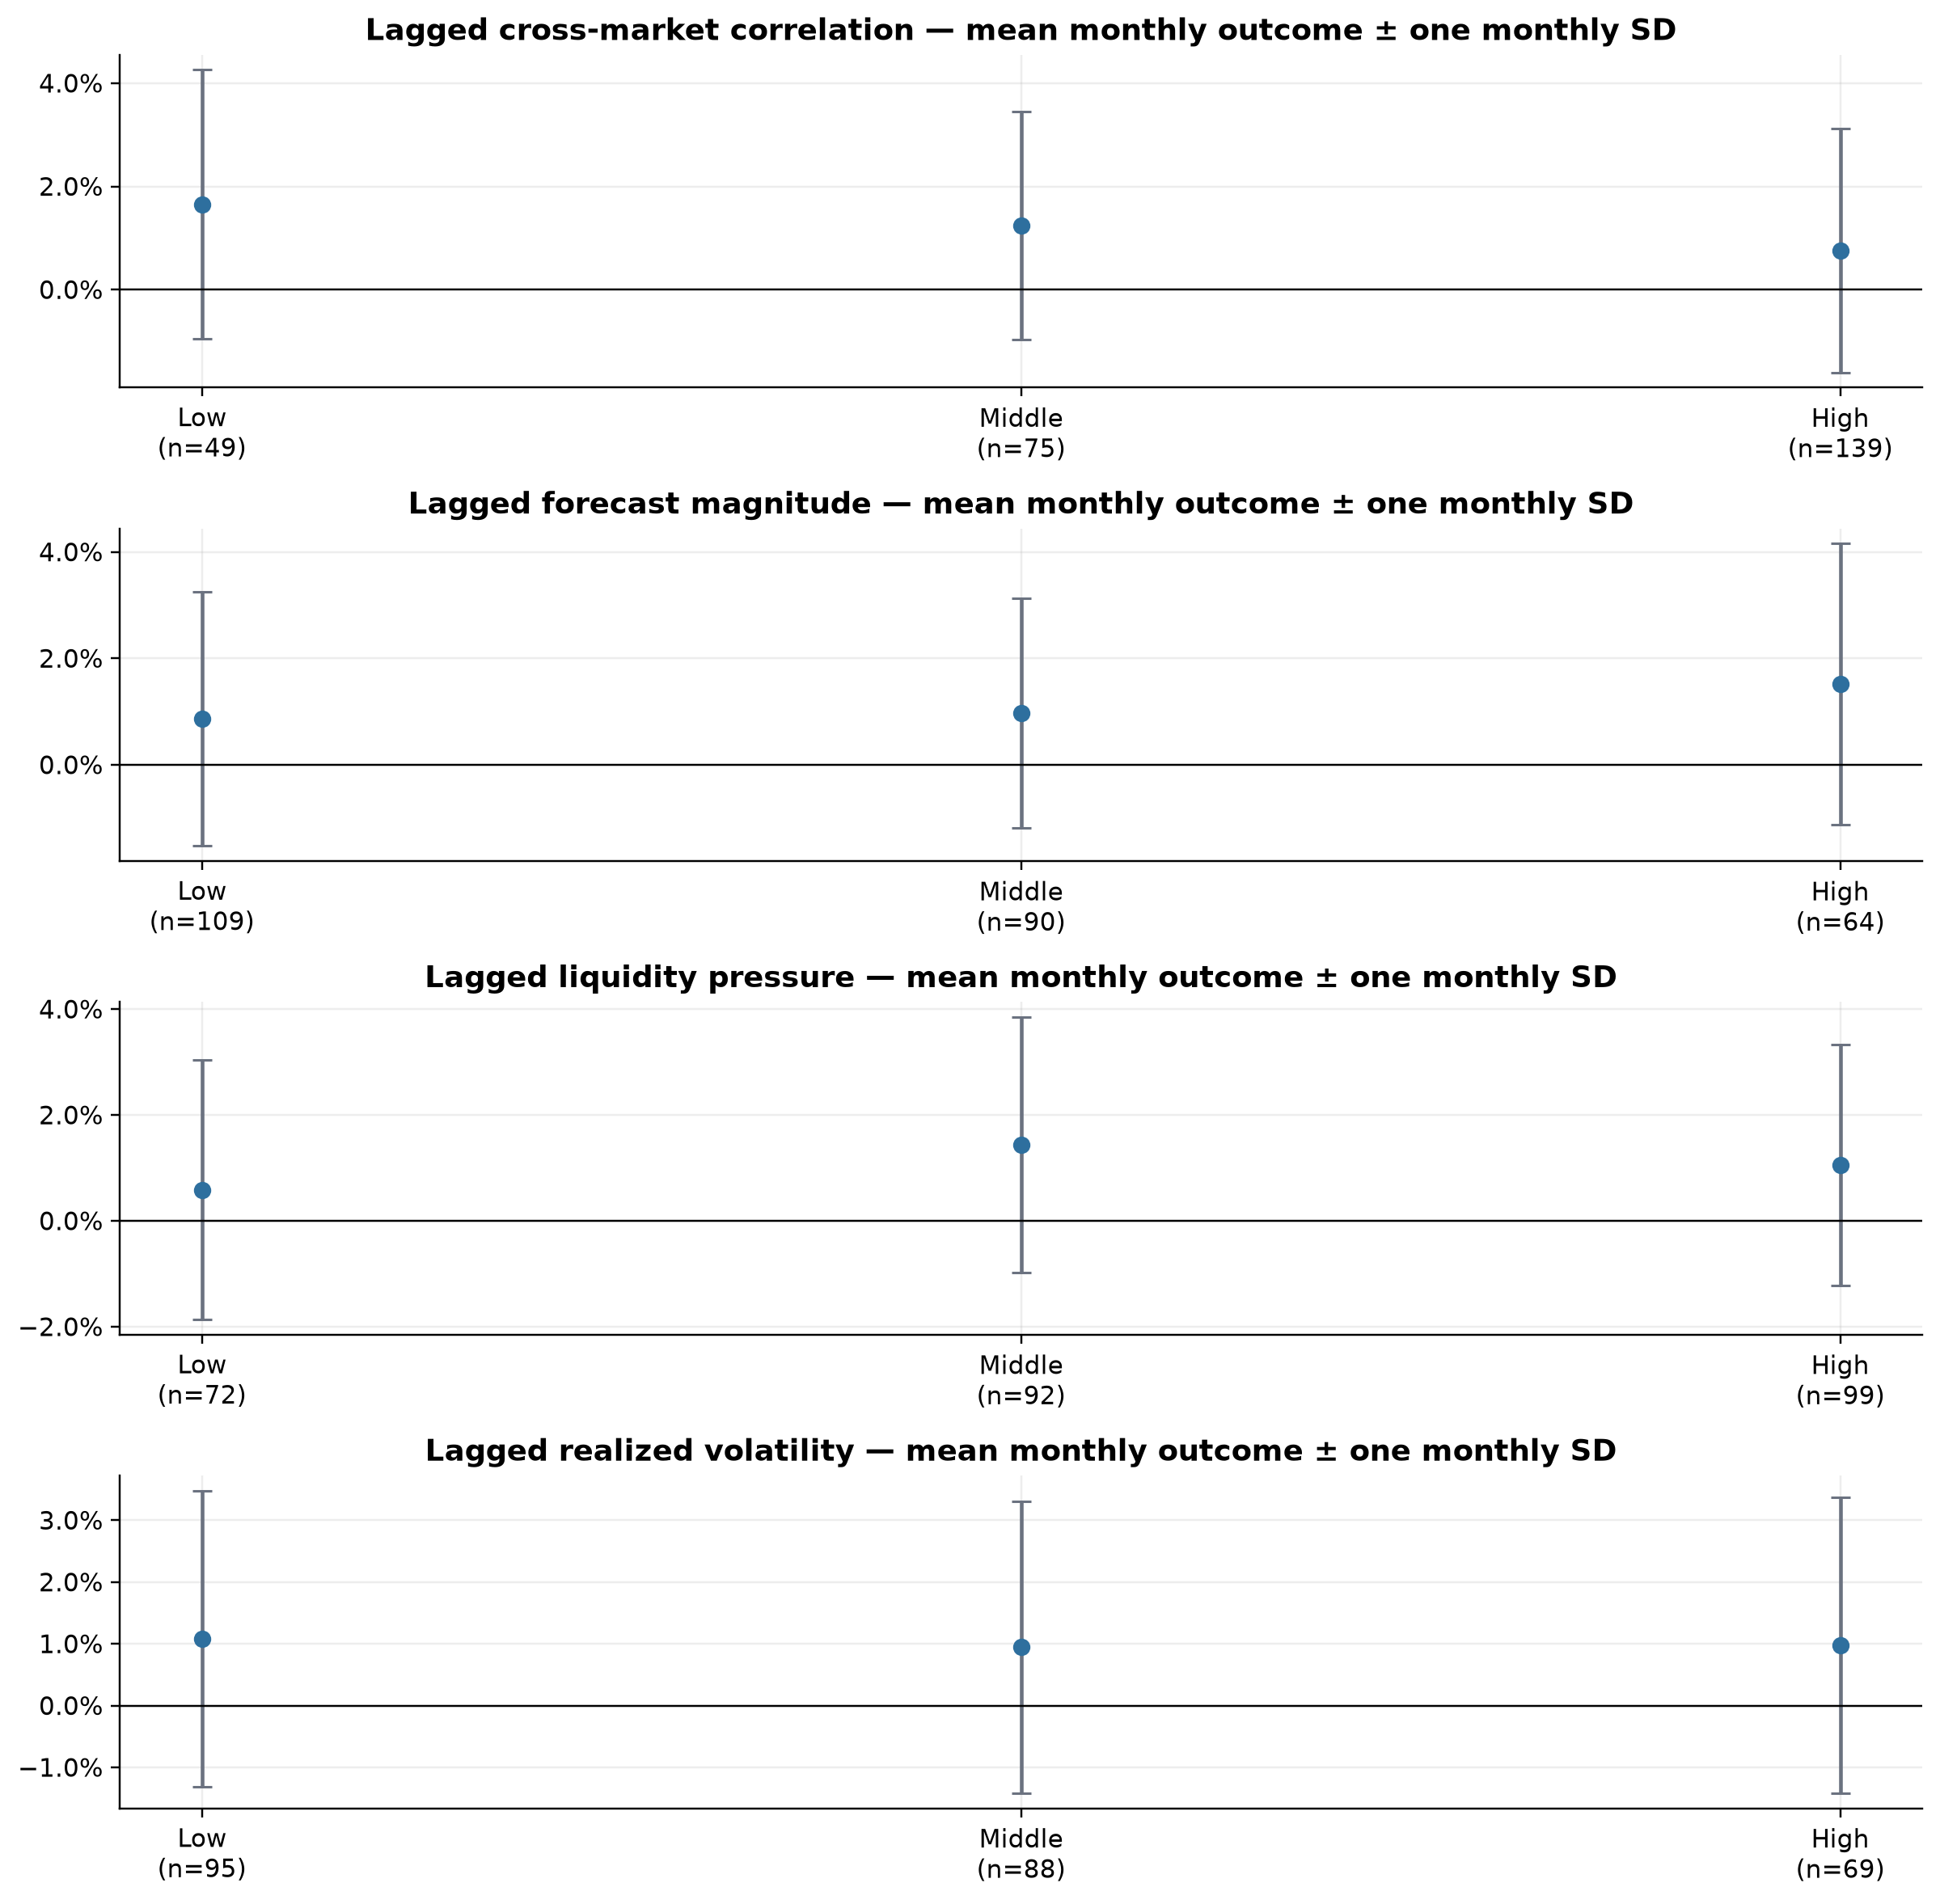

,Regime,State,Months,Mean monthly return,Positive month rate,Worst month,Threshold method
0,Lagged realized volatility,Low,95,0.0108,0.6947,-0.0500,lagged expanding terciles
1,Lagged realized volatility,Middle,88,0.0095,0.6591,-0.0371,lagged expanding terciles
2,Lagged realized volatility,High,69,0.0097,0.7101,-0.0591,lagged expanding terciles
3,Lagged forecast magnitude,Low,109,0.0086,0.6606,-0.0500,lagged expanding terciles
4,Lagged forecast magnitude,Middle,90,0.0097,0.6889,-0.0336,lagged expanding terciles
5,Lagged forecast magnitude,High,64,0.0151,0.7656,-0.0591,lagged expanding terciles
6,Lagged liquidity pressure,Low,72,0.0058,0.5833,-0.0368,lagged expanding terciles
7,Lagged liquidity pressure,Middle,92,0.0144,0.7500,-0.0500,lagged expanding terciles
8,Lagged liquidity pressure,High,99,0.0105,0.7273,-0.0591,lagged expanding terciles
9,Lagged cross-market correlation,Low,49,0.0165,0.7755,-0.0500,lagged expanding terciles


In [16]:
state_order = {"Low": 0, "Middle": 1, "High": 2}
regime_plot = regimes.assign(order=regimes["State"].map(state_order).fillna(99)).sort_values(["Regime", "order"])
regime_names = regime_plot["Regime"].drop_duplicates().tolist()
fig, axes = plt.subplots(len(regime_names), 1, figsize=(11, 2.7 * len(regime_names)), squeeze=False)
for axis, name in zip(axes[:, 0], regime_names):
    group = regime_plot.loc[regime_plot["Regime"].eq(name)]
    x = np.arange(len(group))
    axis.errorbar(x, group["Mean monthly return"], yerr=group["Monthly volatility"], fmt="o", color=COLORS["blue"], ecolor=COLORS["gray"], capsize=4)
    axis.axhline(0, color="black", lw=0.8)
    axis.set_xticks(x, [f"{state}\n(n={months})" for state, months in zip(group["State"], group["Months"], strict=True)])
    axis.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    axis.set_title(name + " — mean monthly outcome ± one monthly SD")
fig.tight_layout()
plt.show()
display(regimes[["Regime", "State", "Months", "Mean monthly return", "Positive month rate", "Worst month", "Threshold method"]].round(4))


## 11. Daily drawdown and monthly return bootstrap uncertainty

The primary drawdown diagnostic resamples **daily net returns** using
the block lengths, horizons, path counts, and seeds recorded in the
generated artifact. Drawdown includes initial capital and is measured
at daily close, so an intramonth loss recovered before month-end is
retained.
Monthly bootstrap remains useful for CAGR and Sharpe ranges, but its
drawdown output is explicitly informational because month-end sampling
can hide intramonth losses.

These simulations are **not selection-adjusted**. The notebook reports
their generated sample counts rather than assuming a fixed count. A
zero simulated tail count is not proof that the event is impossible.
Monte Carlo measures path uncertainty; rearranging the same
observations cannot increase expected alpha or establish risk of ruin
under unseen regimes.

This implements the stationary-bootstrap idea of
[Politis and Romano](https://statistics.stanford.edu/technical-reports/stationary-bootstrap),
but only on the one realized portfolio-return series. It does not
replay market data, signals, contracts, margins, liquidity, or fills.
Because the complete historical trial count is unknown, the
[deflated-Sharpe framework](https://www.davidhbailey.com/dhbpapers/deflated-sharpe.pdf)
cannot be applied honestly; no selection-adjusted probability is
reported.


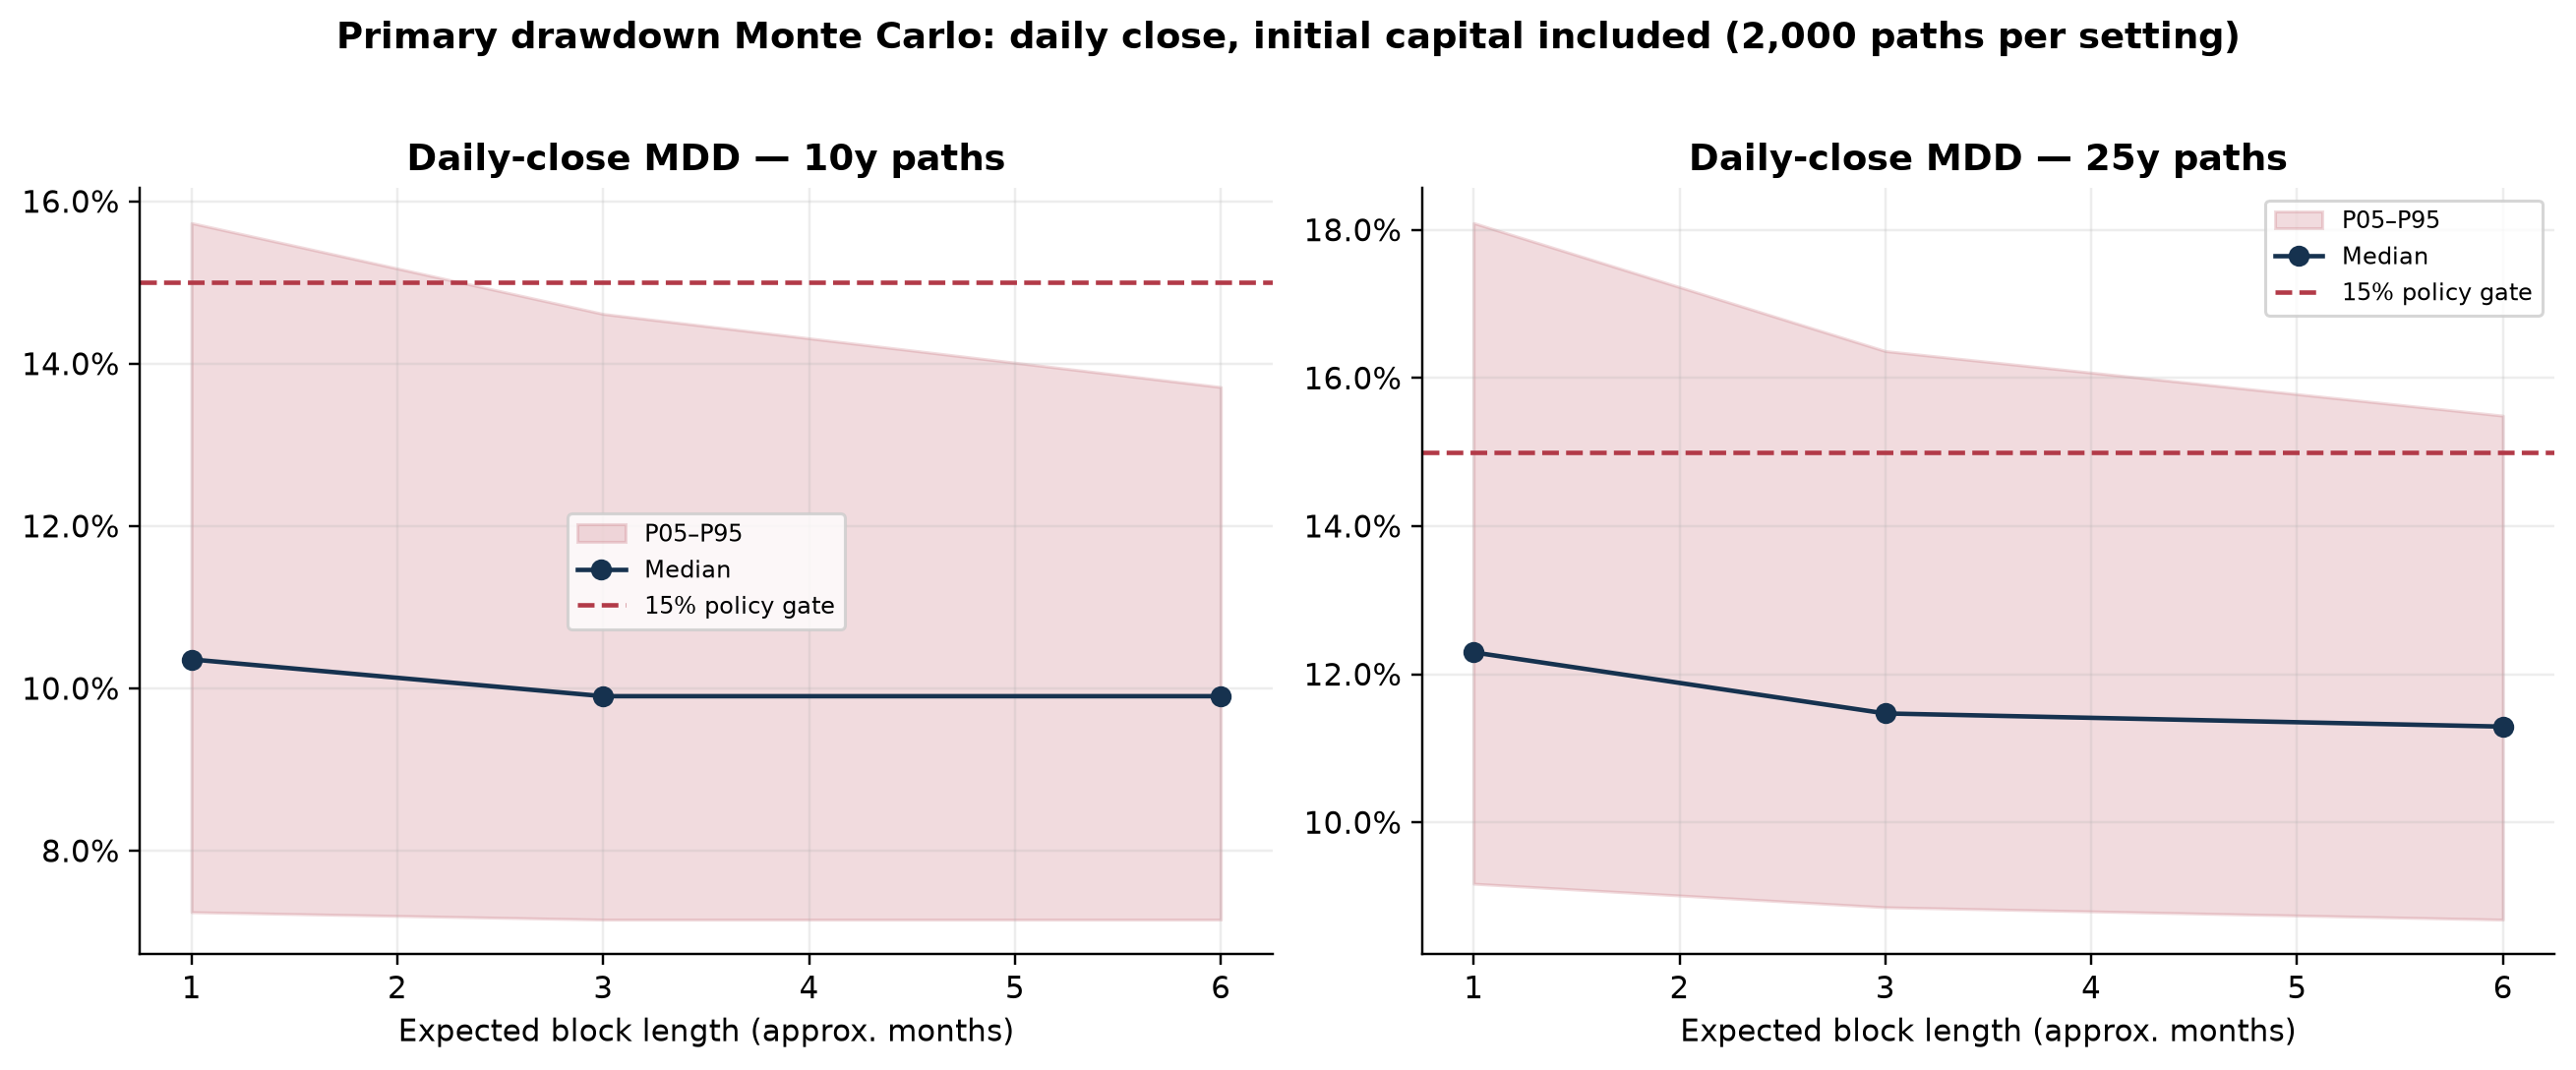

,Expected block sessions,Horizon sessions,Samples,Seed,Metric,Value,Drawdown resolution,Selection adjusted
43,21,2520,2000,20260803,Probability capital falls below 50% of initial...,0.0000,daily close; includes initial capital,False
44,21,2520,2000,20260803,Probability maximum drawdown exceeds 15%,0.0680,daily close; includes initial capital,False
45,21,2520,2000,20260803,Probability maximum drawdown exceeds 20%,0.0080,daily close; includes initial capital,False
46,21,2520,2000,20260803,Probability maximum drawdown exceeds 30%,0.0000,daily close; includes initial capital,False
47,21,2520,2000,20260803,Probability maximum drawdown exceeds 40%,0.0000,daily close; includes initial capital,False
55,21,6300,2000,20260803,Probability capital falls below 50% of initial...,0.0000,daily close; includes initial capital,False
56,21,6300,2000,20260803,Probability maximum drawdown exceeds 15%,0.1855,daily close; includes initial capital,False
57,21,6300,2000,20260803,Probability maximum drawdown exceeds 20%,0.0200,daily close; includes initial capital,False
58,21,6300,2000,20260803,Probability maximum drawdown exceeds 30%,0.0000,daily close; includes initial capital,False
59,21,6300,2000,20260803,Probability maximum drawdown exceeds 40%,0.0000,daily close; includes initial capital,False


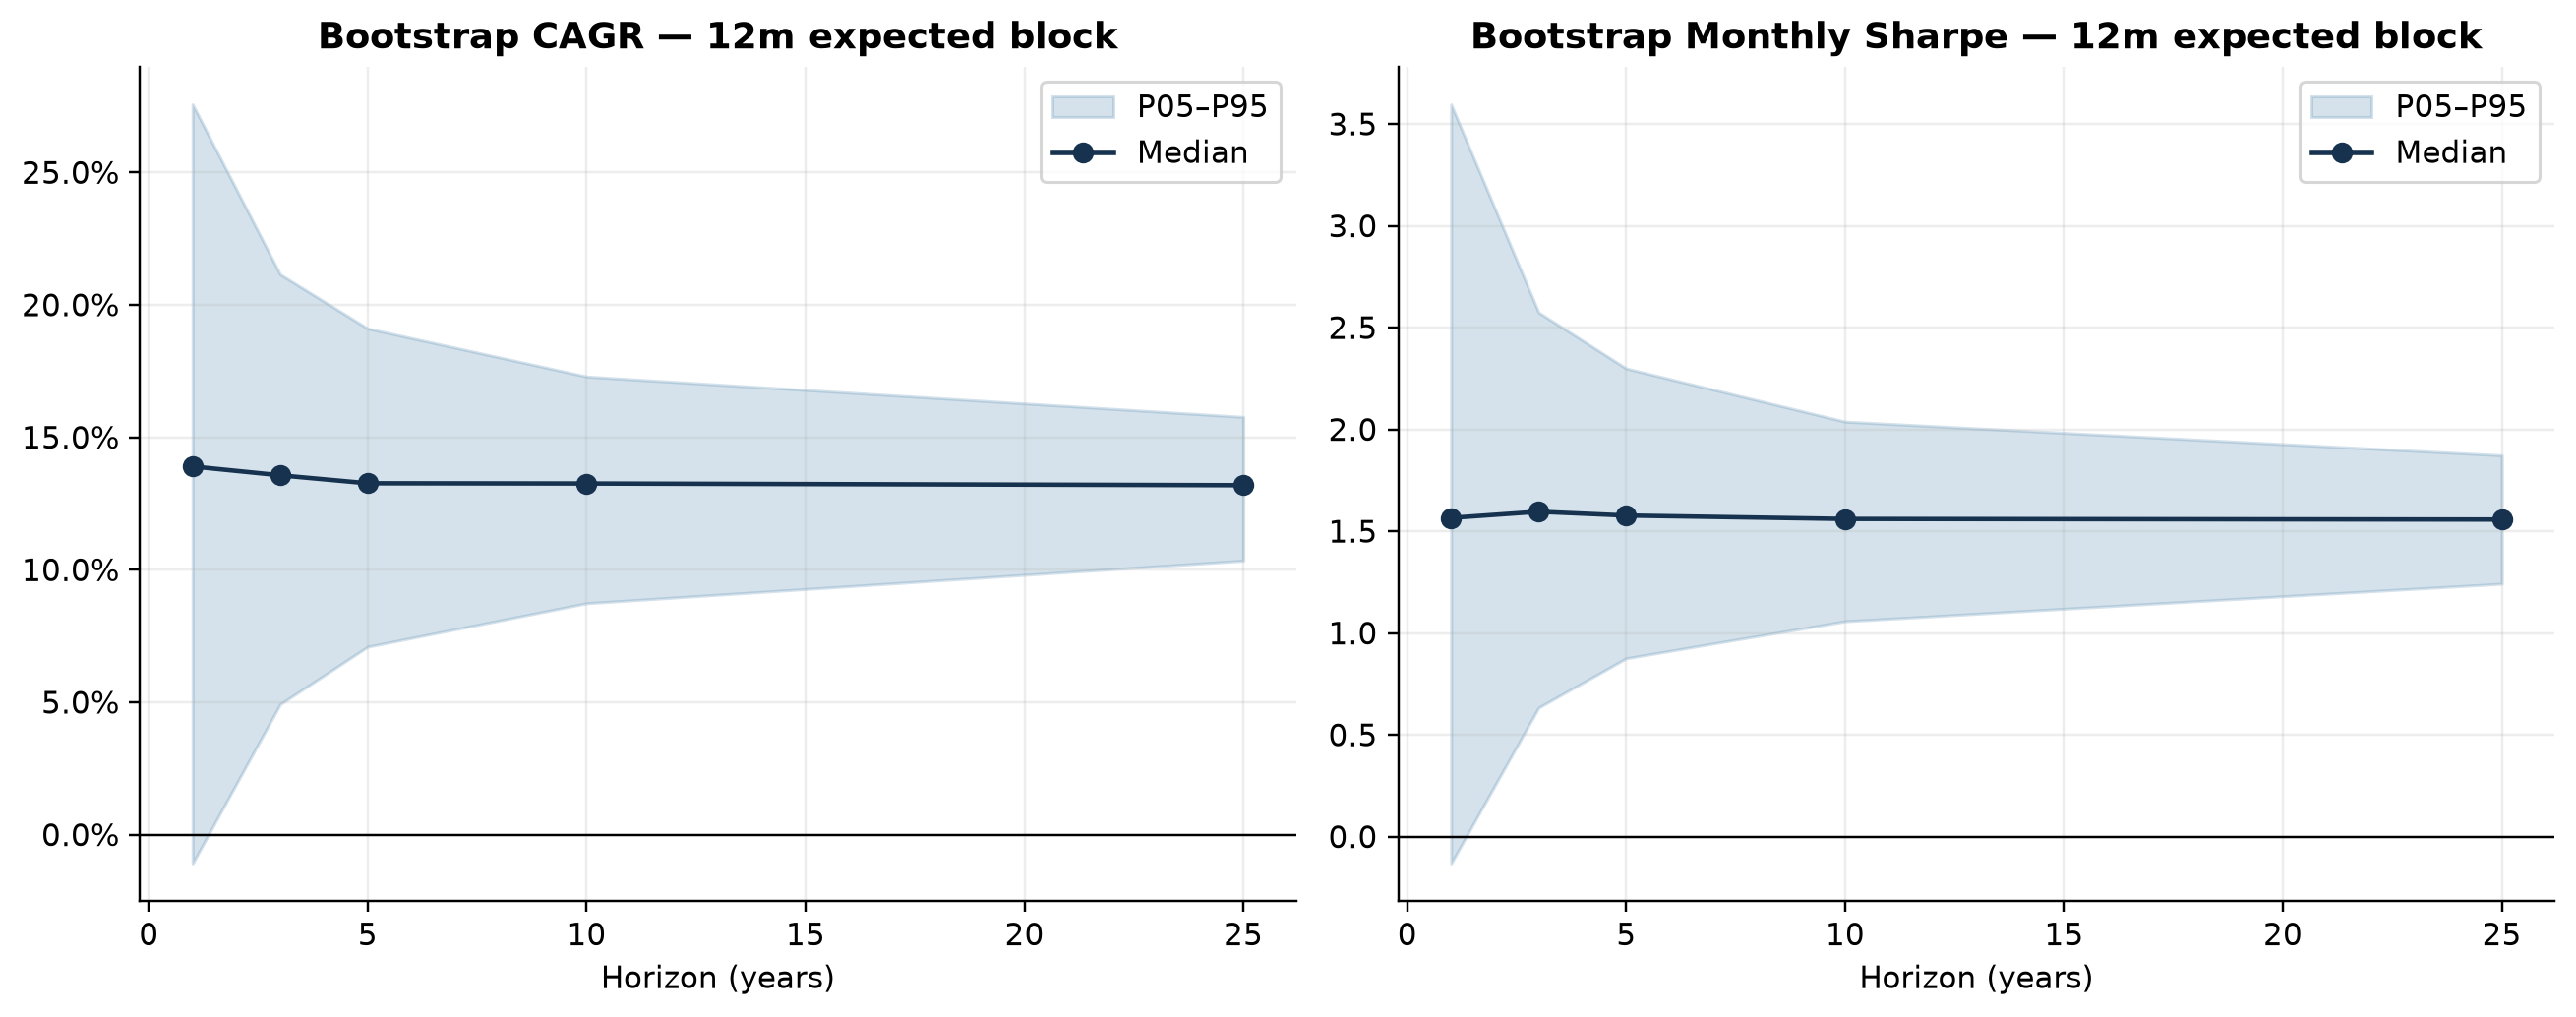

,Expected block months,Horizon months,Samples,Seed,Metric,Statistic,Value,Drawdown resolution,Selection adjusted
579,12,12,2000,20260803,CAGR,P05,-0.0109,month-end only; informational; may understate ...,False
581,12,12,2000,20260803,CAGR,Median,0.1390,month-end only; informational; may understate ...,False
583,12,12,2000,20260803,CAGR,P95,0.2757,month-end only; informational; may understate ...,False
586,12,12,2000,20260803,Monthly Sharpe,P05,-0.1318,month-end only; informational; may understate ...,False
588,12,12,2000,20260803,Monthly Sharpe,Median,1.5654,month-end only; informational; may understate ...,False
590,12,12,2000,20260803,Monthly Sharpe,P95,3.5961,month-end only; informational; may understate ...,False
613,12,36,2000,20260803,CAGR,P05,0.0492,month-end only; informational; may understate ...,False
615,12,36,2000,20260803,CAGR,Median,0.1357,month-end only; informational; may understate ...,False
617,12,36,2000,20260803,CAGR,P95,0.2115,month-end only; informational; may understate ...,False
620,12,36,2000,20260803,Monthly Sharpe,P05,0.6336,month-end only; informational; may understate ...,False


In [17]:
full_daily_dd = daily_drawdown_bootstrap.loc[
    daily_drawdown_bootstrap["Window"].str.contains("full post-launch")
    & daily_drawdown_bootstrap["Metric"].eq("Maximum drawdown")
    & daily_drawdown_bootstrap["Statistic"].isin(["P05", "Median", "P95"])
].copy()
daily_sample_counts = sorted(full_daily_dd["Samples"].unique())
daily_sample_label = ", ".join(f"{int(value):,}" for value in daily_sample_counts)
horizons = sorted(full_daily_dd["Horizon sessions"].unique())
fig, axes = plt.subplots(1, len(horizons), figsize=(12, 4.8), squeeze=False)
for axis, horizon in zip(axes[0], horizons):
    subset = full_daily_dd.loc[full_daily_dd["Horizon sessions"].eq(horizon)]
    pivot = subset.pivot(index="Expected block sessions", columns="Statistic", values="Value").sort_index()
    x = pivot.index / 21
    axis.fill_between(x, -pivot["P95"], -pivot["P05"], color=COLORS["red"], alpha=0.18, label="P05–P95")
    axis.plot(x, -pivot["Median"], marker="o", color=COLORS["navy"], label="Median")
    axis.axhline(
        live_limits.max_drawdown_fraction,
        color=COLORS["red"],
        linestyle="--",
        label=f"{live_limits.max_drawdown_fraction:.0%} policy gate",
    )
    axis.set_xlabel("Expected block length (approx. months)")
    axis.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    axis.set_title(f"Daily-close MDD — {horizon / 252:.0f}y paths")
    axis.legend(fontsize=8)
fig.suptitle(
    "Primary drawdown Monte Carlo: daily close, initial capital included "
    f"({daily_sample_label} paths per setting)",
    y=1.02,
    weight="bold",
)
fig.tight_layout()
plt.show()

daily_probabilities = daily_drawdown_bootstrap.loc[
    daily_drawdown_bootstrap["Window"].str.contains("full post-launch")
    & daily_drawdown_bootstrap["Metric"].str.startswith("Probability")
    & daily_drawdown_bootstrap["Statistic"].eq("Probability")
]
display(daily_probabilities[[
    "Expected block sessions", "Horizon sessions", "Samples", "Seed",
    "Metric", "Value",
    "Drawdown resolution", "Selection adjusted",
]].round(4))

full_boot = bootstrap.loc[
    bootstrap["Window"].str.contains("full post-launch")
    & bootstrap["Expected block months"].eq(12)
    & bootstrap["Metric"].isin(["CAGR", "Monthly Sharpe"])
    & bootstrap["Statistic"].isin(["P05", "Median", "P95"])
].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for axis, metric_name in zip(axes, ["CAGR", "Monthly Sharpe"]):
    subset = full_boot.loc[full_boot["Metric"].eq(metric_name)]
    pivot = subset.pivot(index="Horizon months", columns="Statistic", values="Value").sort_index()
    years = pivot.index / 12
    axis.fill_between(years, pivot["P05"], pivot["P95"], color=COLORS["blue"], alpha=0.20, label="P05–P95")
    axis.plot(years, pivot["Median"], marker="o", color=COLORS["navy"], label="Median")
    axis.axhline(0, color="black", lw=0.8)
    axis.set_xlabel("Horizon (years)")
    axis.set_title(f"Bootstrap {metric_name} — 12m expected block")
    axis.legend()
    if metric_name == "CAGR":
        axis.yaxis.set_major_formatter(mtick.PercentFormatter(1))
fig.tight_layout()
plt.show()

display(full_boot[[
    "Expected block months", "Horizon months", "Samples", "Seed",
    "Metric", "Statistic", "Value", "Drawdown resolution",
    "Selection adjusted",
]].round(4))


### Supplementary trade-sequence sensitivity

This adds the familiar “shuffle the trades” view both without and with
replacement. It uses additive episode contributions because these are
overlapping slices of one portfolio—not independent whole-account
trades. The capital-floor statistic is therefore an empirical
**risk-of-ruin proxy**, not insolvency probability. It excludes margin
calls, forced liquidation, rejected orders, gaps, and unseen regimes,
and it cannot clear a deployment gate.


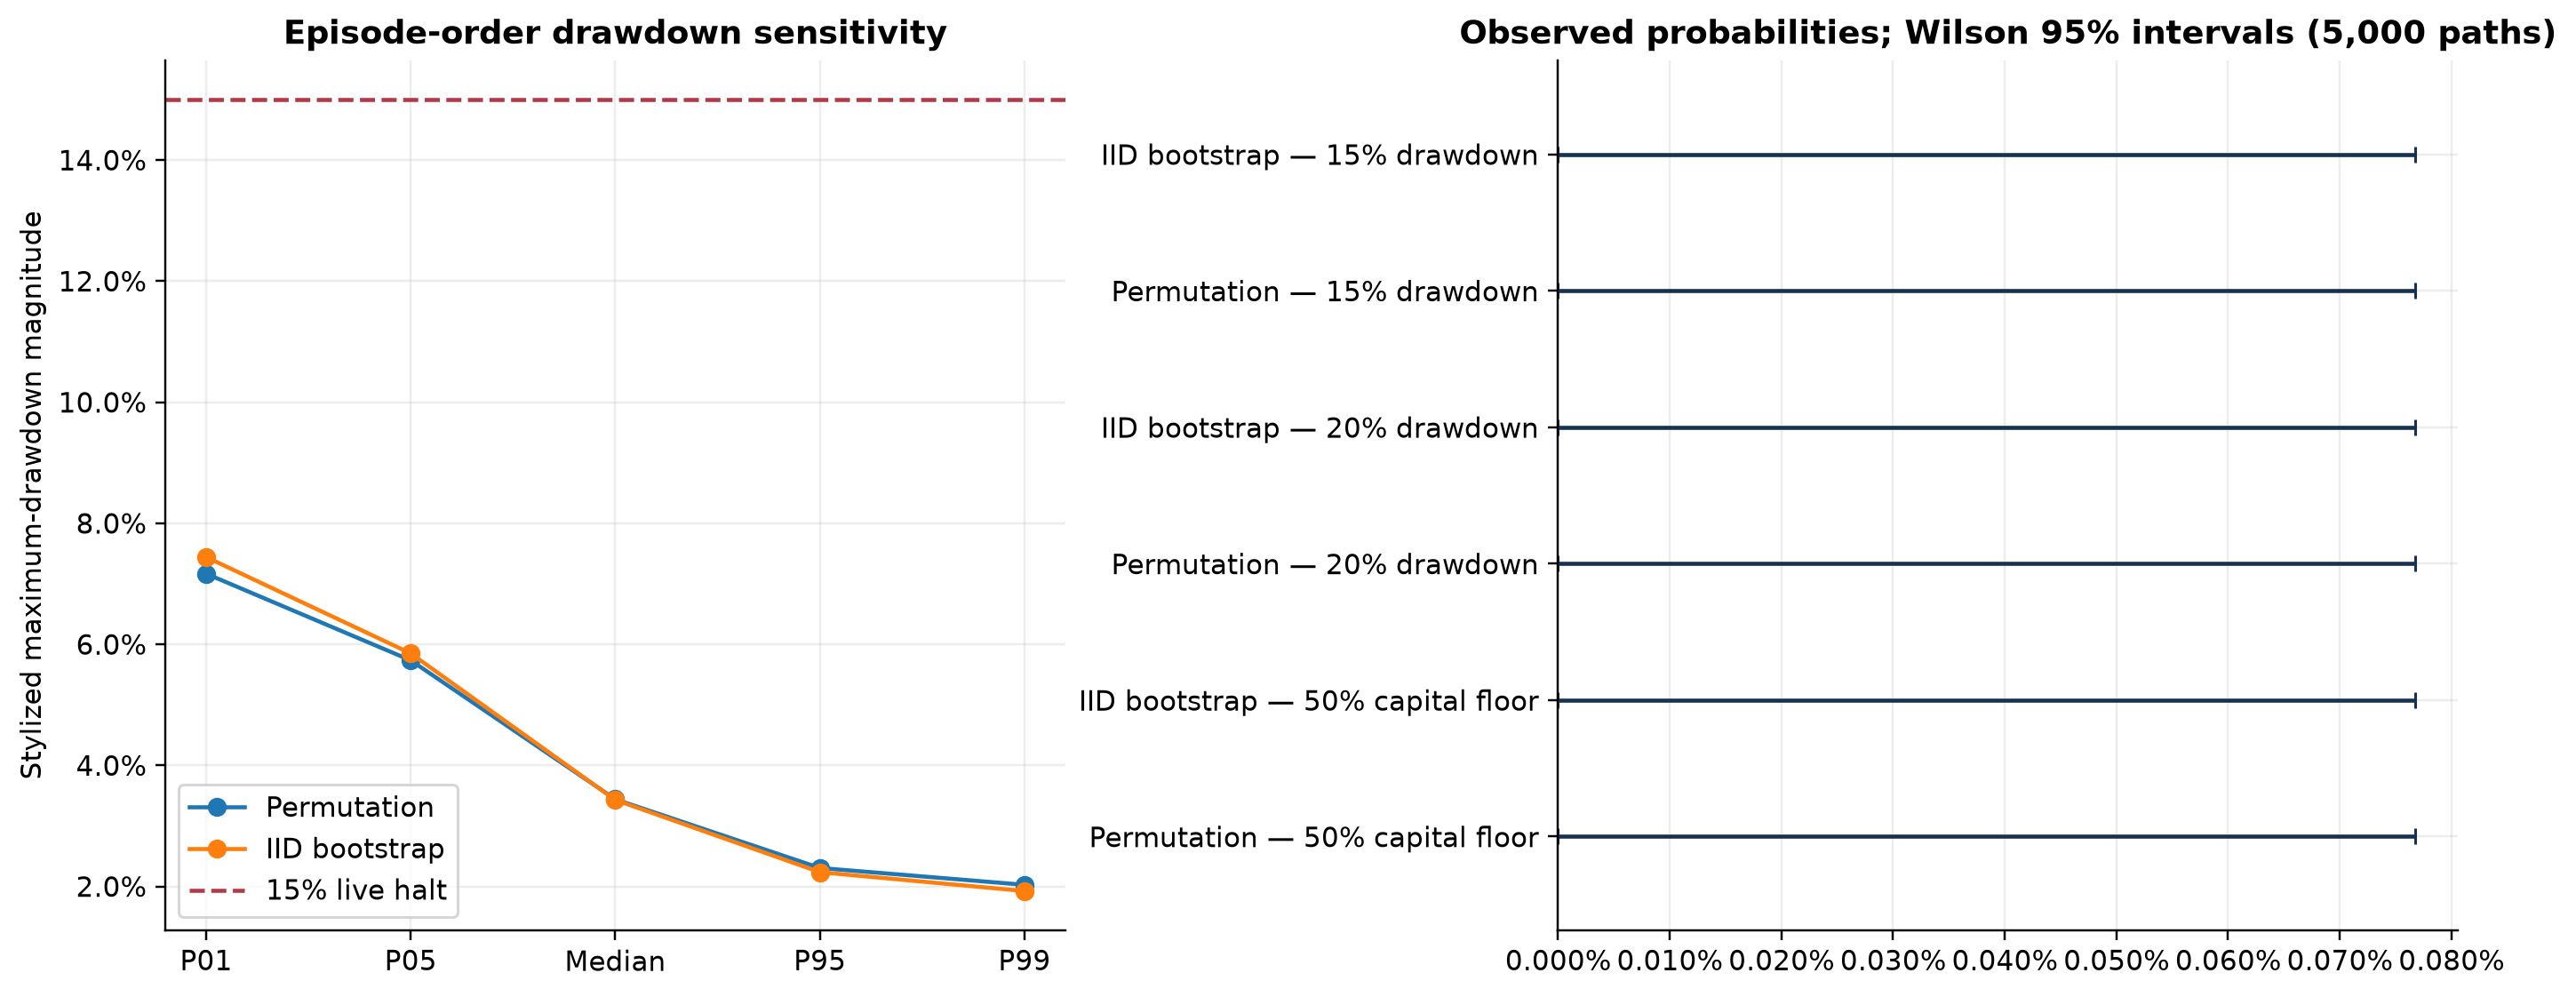

,Method short,Closed episodes,Peak concurrent selected episodes,Maximum episodes sharing an exit date,Samples,Seed,Accounting,Selection adjusted,Dependence preserved,Permitted use
0,Permutation,1673,67,21,5000,20260803,additive net return contribution; initial capi...,False,False,supplementary retrospective risk diagnostic only
1,IID bootstrap,1673,67,21,5000,20260803,additive net return contribution; initial capi...,False,False,supplementary retrospective risk diagnostic only


In [18]:
full_sequence = trade_sequence.loc[
    trade_sequence["Window"].str.contains("full post-launch")
].copy()
method_names = {
    "random permutation without replacement": "Permutation",
    "iid episode bootstrap with replacement": "IID bootstrap",
}
full_sequence["Method short"] = full_sequence["Method"].map(method_names)

dd = full_sequence.loc[
    full_sequence["Metric"].eq("Maximum drawdown")
    & full_sequence["Statistic"].isin(["P01", "P05", "Median", "P95", "P99"])
].copy()
dd["Drawdown magnitude"] = -dd["Value"]
all_probabilities = full_sequence.loc[
    full_sequence["Statistic"].eq("Probability")
].copy()
all_probabilities["Drawdown threshold"] = pd.to_numeric(
    all_probabilities["Metric"].str.extract(
        r"Maximum-drawdown breach probability \(([0-9.]+)% threshold\)"
    )[0],
    errors="coerce",
) / 100
available_thresholds = sorted(
    all_probabilities["Drawdown threshold"].dropna().unique()
)
policy_threshold = min(
    available_thresholds,
    key=lambda value: abs(value - live_limits.max_drawdown_fraction),
)
higher_threshold = next(
    (value for value in available_thresholds if value > policy_threshold),
    None,
)
selected_thresholds = {policy_threshold}
if higher_threshold is not None:
    selected_thresholds.add(higher_threshold)
probabilities_sequence = all_probabilities.loc[
    all_probabilities["Metric"].str.startswith("Capital-floor")
    | all_probabilities["Drawdown threshold"].isin(selected_thresholds)
].copy()
probabilities_sequence["Risk event"] = np.where(
    probabilities_sequence["Drawdown threshold"].isna(),
    probabilities_sequence["Capital floor fraction"].map(
        lambda value: f"{value:.0%} capital floor"
    ),
    probabilities_sequence["Drawdown threshold"].map(
        lambda value: f"{value:.0%} drawdown"
    ),
)
probabilities_sequence["Label"] = (
    probabilities_sequence["Method short"]
    + " — "
    + probabilities_sequence["Risk event"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for method, group in dd.groupby("Method short", sort=False):
    ordered = group.set_index("Statistic").reindex(["P01", "P05", "Median", "P95", "P99"])
    axes[0].plot(ordered.index, ordered["Drawdown magnitude"], marker="o", label=method)
axes[0].axhline(
    live_limits.max_drawdown_fraction,
    color=COLORS["red"],
    linestyle="--",
    label=f"{live_limits.max_drawdown_fraction:.0%} live halt",
)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].set_title("Episode-order drawdown sensitivity")
axes[0].set_ylabel("Stylized maximum-drawdown magnitude")
axes[0].legend()

chart = probabilities_sequence.sort_values(["Risk event", "Method short"]).reset_index(drop=True)
y = np.arange(len(chart))
lower_error = chart["Value"] - chart["Confidence lower"]
upper_error = chart["Confidence upper"] - chart["Value"]
axes[1].barh(y, chart["Value"], color=COLORS["blue"], alpha=0.82)
axes[1].errorbar(
    chart["Value"], y,
    xerr=np.vstack([lower_error, upper_error]),
    fmt="none", ecolor=COLORS["navy"], capsize=3,
)
axes[1].set_yticks(y, chart["Label"])
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
sequence_sample_counts = sorted(chart["Samples"].unique())
sequence_sample_label = ", ".join(
    f"{int(value):,}" for value in sequence_sample_counts
)
axes[1].set_title(
    f"Observed probabilities; Wilson 95% intervals ({sequence_sample_label} paths)"
)
fig.tight_layout()
plt.show()

display(full_sequence[[
    "Method short", "Closed episodes", "Peak concurrent selected episodes",
    "Maximum episodes sharing an exit date", "Samples", "Seed", "Accounting",
    "Selection adjusted", "Dependence preserved", "Permitted use",
]].drop_duplicates().reset_index(drop=True))


## 12. Numerical reconciliation and readiness decision

Ledger checks reconcile positions, P&L, costs, returns, NAV, trade
episodes, and market attribution. These checks answer “did the code
account consistently?” They do not answer “can the market and broker
execute this book?”

The former naked-boolean evidence object has been removed. External
rows now require a file hash, UTC issue/expiry, exact model/config/source
fingerprints, non-revoked approval, and an independent reviewer. Broker
certification and compliance approval additionally bind their evidence
subjects to the selected deployment identity and policy digest.


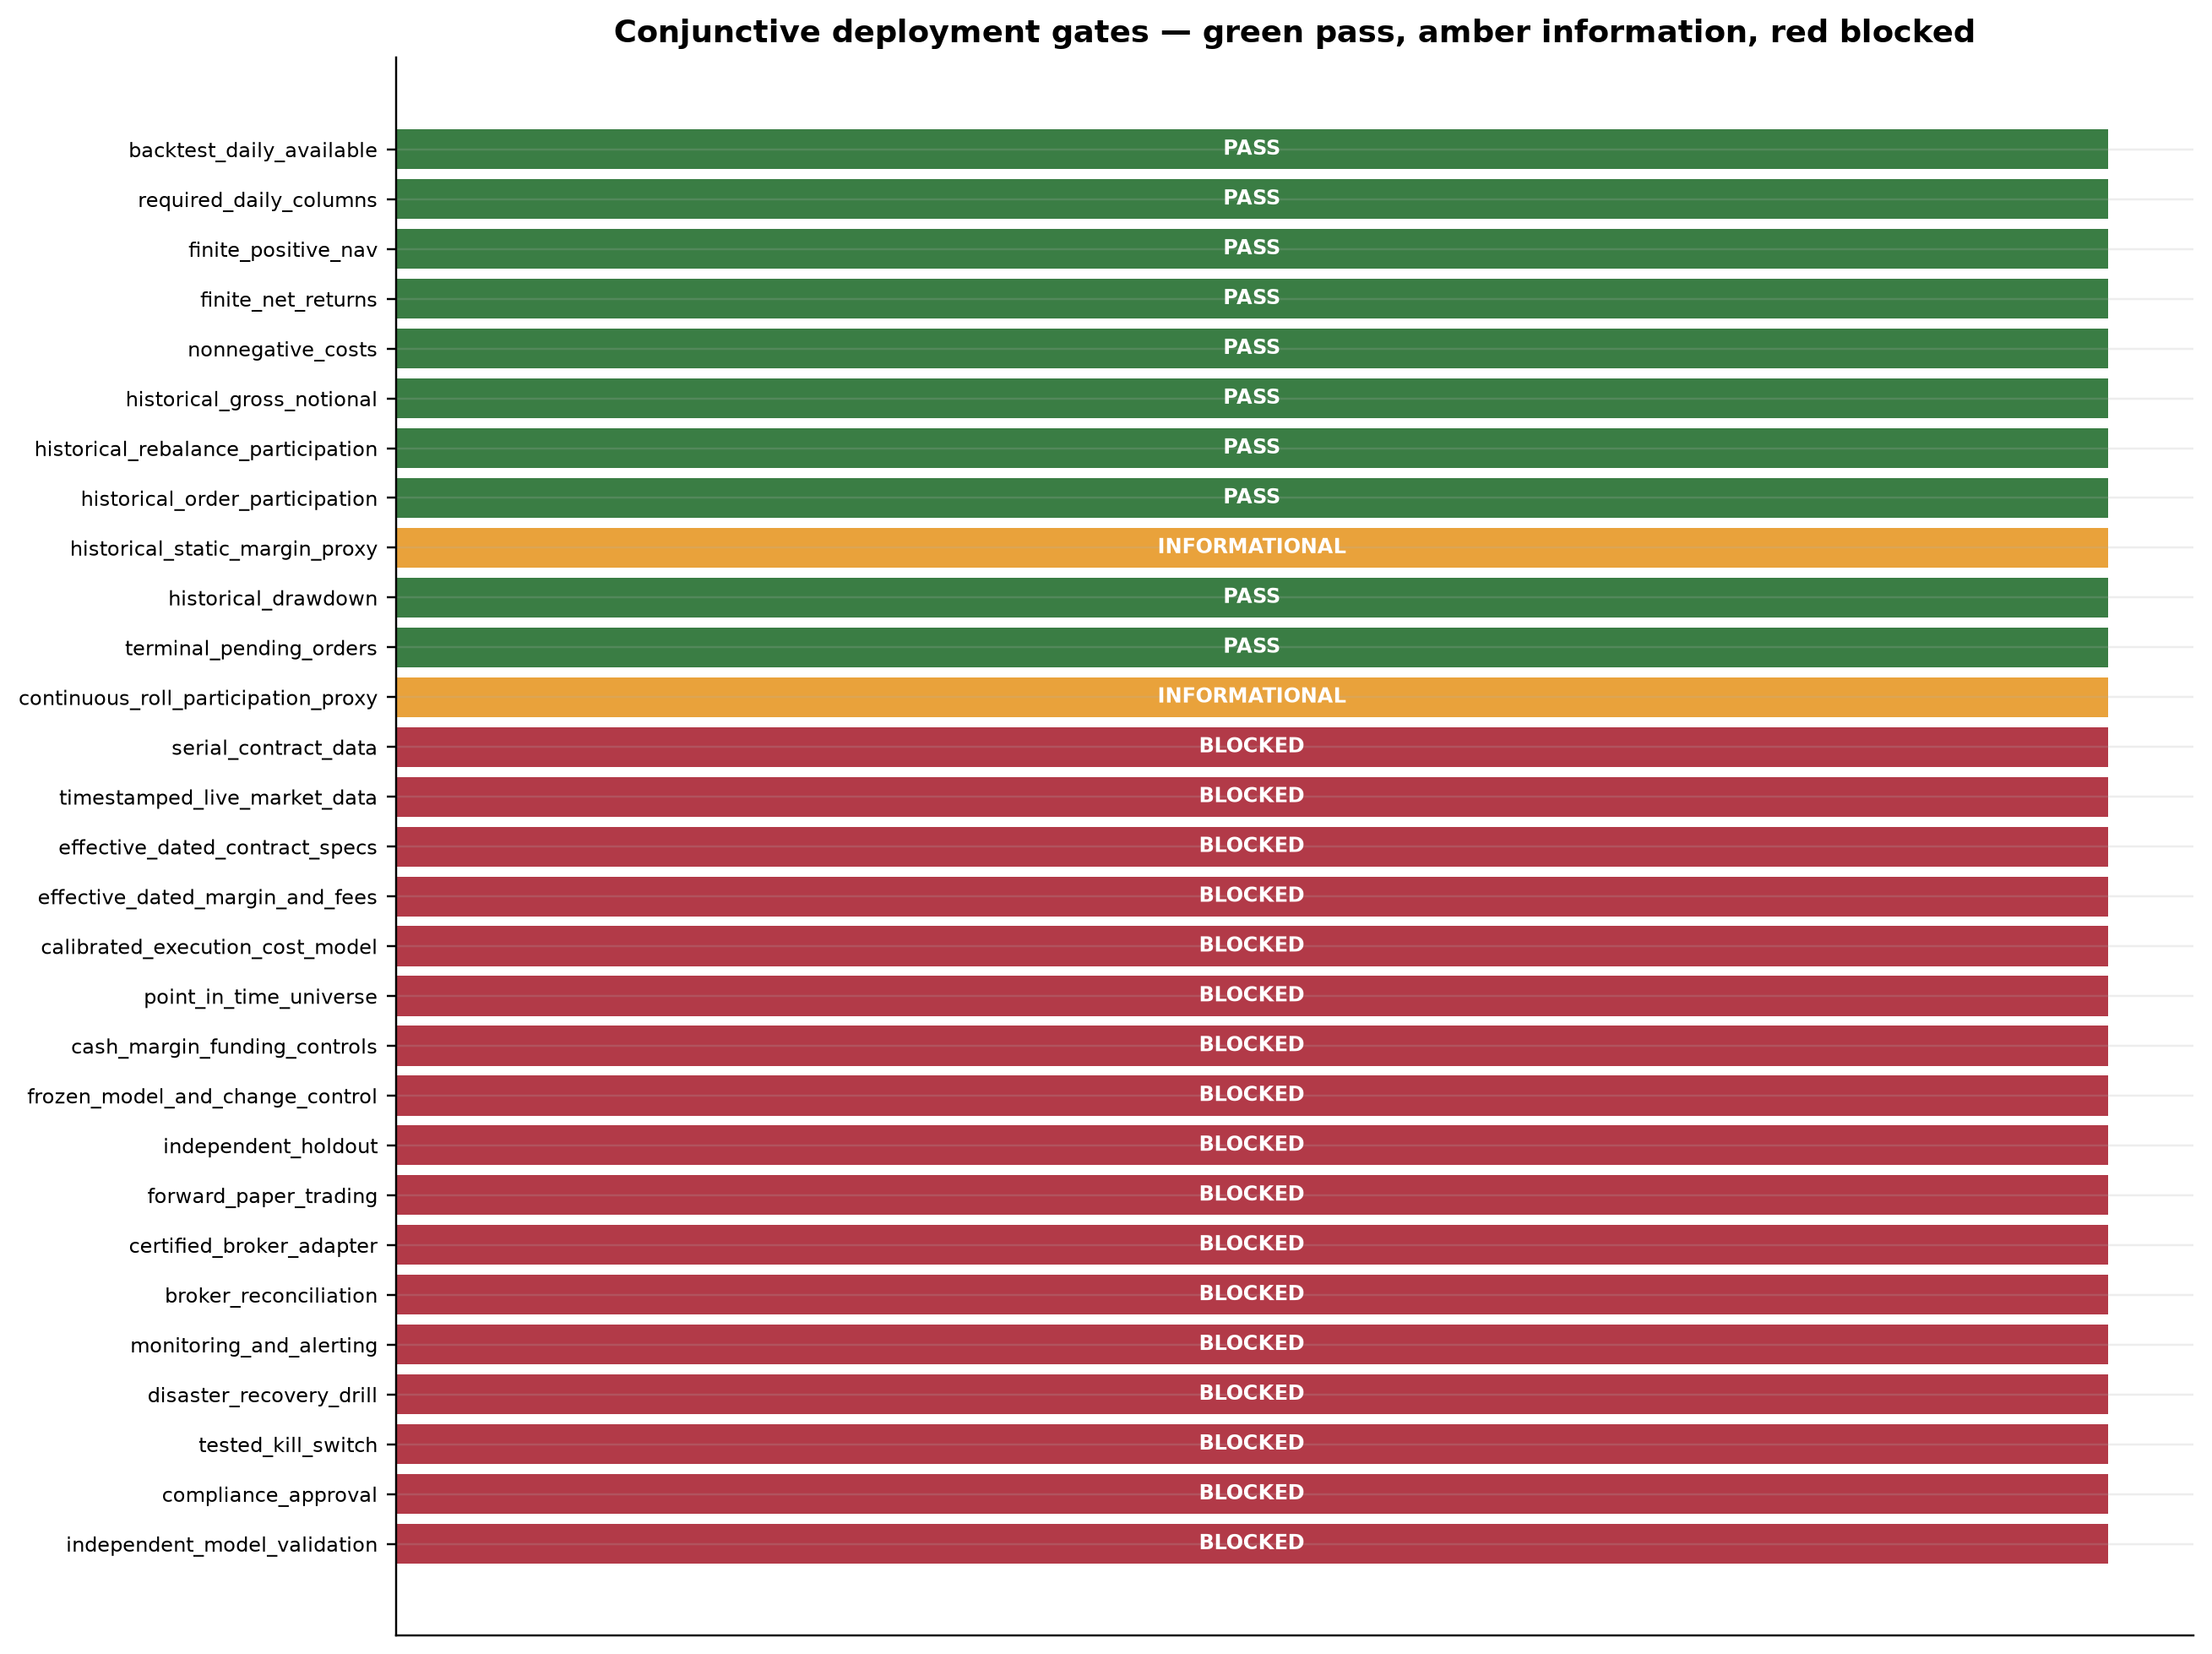

,check,status,maximum_absolute_error,tolerance,detail
0,market_gross_pnl_to_portfolio,PASS,1.164153e-10,0.000001,Sum of market gross P&L equals the portfolio g...
1,market_costs_to_portfolio,PASS,5.456968e-12,0.000001,Regular plus roll costs reconcile to the portf...
2,fixed_plus_impact_costs,PASS,1.818989e-12,0.000001,Parameterized fixed and impact costs reconcile...
3,position_change_to_trades,PASS,0.000000e+00,0.000001,Recorded trades equal the change in contract p...
4,net_pnl_identity,PASS,0.000000e+00,0.000001,Net P&L equals gross P&L less all modeled costs.
5,nav_recursion,PASS,3.725290e-09,0.000001,Closing NAV equals prior NAV plus net P&L.
6,net_return_identity,PASS,0.000000e+00,0.000001,Net return is calculated on prior closing NAV.
7,episode_gross_pnl_to_market_ledger,PASS,7.450581e-09,0.000001,Closed and censored directional episodes inclu...
8,episode_costs_to_market_ledger,PASS,0.000000e+00,0.000001,Closed and censored directional episodes inclu...
9,episode_contribution_to_daily_return,PASS,0.000000e+00,0.000001,Episode net contributions reconcile to additiv...


,gate,category,critical,status,observed,limit,reason
0,backtest_daily_available,backtest,True,PASS,9683,> 0 rows,gate passed
1,required_daily_columns,backtest,True,PASS,all present,all required columns,gate passed
2,finite_positive_nav,ledger,True,PASS,961972.2418222325,> 0,gate passed
3,finite_net_returns,ledger,True,PASS,finite,all finite,gate passed
4,nonnegative_costs,ledger,True,PASS,0.0,>= 0,gate passed
5,historical_gross_notional,risk,True,PASS,5.1117169008057015,6.0,gate passed
6,historical_rebalance_participation,risk,True,PASS,0.019863438857852266,0.02,gate passed
7,historical_order_participation,risk,True,PASS,0.01999375195251484,0.02,gate passed
8,historical_static_margin_proxy,research limitation,False,INFORMATIONAL,0.5259920430451536,not a point-in-time historical gate,computed from a current static catalogue snaps...
9,historical_drawdown,risk,True,PASS,0.11847122445591829,0.15,gate passed


In [19]:
status_order = {"PASS": 1, "INFORMATIONAL": 0, "BLOCKED": -1}
readiness_plot = readiness.copy()
readiness_plot["value"] = readiness_plot["status"].map(status_order)
colors = readiness_plot["status"].map({"PASS": COLORS["green"], "BLOCKED": COLORS["red"], "INFORMATIONAL": COLORS["amber"]})
fig, ax = plt.subplots(figsize=(12, 9))
y = np.arange(len(readiness_plot))
ax.barh(y, np.ones(len(y)), color=colors)
ax.set_yticks(y, readiness_plot["gate"], fontsize=8)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title("Conjunctive deployment gates — green pass, amber information, red blocked")
for location, status in enumerate(readiness_plot["status"]):
    ax.text(0.5, location, status, ha="center", va="center", color="white", weight="bold", fontsize=8)
fig.tight_layout()
plt.show()

display(ledger_checks)
display(readiness[["gate", "category", "critical", "status", "observed", "limit", "reason"]])


## 13. What was fixed locally, and what still requires external action

| Original blocker | Repository change | Current state |
|---|---|---|
| Historical participation can breach the live gate | Research sizing now uses lagged volume and reports actual-session participation; live serial plans apply the current route-time cap, retain residuals and control both roll legs | Historical gate can remain blocked; current serial liquidity and paper evidence are still absent |
| Prior drawdown breached the live gate | Frozen lower risk budget; corrected exact-ledger MDD and the current live gate are read dynamically | Historical gate passes; not independently validated |
| Undated static margin altered history | Current margin snapshot no longer resizes 1990–2014; it is an informational proxy only | Effective-dated historical/live margin still required |
| Unsupported yield-quoted valuation | YXT/YYT removed until rate-dependent P&L/notional functions are supplied | Supported-universe count is generated; dated specs required for restoration |
| No serial expiry simulation | Strict serial schema, USD notional/margin, FND/LTD deadline, safer destination and two-leg audit | Needs licensed data and paper evidence |
| No current dated data/specs | UTC freshness, effective intervals and ordered health/reconciliation timestamps | Needs production feed and schedules |
| Assumed costs | Raw-fill-hash-bound, unique-order/session/cycle calibration and freshness gates | Needs representative quotes and fills |
| No untouched holdout/paper record | Fingerprint-bound evidence registry and paper execution path | Cannot manufacture future time or unseen data |
| Unsafe arbitrary live orders | Live route recomputes serial, participation and batch gross/margin; verifies fresh positions, certified broker identity, signed broker/policy-bound intent and exact-batch compliance decision; rechecks identity before outbox/submission | Needs separately controlled signer, approved policy provider/artifact and certified broker evidence |
| No OMS/recon/monitoring/DR/kill | Locked durable outbox, strict ACK correlation/replay, reconciliation, heartbeat, DR report, latched dual-control kill | Needs selected broker and deployed drills |
| `mode="production"` refused | Removed misleading backtest mode; `delta1_strategy.execution.operations.ExecutionService(mode="live")` is the gated boundary | Live routing remains fail-closed until READY |

### Committee recommendation

**NO-GO for live capital.** Approve only a frozen v3.2.1 remediation and
prospective paper/shadow program. Return for launch approval after all
required external evidence gates pass, the selected broker deployment
is independently certified, and no model parameter changed during the
evidence window.


## Appendix A — operational sequence

1. Verify the evidence registry against the frozen run fingerprints.
2. Verify the production broker/adapter/account/environment identity
   against certified evidence.
3. Validate clocks, serial snapshots, session calendars, specs, margins,
   fees, FX, and delivery dates.
4. Reconcile broker positions, cash, fills, fees, and open orders.
5. Evaluate freshness, gross, margin, drawdown, broker, monitoring, and
   kill-switch state.
6. Obtain an approved, fresh compliance decision for the exact batch
   and verify signed broker/policy-bound intents.
7. Build expiry-specific orders and two-leg partial roll plans.
8. Recheck broker identity before the outbox and submission; persist
   each order before idempotent broker submission.
9. Journal acknowledgements, fills, rejects, cancels, and incidents.
10. Reconcile after execution and at session end; any break blocks risk.
11. Back up and cold-replay the journal; sign the daily control report.

Full kill, recovery, and drill procedures are in
`docs/runbooks/deployment.md`.


## Appendix B — full artifact map

- `outputs/strategy_metrics.csv`, `outputs/strategy_daily.csv`:
  performance and NAV.
- `outputs/strategy_market_daily.csv.gz`,
  `outputs/strategy_execution_events.csv`:
  reconciling market and execution ledgers.
- `outputs/strategy_trade_episodes.csv`,
  `outputs/strategy_trade_metrics.csv`: episode accounting and grouped
  trade economics.
- `outputs/strategy_friction_stress.csv`: reused-history friction
  sensitivity.
- `outputs/strategy_regime_metrics.csv`: outcomes under lagged regime
  labels.
- `outputs/strategy_monte_carlo_summary.csv`: selection-unadjusted
  block-bootstrap CAGR/Sharpe summaries; month-end drawdown is
  informational.
- `outputs/strategy_daily_drawdown_monte_carlo.csv`: primary
  daily-close drawdown bootstrap with initial capital included.
- `outputs/strategy_trade_sequence_monte_carlo.csv`: supplementary
  permutation and IID episode-order diagnostics with finite-sample
  intervals.
- `outputs/strategy_drawdown_overlay_*`: non-executable risk diagnostic.
- `outputs/strategy_ledger_checks.csv`,
  `outputs/production_readiness.csv`: numerical integrity and launch
  gates.
- `outputs/source_manifest.csv`, `outputs/strategy_config.json`,
  `outputs/run_manifest.json`: reproducibility fingerprints and research
  status.

Reproduce with `delta1-strategy`, rebuild this notebook with `python
scripts/build_committee_notebook.py`, run `python -m unittest discover
-s tests -v`, then execute it from a clean kernel. The notebook must
contain embedded PNG outputs and zero error cells before committee
distribution.
